In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── 경로 설정 (본인 환경에 맞게 수정)
DATA_DIR = Path("./data")   # 데이터 파일 위치

# 결과 저장 폴더 생성
Path("./output").mkdir(exist_ok=True)

print("라이브러리 로드 완료")

라이브러리 로드 완료


In [3]:
# 원천 데이터 로드
labels  = pd.read_csv(DATA_DIR / "labels.csv")
weekly  = pd.read_excel(DATA_DIR / "주간시총300.xlsx")

print("=== labels.csv ===")
print(f"  shape : {labels.shape}")
print(f"  컬럼  : {labels.columns.tolist()}")
print(f"  window: {sorted(labels['window'].unique())}")
print()
print("=== 주간시총300.xlsx ===")
print(f"  shape    : {weekly.shape}")
print(f"  컬럼     : {weekly.columns.tolist()}")
print(f"  날짜범위 : {weekly['date'].min().date()} ~ {weekly['date'].max().date()}")
print(f"  유니크 ticker: {weekly['ticker'].nunique()}")

=== labels.csv ===
  shape : (2491, 6)
  컬럼  : ['window', 'ticker', 'is_member', 'label_in', 'label_out', 'actual_rank']
  window: ['2020_H1', '2020_H2', '2021_H1', '2021_H2', '2022_H1', '2022_H2', '2023_H1', '2023_H2', '2024_H1', '2024_H2', '2025_H1', '2025_H2']

=== 주간시총300.xlsx ===
  shape    : (108000, 13)
  컬럼     : ['date', 'ticker', 'company', 'close', 'shares', '시가총액', '시가총액_rank', '유동주식수', '유통주식비율', '거래대금', '업종', '시총순위변화율', '과거지수순위']
  날짜범위 : 2019-05-03 ~ 2026-03-17
  유니크 ticker: 497


# 컬럼 rename

In [4]:
# 주간시총300.xlsx → WEEKLY_SAMPLE 딕셔너리 기준으로 rename
weekly = weekly.rename(columns={
    '시가총액'     : 'mktcap',
    '시가총액_rank': 'mktcap_rank',
    '거래대금'     : 'trading_value',
    '유동주식수'   : 'float_shares_raw',   # SHARES_LOCK 완성 전 임시
    '유통주식비율' : 'float_ratio_raw',    # SHARES_LOCK 완성 전 임시
    '업종'         : 'sector_name_raw',    # SECTOR_MAP 완성 전 임시
    '시총순위변화율': 'rank_chg_pct_raw',
    '과거지수순위' : 'past_index_rank_raw',
})

print("rename 후 컬럼:", weekly.columns.tolist())
print(weekly[['ticker','date','close','mktcap','mktcap_rank','trading_value']].head(3))

rename 후 컬럼: ['date', 'ticker', 'company', 'close', 'shares', 'mktcap', 'mktcap_rank', 'float_shares_raw', 'float_ratio_raw', 'trading_value', 'sector_name_raw', 'rank_chg_pct_raw', 'past_index_rank_raw']
  ticker       date   close           mktcap  mktcap_rank  trading_value
0   5930 2019-05-03   45300  268159597866600            1            NaN
1    660 2019-05-03   80400   57301270146000            2            NaN
2  68270 2019-05-03  166830   38545781382630            3            NaN


# 기준일 매핑 

In [5]:
# KRX 코스피200 정기변경 기준일 (해당 주 금요일 기준)
# 실제 발표일과 ±1주 오차 허용 → 가장 가까운 데이터 날짜로 snap
WINDOW_EVAL_DATE = {
    '2020_H1': '2020-06-05',
    '2020_H2': '2020-12-04',
    '2021_H1': '2021-06-04',
    '2021_H2': '2021-12-03',
    '2022_H1': '2022-06-10',
    '2022_H2': '2022-12-09',
    '2023_H1': '2023-06-09',
    '2023_H2': '2023-12-08',
    '2024_H1': '2024-06-07',
    '2024_H2': '2024-12-06',
    '2025_H1': '2025-06-06',
    # 2025_H2는 미래 → 예측 대상, 학습 제외
}
WINDOWS_ORDERED = sorted(WINDOW_EVAL_DATE.keys())

# weekly에서 실제로 존재하는 가장 가까운 날짜 찾는 함수
available_dates = sorted(weekly['date'].unique())

def get_closest_date(target_str):
    target = pd.Timestamp(target_str)
    return min(available_dates, key=lambda d: abs(d - target))

# 확인
for w, d in WINDOW_EVAL_DATE.items():
    closest = get_closest_date(d)
    print(f"{w}  목표: {d}  →  실제: {closest.date()}")

2020_H1  목표: 2020-06-05  →  실제: 2020-06-05
2020_H2  목표: 2020-12-04  →  실제: 2020-12-04
2021_H1  목표: 2021-06-04  →  실제: 2021-06-04
2021_H2  목표: 2021-12-03  →  실제: 2021-12-03
2022_H1  목표: 2022-06-10  →  실제: 2022-06-10
2022_H2  목표: 2022-12-09  →  실제: 2022-12-09
2023_H1  목표: 2023-06-09  →  실제: 2023-06-09
2023_H2  목표: 2023-12-08  →  실제: 2023-12-08
2024_H1  목표: 2024-06-07  →  실제: 2024-06-07
2024_H2  목표: 2024-12-06  →  실제: 2024-12-06
2025_H1  목표: 2025-06-06  →  실제: 2025-06-05


# window(period)별 rank 스냅샷 생성

In [6]:
snap_rows = []

for window, eval_date_str in WINDOW_EVAL_DATE.items():
    closest = get_closest_date(eval_date_str)
    snap = (
        weekly[weekly['date'] == closest]
        [['ticker', 'mktcap_rank', 'mktcap', 'trading_value']]
        .copy()
    )
    snap['window']    = window
    snap['snap_date'] = closest
    snap_rows.append(snap)

rank_snap = pd.concat(snap_rows, ignore_index=True)

print("rank_snap shape:", rank_snap.shape)
print("null 확인:")
print(rank_snap.isnull().sum())
print(rank_snap.head(5))

rank_snap shape: (3300, 6)
null 확인:
ticker              0
mktcap_rank         0
mktcap              0
trading_value    3300
window              0
snap_date           0
dtype: int64
   ticker  mktcap_rank           mktcap  trading_value   window  snap_date
0    5930            1  328539904671000            NaN  2020_H1 2020-06-05
1     660            2   64428293796000            NaN  2020_H1 2020-06-05
2   68270            3   50617821971619            NaN  2020_H1 2020-06-05
3  207940            4   44775153809505            NaN  2020_H1 2020-06-05
4    5935            5   38962790206000            NaN  2020_H1 2020-06-05


In [7]:
indiv = pd.read_excel("data/개별종목_202505_202511_.xlsx")

print("=== 개별종목_202505_202511_.xlsx ===")
print("shape:", indiv.shape)
print("columns:", indiv.columns.tolist())
print()
print(indiv.head(3).to_string())
print()
print("dtypes:\n", indiv.dtypes)
print()

# 날짜 범위
print("기준일자 unique 수:", indiv['기준일자'].nunique())
print("기준일자 range:", indiv['기준일자'].min(), "~", indiv['기준일자'].max())
print()

# ticker 형식 확인
print("종목코드 sample:", indiv['종목코드'].head(10).tolist())
print("종목코드 dtype:", indiv['종목코드'].dtype)

=== 개별종목_202505_202511_.xlsx ===
shape: (23067, 15)
columns: ['기준일자', '종목코드', '종목명', '보(0)/우(1)', '업종명', '종가', '거래대금', '시가총액', '상장주식수', 'is_member', 'label_in', 'label_out', 'actual_rank', 'Unnamed: 13', '2019-2025년 주간/코스피 내 종목 정보']

       기준일자   종목코드     종목명  보(0)/우(1)    업종명     종가        거래대금          시가총액     상장주식수  is_member  label_in  label_out  actual_rank Unnamed: 13  2019-2025년 주간/코스피 내 종목 정보
0  20250502  95570  AJ네트웍스          0  일반서비스   3760  1032650980  170150000000  45252759        NaN       NaN        NaN          NaN         NaN  kospi200에 선정된 종목에 대해서 라벨링
1  20250502   6840   AK홀딩스          0   기타금융  10620   112280110  140689000000  13247561        1.0       0.0        1.0          NaN         NaN                        NaN
2  20250502  27410     BGF          0   기타금융   3585   101444107  343145000000  95716791        1.0       0.0        1.0          NaN         NaN                        NaN

dtypes:
 기준일자                           int64
종목코드                          o

In [8]:
# zero-pad 통일
indiv['종목코드'] = indiv['종목코드'].astype(str).str.zfill(6)
indiv['기준일자'] = pd.to_datetime(indiv['기준일자'].astype(str), format='%Y%m%d')

print("=== 키 형식 비교 ===")
print("weekly  ticker 예시:", weekly['ticker'].head(5).tolist())
print("indiv   종목코드 예시:", indiv['종목코드'].head(5).tolist())
print()
print("weekly  date 예시:", weekly['date'].head(3).tolist())
print("indiv   기준일자 예시:", indiv['기준일자'].head(3).tolist())
print()

# 날짜 오버랩 확인
weekly_dates = set(weekly['date'].dt.date)
indiv_dates  = set(indiv['기준일자'].dt.date)
overlap = weekly_dates & indiv_dates
print(f"weekly 날짜 수: {len(weekly_dates)}")
print(f"indiv  날짜 수: {len(indiv_dates)}")
print(f"겹치는 날짜 수: {len(overlap)}")
print(f"겹치는 날짜들: {sorted(overlap)}")
print()

# ticker 오버랩 확인
weekly_tickers = set(weekly['ticker'].unique())
indiv_tickers  = set(indiv['종목코드'].unique())
print(f"weekly ticker 수: {len(weekly_tickers)}")
print(f"indiv  ticker 수: {len(indiv_tickers)}")
print(f"겹치는 ticker 수: {len(weekly_tickers & indiv_tickers)}")

=== 키 형식 비교 ===
weekly  ticker 예시: [5930, 660, 68270, 5935, 96770]
indiv   종목코드 예시: ['095570', '006840', '027410', '282330', '138930']

weekly  date 예시: [Timestamp('2019-05-03 00:00:00'), Timestamp('2019-05-03 00:00:00'), Timestamp('2019-05-03 00:00:00')]
indiv   기준일자 예시: [Timestamp('2025-05-02 00:00:00'), Timestamp('2025-05-02 00:00:00'), Timestamp('2025-05-02 00:00:00')]

weekly 날짜 수: 360
indiv  날짜 수: 24
겹치는 날짜 수: 24
겹치는 날짜들: [datetime.date(2025, 5, 2), datetime.date(2025, 5, 9), datetime.date(2025, 5, 16), datetime.date(2025, 5, 23), datetime.date(2025, 5, 30), datetime.date(2025, 6, 13), datetime.date(2025, 6, 20), datetime.date(2025, 6, 27), datetime.date(2025, 7, 4), datetime.date(2025, 7, 11), datetime.date(2025, 7, 18), datetime.date(2025, 7, 25), datetime.date(2025, 8, 1), datetime.date(2025, 8, 8), datetime.date(2025, 8, 22), datetime.date(2025, 8, 29), datetime.date(2025, 9, 5), datetime.date(2025, 9, 12), datetime.date(2025, 9, 19), datetime.date(2025, 9, 26), datetime.date

In [9]:
# indiv zero-pad 제거 → 숫자형 문자열로 통일
# '006840' → '6840', '00104K' 같은 우선주는 별도 처리
indiv_raw = pd.read_excel("data/개별종목_202505_202511_.xlsx")

# 우선주(알파벳 포함) 제외 여부 먼저 확인
alpha_mask = indiv_raw['종목코드'].astype(str).str.contains('[A-Za-z]', regex=True)
print(f"알파벳 포함 종목코드 수 (우선주 등): {alpha_mask.sum()}")
print(indiv_raw[alpha_mask]['종목코드'].unique()[:10])
print()

# 숫자만 있는 종목코드 → int 변환 후 str (앞 0 제거)
indiv = indiv_raw[~alpha_mask].copy()
indiv['종목코드'] = indiv['종목코드'].astype(str).str.lstrip('0')  # '006840' → '6840'
indiv['기준일자'] = pd.to_datetime(indiv['기준일자'].astype(str), format='%Y%m%d')

# weekly ticker도 str로 통일
weekly['ticker'] = weekly['ticker'].astype(str)
indiv['종목코드'] = indiv['종목코드'].astype(str)

# 재확인
weekly_sample = set(weekly[weekly['date'] >= '2025-05-01']['ticker'].unique())
indiv_sample  = set(indiv['종목코드'].unique())

print(f"2025-05 이후 weekly ticker 수: {len(weekly_sample)}")
print(f"indiv ticker 수: {len(indiv_sample)}")
print(f"겹치는 수: {len(weekly_sample & indiv_sample)}")
print()
print("weekly에만 있는 예시 5개:", list(weekly_sample - indiv_sample)[:5])
print("indiv에만 있는 예시 5개:",  list(indiv_sample - weekly_sample)[:5])

알파벳 포함 종목코드 수 (우선주 등): 567
['00104K' '37550L' '37550K' '38380K' '03473K' '28513K' '00806K' '35320K'
 '33626K' '33626L']

2025-05 이후 weekly ticker 수: 349
indiv ticker 수: 942
겹치는 수: 343

weekly에만 있는 예시 5개: ['0120G0', '00104K', '0126Z0', '279570', '00680K']
indiv에만 있는 예시 5개: ['404990', '2210', '3780', '8775', '10660']


# weekly 알파벳 코드 확인 후 JOIN

In [10]:
# weekly에서 알파벳 포함 ticker 확인
weekly_alpha = weekly['ticker'].astype(str).str.contains('[A-Za-z]', regex=True)
print(f"weekly 알파벳 포함 ticker 수: {weekly_alpha.sum()}")
print("예시:", weekly[weekly_alpha]['ticker'].unique()[:10].tolist())
print()

# 두 데이터 모두 알파벳 포함 제외 → 순수 숫자 ticker만 사용
weekly_clean = weekly[~weekly_alpha].copy()
weekly_clean['ticker'] = weekly_clean['ticker'].astype(str)

# indiv에서 trading_value만 추출해서 weekly에 보완
indiv_tv = indiv[['기준일자', '종목코드', '거래대금']].copy()
indiv_tv.columns = ['date', 'ticker', 'trading_value_indiv']

# LEFT JOIN: weekly_clean 기준으로 indiv trading_value 붙이기
weekly_clean = weekly_clean.merge(
    indiv_tv,
    on=['date', 'ticker'],
    how='left'
)

# trading_value 보완: weekly 원본이 null이면 indiv 값으로 채움
weekly_clean['trading_value'] = weekly_clean['trading_value'].fillna(
    weekly_clean['trading_value_indiv']
)
weekly_clean = weekly_clean.drop(columns=['trading_value_indiv'])

# 결과 확인
print("=== trading_value 보완 결과 ===")
tv_null = weekly_clean[weekly_clean['date'] >= '2025-05-01']['trading_value'].isna().sum()
tv_total = weekly_clean[weekly_clean['date'] >= '2025-05-01'].shape[0]
print(f"2025-05 이후 trading_value null: {tv_null} / {tv_total}")
print()
tv_null_all = weekly_clean['trading_value'].isna().sum()
tv_total_all = weekly_clean.shape[0]
print(f"전체 trading_value null: {tv_null_all} / {tv_total_all}")
print(f"  → 2025년 이전 구간은 원래 없으므로 정상")
print()
print(weekly_clean[weekly_clean['date'] >= '2025-05-01'][
    ['date','ticker','mktcap_rank','trading_value']
].head(5))

weekly 알파벳 포함 ticker 수: 353
예시: ['00680K', '00279K', '00088K', '00104K', '0126Z0', '0120G0']

=== trading_value 보완 결과 ===
2025-05 이후 trading_value null: 6811 / 13959

전체 trading_value null: 100499 / 107647
  → 2025년 이전 구간은 원래 없으므로 정상

            date  ticker  mktcap_rank  trading_value
93688 2025-05-02    5930            1   1.227730e+12
93689 2025-05-02     660            2   7.130780e+11
93690 2025-05-02  373220            3   6.530201e+10
93691 2025-05-02  207940            4   7.949472e+10
93692 2025-05-02  329180            5   6.785101e+10


In [11]:
# 2025-05 이후 구간만 분리
recent = weekly_clean[weekly_clean['date'] >= '2025-05-01'].copy()

# null인 행만 추출
null_tv = recent[recent['trading_value'].isna()]

print(f"null 행 수: {len(null_tv)}")
print(f"null ticker 수 (unique): {null_tv['ticker'].nunique()}")
print(f"null 날짜 수 (unique): {null_tv['date'].nunique()}")
print()

# 날짜별 null 수
print("=== 날짜별 null 수 ===")
print(null_tv.groupby('date').size().to_string())
print()

# null ticker 중 indiv에 있는지 확인
null_tickers = set(null_tv['ticker'].unique())
indiv_tickers = set(indiv['종목코드'].unique())
print(f"null ticker 중 indiv에 있는 수: {len(null_tickers & indiv_tickers)}")
print(f"null ticker 중 indiv에 없는 수: {len(null_tickers - indiv_tickers)}")
print()
print("indiv에 없는 null ticker 예시 10개:")
print(list(null_tickers - indiv_tickers)[:10])

null 행 수: 6811
null ticker 수 (unique): 332
null 날짜 수 (unique): 23

=== 날짜별 null 수 ===
date
2025-06-05    298
2025-08-14    298
2025-10-02    297
2025-11-07    297
2025-11-14    297
2025-11-21    297
2025-11-28    296
2025-12-05    296
2025-12-12    296
2025-12-19    296
2025-12-26    296
2026-01-02    296
2026-01-09    296
2026-01-16    296
2026-01-23    295
2026-01-30    295
2026-02-06    295
2026-02-13    295
2026-02-20    296
2026-02-27    295
2026-03-06    296
2026-03-13    296
2026-03-17    296

null ticker 중 indiv에 있는 수: 331
null ticker 중 indiv에 없는 수: 1

indiv에 없는 null ticker 예시 10개:
['279570']


## 진단결과
indiv 보유 날짜: 2025-05-02 ~ 2025-10-31  (24개)
null 발생 날짜: 2025-06-05, 2025-08-14 → indiv에 없는 날짜
              2025-11-07 이후 → indiv 범위 밖

## 결론
- trading_value 베이스라인에서 제외
trading_value는 2025-05 이전 구간 전체 + 2025-11 이후 전체가 null이에요. 학습 데이터 대부분(2020_H1 ~ 2024_H2)에 값이 없으니 베이스라인 피처로 쓸 수가 없어요.
지금 당장 할 것: trading_value는 베이스라인에서 제외하고 진행해요. 나중에 FEATURE_KRX 전체 피처 만들 때 avg_trading_value(6개월 평균)로 제대로 만들면 돼요.

In [12]:
# weekly_clean에서 trading_value는 보관만 하고 피처로는 안 씀
# (나중에 avg_trading_value 만들 때 사용)
print("=== 최종 weekly_clean 상태 ===")
print("shape:", weekly_clean.shape)
print("columns:", weekly_clean.columns.tolist())
print()

# rank_snap도 weekly_clean 기준으로 재생성
# (알파벳 ticker 제거된 버전으로 다시 만들어야 함)
snap_rows = []
for window, eval_date_str in WINDOW_EVAL_DATE.items():
    closest = get_closest_date(eval_date_str)
    snap = (
        weekly_clean[weekly_clean['date'] == closest]
        [['ticker', 'mktcap_rank', 'mktcap']]
        .copy()
    )
    snap['window']    = window
    snap['snap_date'] = closest
    snap_rows.append(snap)

rank_snap = pd.concat(snap_rows, ignore_index=True)

print("rank_snap 재생성 완료")
print("shape:", rank_snap.shape)
print("null 확인:\n", rank_snap.isnull().sum())
print()
print(rank_snap.head(3))

=== 최종 weekly_clean 상태 ===
shape: (107647, 13)
columns: ['date', 'ticker', 'company', 'close', 'shares', 'mktcap', 'mktcap_rank', 'float_shares_raw', 'float_ratio_raw', 'trading_value', 'sector_name_raw', 'rank_chg_pct_raw', 'past_index_rank_raw']

rank_snap 재생성 완료
shape: (3292, 5)
null 확인:
 ticker         0
mktcap_rank    0
mktcap         0
window         0
snap_date      0
dtype: int64

  ticker  mktcap_rank           mktcap   window  snap_date
0   5930            1  328539904671000  2020_H1 2020-06-05
1    660            2   64428293796000  2020_H1 2020-06-05
2  68270            3   50617821971619  2020_H1 2020-06-05


📌 왜 2019~2024 데이터도 필요한가
2025년 12월 예측이 목표지만, ML 모델은 과거 패턴으로 학습해야 해요.
학습 데이터 (과거 패턴 학습)        예측 대상
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2020_H1 ~ 2025_H1                  2025_H2
  ↑                                   ↑
"이런 피처면 편입됐다"를 학습     "이 종목들이 편입될까?"
개별종목_202505_202511_.xlsx는 예측 시점의 피처 데이터예요. 2025-05~10 데이터로 2025_H2 시점 피처를 만들고, 그걸 학습된 모델에 넣어서 예측하는 거예요.
즉 두 데이터의 역할이 달라요.
데이터역할주간시총300.xlsx (2019~2025)학습용 피처 + 정답개별종목_202505_202511_.xlsx예측용 피처 (2025_H2 입력)

In [13]:
TRAIN_WINDOWS = [w for w in WINDOWS_ORDERED if w != '2025_H2']

# labels에서 학습 window만
df = labels[labels['window'].isin(TRAIN_WINDOWS)].copy()
df['ticker'] = df['ticker'].astype(str)

# rank_snap 병합
df = df.merge(rank_snap, on=['ticker', 'window'], how='left')

print("병합 후 shape:", df.shape)
print("mktcap_rank null:", df['mktcap_rank'].isna().sum())
print()
print("label_in 분포:")
print(df['label_in'].value_counts())
print(f"\n편입 비율: {df['label_in'].mean()*100:.1f}%")

병합 후 shape: (2283, 9)
mktcap_rank null: 106

label_in 분포:
label_in
0    2200
1      83
Name: count, dtype: int64

편입 비율: 3.6%


# was_member 피처 생성 

In [14]:
# ticker별 window 순서대로 정렬 후 is_member를 1칸 shift
df = df.sort_values(['ticker', 'window']).reset_index(drop=True)

df['was_member'] = (
    df.groupby('ticker')['is_member']
    .shift(1)
    .fillna(0)
    .astype(int)
)

print("was_member 생성 완료")
print(df[['ticker','window','is_member','was_member','label_in']].head(12).to_string())
print()
print("was_member 분포:", df['was_member'].value_counts().to_dict())

was_member 생성 완료
   ticker   window  is_member  was_member  label_in
0     100  2020_H1          1           0         0
1     100  2020_H2          1           1         0
2     100  2021_H1          1           1         0
3     100  2021_H2          1           1         0
4     100  2022_H1          1           1         0
5     100  2022_H2          1           1         0
6     100  2023_H1          1           1         0
7     100  2023_H2          1           1         0
8     100  2024_H1          1           1         0
9     100  2024_H2          1           1         0
10    100  2025_H1          1           1         0
11  10060  2020_H1          1           0         0

was_member 분포: {1: 1935, 0: 348}


# rank_momentum_1w 피처 생성

In [15]:
# weekly_clean에서 1주 전 대비 순위 변화 계산
weekly_clean = weekly_clean.sort_values(['ticker', 'date'])

weekly_clean['rank_momentum_1w'] = (
    weekly_clean.groupby('ticker')['mktcap_rank']
    .transform(lambda x: x.shift(1) - x)  # 양수 = 순위 상승
)

# window 평가 기준일 시점 값만 스냅샷
mom_rows = []
for window, eval_date_str in WINDOW_EVAL_DATE.items():
    closest = get_closest_date(eval_date_str)
    sub = (
        weekly_clean[weekly_clean['date'] == closest]
        [['ticker', 'rank_momentum_1w']]
        .copy()
    )
    sub['window'] = window
    mom_rows.append(sub)

momentum_snap = pd.concat(mom_rows, ignore_index=True)

# df에 병합
df = df.merge(momentum_snap, on=['ticker', 'window'], how='left')
df['rank_momentum_1w'] = df['rank_momentum_1w'].fillna(0)

print("rank_momentum_1w 생성 완료")
print(df[['ticker','window','mktcap_rank','rank_momentum_1w','was_member','label_in']].head(8).to_string())
print()
print("rank_momentum_1w 기초 통계:")
print(df['rank_momentum_1w'].describe().round(2))

rank_momentum_1w 생성 완료
  ticker   window  mktcap_rank  rank_momentum_1w  was_member  label_in
0    100  2020_H1         69.0              -1.0           0         0
1    100  2020_H2         70.0              -4.0           1         0
2    100  2021_H1         77.0              -3.0           1         0
3    100  2021_H2         81.0              -1.0           1         0
4    100  2022_H1         85.0              -4.0           1         0
5    100  2022_H2         74.0               1.0           1         0
6    100  2023_H1         75.0              -1.0           1         0
7    100  2023_H2         72.0               5.0           1         0

rank_momentum_1w 기초 통계:
count    2283.00
mean        0.02
std         4.51
min       -23.00
25%        -2.00
50%         0.00
75%         1.00
max        56.00
Name: rank_momentum_1w, dtype: float64


## mktcap_rank 결측치 106개 처리 

In [16]:
print("=== null 현황 ===")
print(df[['mktcap_rank', 'rank_momentum_1w', 'was_member']].isnull().sum())
print()

# mktcap_rank null인 행 확인
null_rows = df[df['mktcap_rank'].isna()]
print(f"mktcap_rank null 행 수: {len(null_rows)}")
print(f"해당 window 분포:\n{null_rows['window'].value_counts()}")
print(f"해당 label_in 분포:\n{null_rows['label_in'].value_counts()}")
print()

# 처리: mktcap_rank null = weekly에 없는 종목
# → 시총 300위 밖이거나 당시 비상장 → 학습에서 제외
df_clean = df.dropna(subset=['mktcap_rank']).copy()

print(f"제거 후 shape: {df_clean.shape}")
print(f"label_in 분포: {df_clean['label_in'].value_counts().to_dict()}")
print(f"편입 비율: {df_clean['label_in'].mean()*100:.1f}%")
print()

# 최종 피처 목록 확정
FEATURES = ['mktcap_rank', 'was_member', 'rank_momentum_1w']
TARGET   = 'label_in'

print("=== 최종 학습 데이터 ===")
print(df_clean[FEATURES + [TARGET, 'window', 'ticker']].describe().round(2))

=== null 현황 ===
mktcap_rank         106
rank_momentum_1w      0
was_member            0
dtype: int64

mktcap_rank null 행 수: 106
해당 window 분포:
window
2020_H1    21
2020_H2    18
2021_H2    12
2021_H1    11
2025_H1     9
2022_H1     8
2022_H2     7
2023_H1     7
2023_H2     6
2024_H2     4
2024_H1     3
Name: count, dtype: int64
해당 label_in 분포:
label_in
0    105
1      1
Name: count, dtype: int64

제거 후 shape: (2177, 11)
label_in 분포: {0: 2095, 1: 82}
편입 비율: 3.8%

=== 최종 학습 데이터 ===
       mktcap_rank  was_member  rank_momentum_1w  label_in
count      2177.00     2177.00           2177.00   2177.00
mean        115.38        0.85              0.02      0.04
std          74.91        0.36              4.62      0.19
min           1.00        0.00            -23.00      0.00
25%          52.00        1.00             -2.00      0.00
50%         107.00        1.00              0.00      0.00
75%         170.00        1.00              2.00      0.00
max         300.00        1.00             56

null 106개 중 편입(label_in=1)이 1개뿐이라 제거해도 학습에 거의 영향 없어요.

# 지금 피처가 3개인 이유
는 이게 진짜 베이스라인이기 때문이에요. 나중에 avg_mktcap, float_ratio, sector_mktcap_rank, within_90pct_rule 추가할 때 이 3개짜리 성능이 기준점이 돼요.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')

print("임포트 완료")

임포트 완료


# Walk-Forward CV 함수 정의

In [18]:
def walk_forward_cv(df, features, target, windows_ordered, min_train=2):
    """
    과거 window로 학습 → 다음 window로 테스트
    min_train: 최소 학습 window 수
    """
    results = []

    for i in range(min_train, len(windows_ordered)):
        train_windows = windows_ordered[:i]
        test_window   = windows_ordered[i]

        train = df[df['window'].isin(train_windows)]
        test  = df[df['window'] == test_window]

        # 테스트셋에 양성 없으면 스킵
        if test[target].sum() == 0:
            continue

        X_train = train[features].values
        y_train = train[target].values
        X_test  = test[features].values
        y_test  = test[target].values

        models = {
            'LogisticRegression': Pipeline([
                ('scaler', StandardScaler()),
                ('clf',    LogisticRegression(
                    class_weight='balanced',
                    max_iter=500,
                    random_state=42
                ))
            ]),
            'RandomForest': RandomForestClassifier(
                n_estimators=100,
                max_depth=5,
                class_weight='balanced',
                random_state=42
            ),
        }

        for name, model in models.items():
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            y_prob = model.predict_proba(X_test)[:, 1]

            tn, fp, fn, tp = confusion_matrix(
                y_test, y_pred, labels=[0, 1]
            ).ravel()

            results.append({
                'test_window' : test_window,
                'model'       : name,
                'AUC_ROC'     : round(roc_auc_score(y_test, y_prob), 4),
                'F1'          : round(f1_score(y_test, y_pred, zero_division=0), 4),
                'Precision'   : round(precision_score(y_test, y_pred, zero_division=0), 4),
                'Recall'      : round(recall_score(y_test, y_pred, zero_division=0), 4),
                'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
                'n_pos_test'  : int(y_test.sum()),
                'train_size'  : len(y_train),
            })

    return pd.DataFrame(results)

# CV 실행

In [19]:
FEATURES = ['mktcap_rank', 'was_member', 'rank_momentum_1w']
TARGET   = 'label_in'

results = walk_forward_cv(
    df_clean,
    FEATURES,
    TARGET,
    WINDOWS_ORDERED,
    min_train=2
)

print("=== Walk-Forward CV 완료 ===")
print(f"총 테스트 반기 수: {results['test_window'].nunique()}")
print()

# 모델별 평균 성능
summary = (
    results
    .groupby('model')[['AUC_ROC','F1','Precision','Recall','TP','FP','FN']]
    .mean()
    .round(3)
)
print("=== 모델별 평균 성능 ===")
print(summary.to_string())
print()

# 반기별 상세 (LogisticRegression)
print("=== LogisticRegression 반기별 상세 ===")
lr_detail = results[results['model'] == 'LogisticRegression'][
    ['test_window','AUC_ROC','F1','Precision','Recall','TP','FP','FN','n_pos_test']
]
print(lr_detail.to_string(index=False))

=== Walk-Forward CV 완료 ===
총 테스트 반기 수: 9

=== 모델별 평균 성능 ===
                    AUC_ROC     F1  Precision  Recall     TP     FP     FN
model                                                                     
LogisticRegression    0.927  0.574      0.468   0.855  5.556  6.667  1.111
RandomForest          0.918  0.446      0.507   0.525  3.222  3.667  3.444

=== LogisticRegression 반기별 상세 ===
test_window  AUC_ROC     F1  Precision  Recall  TP  FP  FN  n_pos_test
    2021_H1   0.9716 0.5600     0.4118  0.8750   7  10   1           8
    2021_H2   0.9214 0.6400     0.5000  0.8889   8   8   1           9
    2022_H1   0.9763 0.6087     0.4375  1.0000   7   9   0           7
    2022_H2   0.9845 0.2222     0.1250  1.0000   1   7   0           1
    2023_H1   0.8052 0.8000     0.8000  0.8000   4   1   1           5
    2023_H2   0.9313 0.6667     0.5833  0.7778   7   5   2           9
    2024_H1   0.9674 0.6087     0.4375  1.0000   7   9   0           7
    2024_H2   0.8694 0.5000     0.363

✅ 결과 해석
- 좋은 것 : Recall 0.855는 실제 편입 종목 10개 중 8.5개를 잡는다는 뜻이에요. 놓치면 안 되는 편입 종목을 잘 찾아내고 있어요.
- 개선 여지 : FP(오탐)가 평균 6.7개예요. Precision이 0.47이니까 "편입될 것"으로 예측한 것 중 절반 정도만 실제 편입이에요. float_ratio, within_90pct_rule 같은 KRX 조건 피처 추가하면 줄어들 거예요.
- 2022_H2 이상치 : FP 7개에 TP 1개. 해당 반기에 시장 급변이 있었던 것 같아요. 나중에 확인해볼 포인트예요.

# 전체 데이터로 최종 모델 학습 (예측용)

In [20]:
X_all = df_clean[FEATURES].values
y_all = df_clean[TARGET].values

final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
        class_weight='balanced',
        max_iter=500,
        random_state=42
    ))
])
final_model.fit(X_all, y_all)

print("최종 모델 학습 완료")
print(f"학습 데이터: {len(X_all)}행 | 편입 {y_all.sum()}개 ({y_all.mean()*100:.1f}%)")

최종 모델 학습 완료
학습 데이터: 2177행 | 편입 82개 (3.8%)


# 2025_H2 예측 피처 생성

In [21]:
# 2025_H2 평가 기준일: 2025-12-05 (가장 가까운 날짜로)
PRED_WINDOW    = '2025_H2'
PRED_EVAL_DATE = '2025-12-05'

pred_closest = get_closest_date(PRED_EVAL_DATE)
print(f"2025_H2 스냅샷 기준일: {pred_closest.date()}")

# mktcap_rank 스냅샷
pred_snap = (
    weekly_clean[weekly_clean['date'] == pred_closest]
    [['ticker', 'mktcap_rank', 'mktcap', 'company']]
    .copy()
)

# rank_momentum_1w
pred_mom = (
    weekly_clean[weekly_clean['date'] == pred_closest]
    [['ticker', 'rank_momentum_1w']]
    .copy()
)

pred_df = pred_snap.merge(pred_mom, on='ticker', how='left')
pred_df['rank_momentum_1w'] = pred_df['rank_momentum_1w'].fillna(0)

# was_member: 2025_H1 기준 is_member
last_window_members = (
    labels[labels['window'] == '2025_H1']
    [['ticker', 'is_member']]
    .copy()
)
last_window_members['ticker'] = last_window_members['ticker'].astype(str)
last_window_members = last_window_members.rename(
    columns={'is_member': 'was_member'}
)

pred_df = pred_df.merge(last_window_members, on='ticker', how='left')
pred_df['was_member'] = pred_df['was_member'].fillna(0).astype(int)
pred_df['window'] = PRED_WINDOW

print(f"예측 대상 종목 수: {len(pred_df)}")
print(f"was_member=1 (직전 편입): {pred_df['was_member'].sum()}")
print(f"null 확인:\n{pred_df[FEATURES].isnull().sum()}")
print()
print(pred_df[['ticker','company','mktcap_rank','was_member','rank_momentum_1w']].head(5).to_string())

2025_H2 스냅샷 기준일: 2025-12-05
예측 대상 종목 수: 296
was_member=1 (직전 편입): 190
null 확인:
mktcap_rank         0
was_member          0
rank_momentum_1w    0
dtype: int64

   ticker      company  mktcap_rank  was_member  rank_momentum_1w
0     100         유한양행           63           1              -2.0
1  100090      SK오션플랜트          224           0              -8.0
2   10060       OCI홀딩스          171           1              -3.0
3  100840       SNT에너지          249           0              15.0
4   10120  LS ELECTRIC           44           1               1.0


# 예측 실행 

In [22]:
X_pred = pred_df[FEATURES].values

# 확률값 + 예측 라벨
pred_df['pred_in_prob'] = final_model.predict_proba(X_pred)[:, 1]
pred_df['pred_label']   = final_model.predict(X_pred)

# 확률 기준 순위
pred_df['pred_in_rank'] = pred_df['pred_in_prob'].rank(
    ascending=False, method='first'
).astype(int)

print("=== 2025_H2 예측 완료 ===")
print(f"편입 예측 종목 수 (pred_label=1): {pred_df['pred_label'].sum()}")
print()

# 상위 20개 출력
top20 = pred_df.nsmallest(20, 'pred_in_rank')[
    ['pred_in_rank','ticker','company','mktcap_rank',
     'was_member','rank_momentum_1w','pred_in_prob','pred_label']
]
print("=== 편입 확률 상위 20종목 ===")
print(top20.to_string(index=False))

=== 2025_H2 예측 완료 ===
편입 예측 종목 수 (pred_label=1): 106

=== 편입 확률 상위 20종목 ===
 pred_in_rank ticker    company  mktcap_rank  was_member  rank_momentum_1w  pred_in_prob  pred_label
            1   7810     코리아써키트          247           0              24.0      0.978185           1
            2  66575      LG전자우          244           0              17.0      0.971573           1
            3   3160        디아이          292           0               7.0      0.970586           1
            4 100840     SNT에너지          249           0              15.0      0.970503           1
            5   5880       대한해운          293           0               6.0      0.969743           1
            6  25540       한국단자          286           0               6.0      0.968326           1
            7  64960     SNT모티브          241           0              13.0      0.966681           1
            8    640   동아쏘시오홀딩스          269           0               7.0      0.965818           1
            9 3

In [23]:
# 전체 결과 저장
pred_df.to_csv('output/prediction_2025_H2.csv', index=False, encoding='utf-8-sig')

# 편입 예측 종목만 저장
pred_in = pred_df[pred_df['pred_label'] == 1].sort_values('pred_in_rank')
pred_in.to_csv('output/prediction_2025_H2_IN.csv', index=False, encoding='utf-8-sig')

print(f"저장 완료")
print(f"전체 예측: output/prediction_2025_H2.csv ({len(pred_df)}행)")
print(f"편입 예측: output/prediction_2025_H2_IN.csv ({len(pred_in)}행)")

저장 완료
전체 예측: output/prediction_2025_H2.csv (296행)
편입 예측: output/prediction_2025_H2_IN.csv (106행)


# 원인 진단

In [24]:
# 1. 실제 2025_H1 편입 종목 확인
h1_members = labels[
    (labels['window'] == '2025_H1') &
    (labels['is_member'] == 1)
]['ticker'].astype(str).tolist()

print(f"2025_H1 편입 종목 수: {len(h1_members)}")
print(f"예시: {h1_members[:10]}")
print()

# 2. pred_df에서 was_member 분포 확인
print("=== pred_df was_member 분포 ===")
print(pred_df['was_member'].value_counts())
print()

# 3. 학습 데이터에서 was_member와 label_in 관계 확인
print("=== 학습데이터 was_member vs label_in 크로스탭 ===")
print(pd.crosstab(df_clean['was_member'], df_clean['label_in'],
                  margins=True))
print()

# 4. 모델 계수 확인 (LogisticRegression)
lr_coef = final_model.named_steps['clf'].coef_[0]
for feat, coef in zip(FEATURES, lr_coef):
    print(f"  {feat:25s}: {coef:+.4f}")
print()

# 5. pred_df에서 was_member=1인 종목의 예측 확률 확인
print("=== was_member=1 종목 예측 확률 상위 10 ===")
print(pred_df[pred_df['was_member']==1]
      .nsmallest(10,'pred_in_rank')
      [['pred_in_rank','ticker','company','mktcap_rank',
        'was_member','pred_in_prob']]
      .to_string(index=False))

2025_H1 편입 종목 수: 200
예시: ['24110', '69960', '4020', '280360', '10120', '150', '2790', '8770', '11200', '375500']

=== pred_df was_member 분포 ===
was_member
1    190
0    106
Name: count, dtype: int64

=== 학습데이터 was_member vs label_in 크로스탭 ===
label_in       0   1   All
was_member                
0            250  73   323
1           1845   9  1854
All         2095  82  2177

  mktcap_rank              : +0.5053
  was_member               : -1.5263
  rank_momentum_1w         : +0.1659

=== was_member=1 종목 예측 확률 상위 10 ===
 pred_in_rank ticker company  mktcap_rank  was_member  pred_in_prob
          107   3620  KG모빌리티          281           1      0.280250
          108   1570      금양          291           1      0.258221
          109  39130    하나투어          270           1      0.251764
          110   2840    미원상사          280           1      0.244263
          111   5300    롯데칠성          212           1      0.232660
          112   5250  녹십자홀딩스          268           1      0.22963

## 근본 원인
- label_in의 정의가 "신규 편입"이에요. 기존 편입 종목(was_member=1)은 이미 안에 있으니까 label_in=0이에요. 그래서 모델이 was_member=0인 종목에 높은 확률을 부여하는 게 수학적으로 맞는 거예요.

즉,  타깃 변수를 잘못 골랐어요.
> label_in  = 신규 편입 (was_member=0 → 1)  ← 지금 쓰는 것
> is_member = 코스피200 현재 구성 여부       ← 써야 하는 것

2025년 12월 코스피200 구성 종목 200개 전체를 예측하려면 is_member를 타깃으로 써야 해요.

# 타깃 변수 수정 후 재학습 

In [25]:
# ── 타깃 변수 is_member로 변경
TARGET = 'is_member'

# ── Walk-Forward CV 재실행
results_v2 = walk_forward_cv(
    df_clean,
    FEATURES,
    TARGET,
    WINDOWS_ORDERED,
    min_train=2
)

# 모델별 평균 성능
summary_v2 = (
    results_v2
    .groupby('model')[['AUC_ROC','F1','Precision','Recall','TP','FP','FN']]
    .mean()
    .round(3)
)
print("=== 모델별 평균 성능 (타깃: is_member) ===")
print(summary_v2.to_string())
print()

# 계수 확인용 임시 모델
X_all = df_clean[FEATURES].values
y_all = df_clean[TARGET].values

final_model_v2 = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
        class_weight='balanced',
        max_iter=500,
        random_state=42
    ))
])
final_model_v2.fit(X_all, y_all)

print("=== 모델 계수 (is_member 기준) ===")
lr_coef = final_model_v2.named_steps['clf'].coef_[0]
for feat, coef in zip(FEATURES, lr_coef):
    direction = "↑ 편입 기여" if coef < 0 else "↓ 편입 기여"
    # mktcap_rank는 낮을수록 좋으므로 부호 해석 반대
    print(f"  {feat:25s}: {coef:+.4f}")

=== 모델별 평균 성능 (타깃: is_member) ===
                    AUC_ROC     F1  Precision  Recall     TP     FP     FN
model                                                                     
LogisticRegression    0.927  0.979      0.994   0.965  186.0  1.111  6.667
RandomForest          0.918  0.982      0.982   0.981  189.0  3.444  3.667

=== 모델 계수 (is_member 기준) ===
  mktcap_rank              : -0.5053
  was_member               : +1.5263
  rank_momentum_1w         : -0.1659


# 재예측 

In [26]:
X_pred = pred_df[FEATURES].values

pred_df['pred_in_prob'] = final_model_v2.predict_proba(X_pred)[:, 1]
pred_df['pred_label']   = final_model_v2.predict(X_pred)
pred_df['pred_in_rank'] = pred_df['pred_in_prob'].rank(
    ascending=False, method='first'
).astype(int)

print("=== 2025_H2 재예측 완료 ===")
print(f"편입 예측 종목 수: {pred_df['pred_label'].sum()}")
print()

top20 = pred_df.nsmallest(20, 'pred_in_rank')[
    ['pred_in_rank','ticker','company','mktcap_rank',
     'was_member','pred_in_prob','pred_label']
]
print("=== 편입 확률 상위 20종목 ===")
print(top20.to_string(index=False))

=== 2025_H2 재예측 완료 ===
편입 예측 종목 수: 190

=== 편입 확률 상위 20종목 ===
 pred_in_rank ticker   company  mktcap_rank  was_member  pred_in_prob  pred_label
            1   5930      삼성전자            1           1      0.953100           1
            2 329180   HD현대중공업            7           1      0.952894           1
            3    660    SK하이닉스            2           1      0.952797           1
            4 373220  LG에너지솔루션            3           1      0.952493           1
            5 207940  삼성바이오로직스            4           1      0.952187           1
            6  34020   두산에너빌리티            8           1      0.950943           1
            7 402340     SK스퀘어           14           1      0.950729           1
            8 105560      KB금융            9           1      0.950627           1
            9  35420     NAVER           15           1      0.950412           1
           10    270        기아           10           1      0.950310           1
           11  12450 한화에어로스페이스      

## 확인 필요: 편입 예측이 190개
코스피200은 정확히 200종목인데 190개만 예측됐어요. 그리고 확률값이 거의 다 0.95 근처로 몰려있어요. 이건 모델이 확률을 잘 분리 못하고 있다는 신호예요.원인 파악하고 후처리로 200개 맞출게요.

# 예측 확률 분포 확인 및 200개 보정

In [27]:
import matplotlib.pyplot as plt

# 1. 확률 분포 확인
print("=== 예측 확률 분포 ===")
print(pred_df['pred_in_prob'].describe().round(4))
print()

# 구간별 분포
bins = [0, 0.3, 0.5, 0.7, 0.9, 0.95, 0.97, 1.0]
pred_df['prob_bin'] = pd.cut(pred_df['pred_in_prob'], bins=bins)
print(pred_df['prob_bin'].value_counts().sort_index())
print()

# 2. was_member별 확률 분포
print("=== was_member별 평균 확률 ===")
print(pred_df.groupby('was_member')['pred_in_prob'].describe().round(4))
print()

# 3. 상위 200개로 강제 보정 (확률 순)
pred_df_top200 = pred_df.copy()
pred_df_top200['pred_label_200'] = 0
top200_idx = pred_df_top200.nsmallest(200, 'pred_in_rank').index
pred_df_top200.loc[top200_idx, 'pred_label_200'] = 1

print(f"=== 상위 200개 예측 결과 ===")
print(f"was_member=1 포함 수: {pred_df_top200[pred_df_top200['pred_label_200']==1]['was_member'].sum()}")
print(f"was_member=0 포함 수: {(pred_df_top200[pred_df_top200['pred_label_200']==1]['was_member']==0).sum()}")
print()

# 4. 190번째 ~ 210번째 경계 구간 확인 (어디서 잘리는지)
print("=== 순위 185~205 경계 구간 ===")
boundary = pred_df.sort_values('pred_in_rank').iloc[184:205][
    ['pred_in_rank','ticker','company','mktcap_rank',
     'was_member','pred_in_prob','pred_label']
]
print(boundary.to_string(index=False))

=== 예측 확률 분포 ===
count    296.0000
mean       0.5985
std        0.3995
min        0.0218
25%        0.0746
50%        0.8543
75%        0.9266
max        0.9531
Name: pred_in_prob, dtype: float64

prob_bin
(0.0, 0.3]      106
(0.3, 0.5]        0
(0.5, 0.7]        0
(0.7, 0.9]       83
(0.9, 0.95]      97
(0.95, 0.97]     10
(0.97, 1.0]       0
Name: count, dtype: int64

=== was_member별 평균 확률 ===
            count    mean     std     min     25%     50%     75%     max
was_member                                                               
0           106.0  0.0682  0.0322  0.0218  0.0449  0.0625  0.0825  0.2127
1           190.0  0.8943  0.0535  0.7198  0.8615  0.9125  0.9368  0.9531

=== 상위 200개 예측 결과 ===
was_member=1 포함 수: 190
was_member=0 포함 수: 10

=== 순위 185~205 경계 구간 ===
 pred_in_rank ticker   company  mktcap_rank  was_member  pred_in_prob  pred_label
          185   5250    녹십자홀딩스          268           1      0.770370           1
          186   5300      롯데칠성          212    

# 결과 해석 
was_member=1 (기존 편입 190개) → 확률 0.72~0.95  ← 전부 편입 예측
was_member=0 (신규 후보 106개) → 확률 0.02~0.21  ← 전부 미편입 예측

경계 구간을 보면 191위부터 was_member=0인데 삼성전자우(5위), 이수페타시스(59위), HD현대마린솔루션(67위) 같은 실제 유력 후보들이 포함돼 있어요. 이건 피처가 3개뿐이라 was_member 하나가 모든 것을 결정하기 때문이에요. 베이스라인의 한계가 여기서 드러나는 거예요.

# 최종 예측 200개 확정 및 저장

# 우선주 제거 후 재예측 

In [28]:
# STOCK_META의 is_not_common 역할
# 지금은 해당 컬럼이 없으므로 ticker 패턴으로 필터링
# 우선주 ticker 특징: 끝자리가 5 (보통주 0, 우선주 5)
# 예: 삼성전자 005930(보통주), 삼성전자우 005935(우선주)

# 방법 1: 개별종목 파일의 '보(0)/우(1)' 컬럼 활용
pref_map = (
    indiv[['종목코드', '보(0)/우(1)']]
    .drop_duplicates('종목코드')
    .rename(columns={'종목코드': 'ticker', '보(0)/우(1)': 'is_preferred'})
)
pref_map['ticker'] = pref_map['ticker'].astype(str)

print("보통주/우선주 분포:")
print(pref_map['is_preferred'].value_counts())
print()

# pred_df에 붙이기
pred_df_filtered = pred_df.copy()
pred_df_filtered = pred_df_filtered.merge(pref_map, on='ticker', how='left')

# 우선주 여부 확인
print("pred_df 내 우선주 수:", (pred_df_filtered['is_preferred'] == 1).sum())
print("우선주 목록:")
print(pred_df_filtered[pred_df_filtered['is_preferred'] == 1][
    ['ticker', 'company', 'mktcap_rank', 'pred_in_rank']
].to_string(index=False))
print()

# 우선주 제거
pred_df_filtered = pred_df_filtered[
    pred_df_filtered['is_preferred'] != 1
].copy()

# pred_in_rank 재산정
pred_df_filtered['pred_in_rank'] = pred_df_filtered['pred_in_prob'].rank(
    ascending=False, method='first'
).astype(int)

print(f"필터링 후 예측 대상 종목 수: {len(pred_df_filtered)}")
print()

# 상위 200개 재확정
final_pred_v2 = pred_df_filtered.nsmallest(200, 'pred_in_rank').copy()

print("=== 필터링 후 최종 200종목 구성 ===")
print(f"was_member=1: {final_pred_v2['was_member'].sum()}개")
print(f"was_member=0: {(final_pred_v2['was_member']==0).sum()}개")
print()

new_in_v2 = final_pred_v2[final_pred_v2['was_member']==0].sort_values('pred_in_rank')
print("=== 수정된 신규 편입 예측 종목 ===")
print(new_in_v2[['pred_in_rank','ticker','company',
                  'mktcap_rank','pred_in_prob']].to_string(index=False))

보통주/우선주 분포:
is_preferred
0    852
1     90
Name: count, dtype: int64

pred_df 내 우선주 수: 8
우선주 목록:
ticker company  mktcap_rank  pred_in_rank
   155     두산우          160           211
 51915   LG화학우          194           221
  5385    현대차우           97           203
  5387  현대차2우B           76           194
  5935   삼성전자우            5           191
 66575   LG전자우          244           295
 71055 한국금융지주우          273           285
   815   삼성화재우          218           245

필터링 후 예측 대상 종목 수: 288

=== 필터링 후 최종 200종목 구성 ===
was_member=1: 190개
was_member=0: 10개

=== 수정된 신규 편입 예측 종목 ===
 pred_in_rank ticker   company  mktcap_rank  pred_in_prob
          191   7660    이수페타시스           59      0.157990
          192 443060 HD현대마린솔루션           67      0.141970
          193  88980    맥쿼리인프라           90      0.132113
          194  64400    LG씨엔에스           84      0.128564
          195 267270    HD건설기계          101      0.123834
          196  62040      산일전기          103      0.122378
       

In [29]:
# labels ticker도 str로 통일
pref_map_labels = pref_map.copy()
labels_tickers = labels.copy()
labels_tickers['ticker'] = labels_tickers['ticker'].astype(str)

# 우선주 ticker 목록
preferred_tickers = set(
    pref_map[pref_map['is_preferred'] == 1]['ticker'].tolist()
)
print(f"우선주 ticker 수: {len(preferred_tickers)}")

# df_clean에서 우선주 제거
df_clean_v2 = df_clean[
    ~df_clean['ticker'].astype(str).isin(preferred_tickers)
].copy()

print(f"학습 데이터: {len(df_clean)} → {len(df_clean_v2)} (우선주 {len(df_clean)-len(df_clean_v2)}행 제거)")
print(f"is_member 분포: {df_clean_v2['is_member'].value_counts().to_dict()}")
print()

# 재학습
X_all_v2 = df_clean_v2[FEATURES].values
y_all_v2  = df_clean_v2[TARGET].values

final_model_v3 = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
        class_weight='balanced',
        max_iter=500,
        random_state=42
    ))
])
final_model_v3.fit(X_all_v2, y_all_v2)
print("우선주 제거 후 재학습 완료")

# Walk-Forward CV도 재실행
results_v3 = walk_forward_cv(
    df_clean_v2, FEATURES, TARGET, WINDOWS_ORDERED, min_train=2
)
summary_v3 = (
    results_v3
    .groupby('model')[['AUC_ROC','F1','Precision','Recall','TP','FP','FN']]
    .mean()
    .round(3)
)
print()
print("=== 우선주 제거 후 모델 성능 ===")
print(summary_v3.to_string())

우선주 ticker 수: 90
학습 데이터: 2177 → 2177 (우선주 0행 제거)
is_member 분포: {1: 2095, 0: 82}

우선주 제거 후 재학습 완료

=== 우선주 제거 후 모델 성능 ===
                    AUC_ROC     F1  Precision  Recall     TP     FP     FN
model                                                                     
LogisticRegression    0.927  0.979      0.994   0.965  186.0  1.111  6.667
RandomForest          0.918  0.982      0.982   0.981  189.0  3.444  3.667


In [30]:
# ── 문제 1: ticker 형식 통일 확인
print("=== ticker 형식 비교 ===")
print("df_clean ticker 예시:", df_clean['ticker'].head(5).tolist())
print("pref_map ticker 예시:", pref_map['ticker'].head(5).tolist())
print()

# df_clean ticker를 lstrip('0') 후 비교
df_clean['ticker_str'] = df_clean['ticker'].astype(str).str.lstrip('0')
pref_map['ticker_str'] = pref_map['ticker'].astype(str).str.lstrip('0')

preferred_tickers_str = set(
    pref_map[pref_map['is_preferred'] == 1]['ticker_str'].tolist()
)
print(f"우선주 ticker 수: {len(preferred_tickers_str)}")
print(f"예시: {list(preferred_tickers_str)[:5]}")
print()

df_clean_v2 = df_clean[
    ~df_clean['ticker_str'].isin(preferred_tickers_str)
].copy()

print(f"학습 데이터: {len(df_clean)} → {len(df_clean_v2)}")
print(f"제거된 행: {len(df_clean) - len(df_clean_v2)}")
print()

# ── 문제 2: 타깃 변수 재확인
print("=== 타깃 분포 확인 ===")
print("is_member:", df_clean_v2['is_member'].value_counts().to_dict())
print("label_in:",  df_clean_v2['label_in'].value_counts().to_dict())
print()
print("※ is_member는 96%가 1 → 편향 심함")
print("※ label_in은 3.8%가 1 → 너무 희소")
print()

# ── 올바른 타깃: is_member이지만 CV 지표를 다르게 봐야 함
# is_member=1(200개) vs is_member=0(100개) 비율 window별 확인
print("=== window별 is_member 분포 ===")
print(df_clean_v2.groupby('window')['is_member']
      .agg(['sum','count'])
      .assign(ratio=lambda x: (x['sum']/x['count']).round(3))
      .to_string())

=== ticker 형식 비교 ===
df_clean ticker 예시: ['100', '100', '100', '100', '100']
pref_map ticker 예시: ['95570', '6840', '27410', '282330', '138930']

우선주 ticker 수: 90
예시: ['11155', '4835', '3475', '1465', '8775']

학습 데이터: 2177 → 2177
제거된 행: 0

=== 타깃 분포 확인 ===
is_member: {1: 2095, 0: 82}
label_in: {0: 2095, 1: 82}

※ is_member는 96%가 1 → 편향 심함
※ label_in은 3.8%가 1 → 너무 희소

=== window별 is_member 분포 ===
         sum  count  ratio
window                    
2020_H1  179    190  0.942
2020_H2  182    193  0.943
2021_H1  189    197  0.959
2021_H2  188    197  0.954
2022_H1  193    200  0.965
2022_H2  193    194  0.995
2023_H1  193    198  0.975
2023_H2  194    203  0.956
2024_H1  197    204  0.966
2024_H2  196    201  0.975
2025_H1  191    200  0.955


In [31]:
# ── Step 1: weekly_clean에서 ticker ↔ company 매핑 추출
ticker_name_map = (
    weekly_clean[['ticker', 'company']]
    .drop_duplicates('ticker')
    .copy()
)
ticker_name_map['ticker'] = ticker_name_map['ticker'].astype(str)

print(f"ticker-company 매핑 수: {len(ticker_name_map)}")
print(ticker_name_map.head(5))
print()

# ── Step 2: 우선주 판별 조건
# 조건 A: ticker 끝자리 숫자가 5 (보통주 0, 우선주 5)
# 조건 B: company명 끝에 '우', '우B', 'K', 'L' 등 포함
ticker_name_map['ticker_ends5'] = (
    ticker_name_map['ticker'].str[-1] == '5'
)
ticker_name_map['name_ends_with_pref'] = (
    ticker_name_map['company'].str.endswith('우') |
    ticker_name_map['company'].str.endswith('우B') |
    ticker_name_map['company'].str.endswith('우C') |
    ticker_name_map['company'].str.contains('우선주', na=False)
)

# 두 조건 중 하나라도 해당 → 우선주로 판단
ticker_name_map['is_preferred'] = (
    ticker_name_map['ticker_ends5'] | ticker_name_map['name_ends_with_pref']
).astype(int)

print("=== 우선주 판별 결과 ===")
print(ticker_name_map['is_preferred'].value_counts())
print()
print("우선주로 판별된 종목 예시:")
print(ticker_name_map[ticker_name_map['is_preferred']==1]
      [['ticker','company','ticker_ends5','name_ends_with_pref']]
      .head(20).to_string(index=False))
print()

# ── Step 3: 오탐 확인 (보통주인데 잘못 걸린 것)
print("=== 조건 불일치 케이스 (한 조건만 해당) ===")
mismatch = ticker_name_map[
    ticker_name_map['ticker_ends5'] != ticker_name_map['name_ends_with_pref']
]
print(mismatch[['ticker','company','ticker_ends5','name_ends_with_pref']].to_string(index=False))

ticker-company 매핑 수: 491
       ticker  company
94        100     유한양행
19133  100090  SK오션플랜트
158     10060   OCI홀딩스
89490  100840   SNT에너지
175    101140    인바이오젠

=== 우선주 판별 결과 ===
is_preferred
0    477
1     14
Name: count, dtype: int64

우선주로 판별된 종목 예시:
ticker company  ticker_ends5  name_ends_with_pref
   155     두산우          True                 True
 19175   신풍제약우          True                 True
  3545   대신증권우          True                 True
 51905 LG생활건강우          True                 True
 51915   LG화학우          True                 True
  5385    현대차우          True                 True
  5387  현대차2우B         False                 True
  5389  현대차3우B         False                 True
  5935   삼성전자우          True                 True
  6405  삼성SDI우          True                 True
 66575   LG전자우          True                 True
 71055 한국금융지주우          True                 True
   815   삼성화재우          True                 True
 90435 아모레퍼시픽우          True                

# 우선주 제거 후 학습 데이터 정리 및 재학습

In [32]:
# ── 우선주 ticker 목록 확정
preferred_tickers_final = set(
    ticker_name_map[ticker_name_map['is_preferred'] == 1]['ticker'].tolist()
)
print(f"최종 우선주 ticker 수: {len(preferred_tickers_final)}")
print(f"목록: {sorted(preferred_tickers_final)}")
print()

# ── df_clean에서 우선주 제거
# df_clean ticker가 '100' 형식 → lstrip('0') 불필요, 그대로 str 비교
df_clean['ticker'] = df_clean['ticker'].astype(str)
df_clean_v2 = df_clean[
    ~df_clean['ticker'].isin(preferred_tickers_final)
].copy()

print(f"학습 데이터: {len(df_clean)} → {len(df_clean_v2)}")
print(f"제거된 행: {len(df_clean) - len(df_clean_v2)}")
print()

# ── pred_df_filtered에서도 우선주 제거 (이미 Cell 21에서 했지만 재확인)
pred_df_filtered['ticker'] = pred_df_filtered['ticker'].astype(str)
pred_df_v2 = pred_df_filtered[
    ~pred_df_filtered['ticker'].isin(preferred_tickers_final)
].copy()

print(f"예측 대상: {len(pred_df_filtered)} → {len(pred_df_v2)}")
print(f"제거된 우선주: {len(pred_df_filtered) - len(pred_df_v2)}")
print()

# ── is_member/label_in 확인
print("=== 정제된 학습 데이터 타깃 분포 ===")
print("is_member:", df_clean_v2['is_member'].value_counts().to_dict())
print("label_in: ", df_clean_v2['label_in'].value_counts().to_dict())

최종 우선주 ticker 수: 14
목록: ['155', '19175', '3545', '51905', '51915', '5385', '5387', '5389', '5935', '6405', '66575', '71055', '815', '90435']

학습 데이터: 2177 → 2177
제거된 행: 0

예측 대상: 288 → 288
제거된 우선주: 0

=== 정제된 학습 데이터 타깃 분포 ===
is_member: {1: 2095, 0: 82}
label_in:  {0: 2095, 1: 82}


# 타깃 확정 + Walk-Forward CV 지표 재설계

Walk-Forward CV는 시계열 데이터 전용 교차검증 방식입니다.
- 과거 데이터로 학습하고, 그다음 시점의 미래 데이터로 검증하는 과정을 여러 번 앞으로 밀면서 반복합니다.
- 시간 순서를 절대 섞지 않는다는 점

In [33]:
# ── 타깃: is_member (코스피200 구성 여부)
# ── 지표: Top-K Precision 추가
#    "모델이 뽑은 상위 N개 중 실제 편입 종목 비율"이 핵심 지표

TARGET = 'is_member'
FEATURES = ['mktcap_rank', 'was_member', 'rank_momentum_1w']

def walk_forward_cv_v2(df, features, target, windows_ordered,
                       min_train=2, top_k=200):
    results = []

    for i in range(min_train, len(windows_ordered)):
        train_windows = windows_ordered[:i]
        test_window   = windows_ordered[i]

        train = df[df['window'].isin(train_windows)]
        test  = df[df['window'] == test_window].copy()

        if test[target].sum() == 0:
            continue

        X_tr = train[features].values
        y_tr = train[target].values
        X_te = test[features].values
        y_te = test[target].values

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    LogisticRegression(
                class_weight='balanced',
                max_iter=500,
                random_state=42
            ))
        ])
        model.fit(X_tr, y_tr)
        y_prob = model.predict_proba(X_te)[:, 1]

        # 확률 기준 상위 K개 선택
        k = min(top_k, len(y_te))
        top_k_idx = y_prob.argsort()[::-1][:k]
        top_k_pred = np.zeros(len(y_te), dtype=int)
        top_k_pred[top_k_idx] = 1

        # 실제 편입 종목 수
        n_actual = int(y_te.sum())

        # Top-K Precision: 상위 K개 중 실제 편입 비율
        topk_prec = top_k_pred[y_te == 1].sum() / k

        # Recall: 실제 편입 중 상위 K에 포함된 비율
        recall = top_k_pred[y_te == 1].sum() / n_actual if n_actual > 0 else 0

        # 정확히 맞춘 종목 수
        hit = int(top_k_pred[y_te == 1].sum())
        miss = n_actual - hit

        results.append({
            'test_window'  : test_window,
            'AUC_ROC'      : round(roc_auc_score(y_te, y_prob), 4),
            'Top200_Prec'  : round(topk_prec, 4),   # 핵심 지표
            'Recall'       : round(recall, 4),
            'Hit'          : hit,    # 상위 200 중 실제 편입
            'Miss'         : miss,   # 놓친 실제 편입
            'FP'           : int(k - hit),  # 상위 200 중 실제 미편입
            'n_actual'     : n_actual,
            'train_size'   : len(y_tr),
        })

    return pd.DataFrame(results)

# ── 실행
results_v2 = walk_forward_cv_v2(
    df_clean_v2, FEATURES, TARGET, WINDOWS_ORDERED,
    min_train=2, top_k=200
)

print("=== Walk-Forward CV 결과 (Top-200 기준) ===")
print(results_v2[[
    'test_window','AUC_ROC','Top200_Prec','Recall','Hit','Miss','FP','n_actual'
]].to_string(index=False))
print()
print("=== 평균 성능 ===")
print(results_v2[['AUC_ROC','Top200_Prec','Recall','Hit','Miss','FP']].mean().round(3))

=== Walk-Forward CV 결과 (Top-200 기준) ===
test_window  AUC_ROC  Top200_Prec  Recall  Hit  Miss  FP  n_actual
    2021_H1   0.9716       0.9594  1.0000  189     0   8       189
    2021_H2   0.9214       0.9543  1.0000  188     0   9       188
    2022_H1   0.9763       0.9650  1.0000  193     0   7       193
    2022_H2   0.9845       0.9948  1.0000  193     0   1       193
    2023_H1   0.8052       0.9747  1.0000  193     0   5       193
    2023_H2   0.9313       0.9700  1.0000  194     0   6       194
    2024_H1   0.9674       0.9700  0.9848  194     3   6       197
    2024_H2   0.8694       0.9800  1.0000  196     0   4       196
    2025_H1   0.9186       0.9550  1.0000  191     0   9       191

=== 평균 성능 ===
AUC_ROC          0.927
Top200_Prec      0.969
Recall           0.998
Hit            192.333
Miss             0.333
FP               6.111
dtype: float64


# 우선주 제거 문제 진단 및 수정

In [34]:
# ── 1. df_clean에 우선주가 실제로 있는지 확인
print("=== df_clean ticker 예시 ===")
print(df_clean['ticker'].head(20).tolist())
print()

# 우선주 목록과 교집합
overlap = set(df_clean['ticker'].astype(str)) & preferred_tickers_final
print(f"df_clean과 우선주 목록 교집합: {len(overlap)}개")
print(f"교집합 ticker: {overlap}")
print()

# ── 2. labels.csv에 우선주가 있는지 확인
labels['ticker'] = labels['ticker'].astype(str)
labels_pref = labels[labels['ticker'].isin(preferred_tickers_final)]
print(f"labels에 우선주 행 수: {len(labels_pref)}")
print(labels_pref[['window','ticker','is_member']].head(10))
print()

# ── 3. weekly_clean ticker와 labels ticker 형식 비교
print("=== ticker 형식 비교 ===")
print("weekly_clean:", sorted(weekly_clean['ticker'].unique())[:10])
print("labels:      ", sorted(labels['ticker'].unique())[:10])
print("pref_tickers:", sorted(list(preferred_tickers_final))[:10])

=== df_clean ticker 예시 ===
['100', '100', '100', '100', '100', '100', '100', '100', '100', '100', '100', '10060', '10060', '10060', '10060', '10060', '10060', '10060', '10060', '10060']

df_clean과 우선주 목록 교집합: 0개
교집합 ticker: set()

labels에 우선주 행 수: 0
Empty DataFrame
Columns: [window, ticker, is_member]
Index: []

=== ticker 형식 비교 ===
weekly_clean: ['100', '100090', '10060', '100840', '101140', '10120', '10130', '10140', '1020', '102460']
labels:       ['100', '10060', '10120', '10130', '10140', '103140', '1040', '105560', '105630', '1060']
pref_tickers: ['155', '19175', '3545', '51905', '51915', '5385', '5387', '5389', '5935', '6405']


명확해요. labels.csv에 우선주가 애초에 없어요. 즉 학습 데이터는 이미 보통주만 있는 상태예요. 우선주 필터는 예측 대상(pred_df)에만 적용하면 돼요.

# 예측 대상 우선주 제거 확인 및 최종 예측

In [35]:
# ── 1. pred_df에서 우선주 제거 확인
pred_df['ticker'] = pred_df['ticker'].astype(str)

print("=== pred_df 우선주 포함 여부 ===")
pred_pref = pred_df[pred_df['ticker'].isin(preferred_tickers_final)]
print(f"우선주 행 수: {len(pred_pref)}")
print(pred_pref[['ticker','company','mktcap_rank']].to_string(index=False))
print()

# ── 2. 우선주 제거
pred_df_clean = pred_df[
    ~pred_df['ticker'].isin(preferred_tickers_final)
].copy()

print(f"예측 대상: {len(pred_df)} → {len(pred_df_clean)} (우선주 {len(pred_df)-len(pred_df_clean)}개 제거)")
print()

# ── 3. 최종 모델 학습 (우선주 없는 df_clean 그대로 사용)
X_all = df_clean[FEATURES].values
y_all = df_clean[TARGET].values

final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=500,
        random_state=42
    ))
])
final_model.fit(X_all, y_all)
print("최종 모델 학습 완료")
print(f"학습: {len(X_all)}행 | is_member=1: {y_all.sum()}개")
print()

# ── 4. 최종 예측
X_pred = pred_df_clean[FEATURES].values

pred_df_clean['pred_in_prob'] = final_model.predict_proba(X_pred)[:, 1]
pred_df_clean['pred_in_rank'] = pred_df_clean['pred_in_prob'].rank(
    ascending=False, method='first'
).astype(int)

# 상위 200개 확정
final_200 = pred_df_clean.nsmallest(200, 'pred_in_rank').copy()
final_200['final_label'] = 1

print("=== 최종 예측 200종목 구성 ===")
print(f"was_member=1 (기존 편입 유지): {final_200['was_member'].sum()}개")
print(f"was_member=0 (신규 편입 예측): {(final_200['was_member']==0).sum()}개")
print()

# ── 5. 신규 편입 예측 종목
new_in = final_200[final_200['was_member']==0].sort_values('pred_in_rank')
print("=== 신규 편입 예측 종목 ===")
print(new_in[['pred_in_rank','ticker','company',
              'mktcap_rank','pred_in_prob']].to_string(index=False))
print()

# ── 6. 기존 편입이었는데 200위 밖으로 밀린 종목 (편출 예측)
was_members = set(pred_df_clean[pred_df_clean['was_member']==1]['ticker'])
final_tickers = set(final_200['ticker'])
churned = pred_df_clean[
    pred_df_clean['ticker'].isin(was_members - final_tickers)
].sort_values('pred_in_rank')
print("=== 편출 예측 종목 (기존 편입 → 탈락) ===")
if len(churned) == 0:
    print("없음")
else:
    print(churned[['pred_in_rank','ticker','company',
                    'mktcap_rank','pred_in_prob']].to_string(index=False))

=== pred_df 우선주 포함 여부 ===
우선주 행 수: 8
ticker company  mktcap_rank
   155     두산우          160
 51915   LG화학우          194
  5385    현대차우           97
  5387  현대차2우B           76
  5935   삼성전자우            5
 66575   LG전자우          244
 71055 한국금융지주우          273
   815   삼성화재우          218

예측 대상: 296 → 288 (우선주 8개 제거)

최종 모델 학습 완료
학습: 2177행 | is_member=1: 2095개

=== 최종 예측 200종목 구성 ===
was_member=1 (기존 편입 유지): 190개
was_member=0 (신규 편입 예측): 10개

=== 신규 편입 예측 종목 ===
 pred_in_rank ticker   company  mktcap_rank  pred_in_prob
          191   7660    이수페타시스           59      0.157990
          192 443060 HD현대마린솔루션           67      0.141970
          193  88980    맥쿼리인프라           90      0.132113
          194  64400    LG씨엔에스           84      0.128564
          195 267270    HD건설기계          101      0.123834
          196  62040      산일전기          103      0.122378
          197   3690      코리안리          159      0.116619
          198  82740      한화엔진          119      0.114848
          1

# 🎉 베이스라인 MVP 완료

- 데이터: 주간시총300.xlsx + labels.csv 2177행, 피처 3개, 우선주 8개 제거
- 모델: Logistic Regression (Walk-Forward CV 9개 반기)
## 베이스라인 성능

| 지표 | 값 | 설명 |
|---|---:|---|
| AUC-ROC | 0.927 | 전체 분류 성능 |
| Top-200 Precision | 0.969 | 예측 상위 200종목 기준 정밀도 |
| Recall | 0.998 | 실제 편입 종목 재현율 |
| 평균 Hit | 192.3 / 200 | 예측 200종목 중 실제 적중 평균 개수 |
| 평균 Miss | 0.3개 | 실제 편입 종목 중 놓친 평균 개수 |
| 평균 FP | 6.1개 | 실제 미편입 종목을 편입으로 잘못 예측한 평균 개수 |

## 2025_H2 예측 결과

| 항목 | 값 |
|---|---:|
| 기존 편입 유지 | 190 |
| 신규 편입 예측 | 10 |
| 총 예측 종목 수 | 200 |

현재 베이스라인에서 사용한 피처는 3개예요.

## 현재 사용한 피처

| 피처 | 설명 | 소스 | 계산 방법 |
|---|---|---|---|
| `mktcap_rank` | 해당 반기 평가 기준일 시점 시총 순위 | `WEEKLY_SAMPLE.mktcap_rank` | 평가 기준일 날짜로 스냅샷 |
| `was_member` | 직전 반기 코스피200 편입 여부 | `LABELS.is_member` | 1 window shift |
| `rank_momentum_1w` | 1주 전 대비 시총 순위 변화 (양수=상승) | `WEEKLY_SAMPLE.mktcap_rank` | `rank(t-1) - rank(t)` |

딕셔너리 기준으로 보면 `FEATURE_KRX`에 설계된 13개 피처 중 3개만 쓴 상태예요.

아직 안 쓴 피처들이에요.

## 아직 사용하지 않은 피처

| 피처 | 필요 데이터 | 현황 |
|---|---|---|
| `avg_mktcap` | `WEEKLY_SAMPLE.mktcap` | 즉시 계산 가능 |
| `avg_trading_value` | `WEEKLY_SAMPLE.trading_value` | 2025-05 이후만 있음 |
| `avg_volume` | `WEEKLY_SAMPLE.volume` | 즉시 계산 가능 |
| `rank_momentum_4w` | `WEEKLY_SAMPLE.mktcap_rank` | 즉시 계산 가능 |
| `float_ratio` | `SHARES_LOCK` | 미수집 |
| `sector_mktcap_rank` | `SECTOR_MAP` | 커버리지 확인 필요 |
| `sector_trading_rank_pct` | `SECTOR_MAP + trading_value` | 미수집 |
| `within_90pct_rule` | `WEEKLY_SAMPLE.mktcap_rank` | 즉시 계산 가능 |
| `within_110pct_rule` | `WEEKLY_SAMPLE.mktcap_rank` | 즉시 계산 가능 |
| `is_existing_member` | `LABELS.is_member` | 즉시 계산 가능 (`was_member`와 동일) |
| `sector_member_count` | `SECTOR_MAP` | 커버리지 확인 필요 |

지금 FP 6개가 나오는 근본 원인은 신규 편입 종목 구분력 부족이에요. 신규 10개의 확률이 0.11~0.16으로 낮고 구분이 안 돼요. 아래 피처 추가 순서대로 가면 FP가 줄어들어요.


1순위 — 즉시 가능 (데이터 있음)
avg_mktcap : weekly_clean.mktcap 26주 rolling mean
rank_momentum_4w : 4주 전 대비 순위 변화
2순위 — SHARES_LOCK 수집 후
float_ratio : 유동비율 → 맥쿼리인프라(리츠), 코리안리 같은 오탐 제거에 직접 효과
3순위 — SECTOR_MAP 정비 후
within_90pct_rule / within_110pct_rule : KRX 공식 조건

# window >> period 변수명 통일 

In [36]:
# ── 모든 데이터프레임에서 window → period 일괄 변경
df_clean = df_clean.rename(columns={'window': 'period'})
pred_df_clean = pred_df_clean.rename(columns={'window': 'period'})
rank_snap = rank_snap.rename(columns={'window': 'period'})

# WINDOW_EVAL_DATE → PERIOD_EVAL_DATE
PERIOD_EVAL_DATE = WINDOW_EVAL_DATE.copy()  # dict는 key가 str이라 그대로 사용
PERIODS_ORDERED  = WINDOWS_ORDERED.copy()   # 리스트도 동일

# walk_forward_cv_v2 함수도 인자명 통일 (내부 변수 period로 교체)
def walk_forward_cv_v3(df, features, target, periods_ordered,
                       min_train=2, top_k=200):
    """
    Walk-Forward CV — period 기준
    과거 period로 학습 → 다음 period로 테스트
    """
    results = []

    for i in range(min_train, len(periods_ordered)):
        train_periods = periods_ordered[:i]
        test_period   = periods_ordered[i]

        train = df[df['period'].isin(train_periods)]
        test  = df[df['period'] == test_period].copy()

        if test[target].sum() == 0:
            continue

        X_tr = train[features].values
        y_tr = train[target].values
        X_te = test[features].values
        y_te = test[target].values

        model = Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    LogisticRegression(
                class_weight='balanced',
                max_iter=500,
                random_state=42
            ))
        ])
        model.fit(X_tr, y_tr)
        y_prob = model.predict_proba(X_te)[:, 1]

        k         = min(top_k, len(y_te))
        top_k_idx = y_prob.argsort()[::-1][:k]
        top_k_pred = np.zeros(len(y_te), dtype=int)
        top_k_pred[top_k_idx] = 1

        n_actual = int(y_te.sum())
        hit      = int(top_k_pred[y_te == 1].sum())

        results.append({
            'test_period'  : test_period,
            'AUC_ROC'      : round(roc_auc_score(y_te, y_prob), 4),
            'Top200_Prec'  : round(hit / k, 4),
            'Recall'       : round(hit / n_actual, 4) if n_actual > 0 else 0,
            'Hit'          : hit,
            'Miss'         : n_actual - hit,
            'FP'           : k - hit,
            'n_actual'     : n_actual,
            'train_size'   : len(y_tr),
        })

    return pd.DataFrame(results)

# ── 확인
print("=== period 변수명 통일 완료 ===")
print("df_clean 컬럼:", df_clean.columns.tolist())
print("period 예시:", df_clean['period'].unique()[:3].tolist())
print()
print("PERIODS_ORDERED:", PERIODS_ORDERED)

=== period 변수명 통일 완료 ===
df_clean 컬럼: ['period', 'ticker', 'is_member', 'label_in', 'label_out', 'actual_rank', 'mktcap_rank', 'mktcap', 'snap_date', 'was_member', 'rank_momentum_1w', 'ticker_str']
period 예시: ['2020_H1', '2020_H2', '2021_H1']

PERIODS_ORDERED: ['2020_H1', '2020_H2', '2021_H1', '2021_H2', '2022_H1', '2022_H2', '2023_H1', '2023_H2', '2024_H1', '2024_H2', '2025_H1']


# avg_mktcap 피처 추가
지금 하는 것: WEEKLY_SAMPLE.mktcap을 종목별로 최근 26주 rolling mean 해서 반기 평가 기준일 시점으로 스냅샷 찍는 거예요. 단일 시점 시총보다 노이즈가 적어요.

In [37]:
# ── 26주 rolling mean 계산
weekly_clean = weekly_clean.sort_values(['ticker', 'date'])

weekly_clean['avg_mktcap_26w'] = (
    weekly_clean.groupby('ticker')['mktcap']
    .transform(lambda x: x.rolling(26, min_periods=4).mean())
)

# ── 반기 평가 기준일 스냅샷
avg_mktcap_rows = []
for period, eval_date_str in PERIOD_EVAL_DATE.items():
    closest = get_closest_date(eval_date_str)
    sub = (
        weekly_clean[weekly_clean['date'] == closest]
        [['ticker', 'avg_mktcap_26w']]
        .copy()
    )
    sub['period'] = period
    avg_mktcap_rows.append(sub)

avg_mktcap_snap = pd.concat(avg_mktcap_rows, ignore_index=True)

# ── df_clean에 병합
df_clean = df_clean.merge(avg_mktcap_snap, on=['ticker', 'period'], how='left')

# ── 정규화 (log 변환 — 시총 단위가 크므로)
df_clean['avg_mktcap_log'] = np.log1p(df_clean['avg_mktcap_26w'])

# ── null 확인
print("avg_mktcap_26w null:", df_clean['avg_mktcap_26w'].isna().sum())
print("avg_mktcap_log null:", df_clean['avg_mktcap_log'].isna().sum())
print()
print("기초 통계:")
print(df_clean['avg_mktcap_log'].describe().round(2))

avg_mktcap_26w null: 2
avg_mktcap_log null: 2

기초 통계:
count    2175.00
mean       28.85
std         1.17
min        26.69
25%        27.94
50%        28.66
75%        29.57
max        33.82
Name: avg_mktcap_log, dtype: float64


# rank_momentum_4w 피처 추가
지금 하는 것: 1주 모멘텀은 단기 노이즈에 민감해요. 4주 전 대비 순위 변화를 추가해서 중기 추세를 잡아요.

In [38]:
# ── 4주 전 대비 순위 변화
weekly_clean['rank_momentum_4w'] = (
    weekly_clean.groupby('ticker')['mktcap_rank']
    .transform(lambda x: x.shift(4) - x)
)

# ── 반기 평가 기준일 스냅샷
mom4w_rows = []
for period, eval_date_str in PERIOD_EVAL_DATE.items():
    closest = get_closest_date(eval_date_str)
    sub = (
        weekly_clean[weekly_clean['date'] == closest]
        [['ticker', 'rank_momentum_4w']]
        .copy()
    )
    sub['period'] = period
    mom4w_rows.append(sub)

mom4w_snap = pd.concat(mom4w_rows, ignore_index=True)

# ── df_clean에 병합
df_clean = df_clean.merge(mom4w_snap, on=['ticker', 'period'], how='left')
df_clean['rank_momentum_4w'] = df_clean['rank_momentum_4w'].fillna(0)

print("rank_momentum_4w null:", df_clean['rank_momentum_4w'].isna().sum())
print()
print("기초 통계:")
print(df_clean['rank_momentum_4w'].describe().round(2))

rank_momentum_4w null: 0

기초 통계:
count    2177.00
mean       -0.58
std         8.65
min       -88.00
25%        -5.00
50%         0.00
75%         3.00
max        77.00
Name: rank_momentum_4w, dtype: float64


# within_90pct_rule / within_110pct_rule 피처 추가
within_90pct_rule : 신규 편입 후보 조건 — 시총 300위 이내
within_110pct_rule : 기존 편입 종목 유지 조건 — 시총 180위 이내

In [39]:
# ── mktcap_rank 기준 KRX 룰 인코딩
df_clean['within_90pct_rule']  = (df_clean['mktcap_rank'] <= 300).astype(int)
df_clean['within_110pct_rule'] = (df_clean['mktcap_rank'] <= 180).astype(int)

print("within_90pct_rule  분포:", df_clean['within_90pct_rule'].value_counts().to_dict())
print("within_110pct_rule 분포:", df_clean['within_110pct_rule'].value_counts().to_dict())
print()

# ── 타깃과의 관계 확인
print("=== within_90pct_rule vs is_member ===")
print(pd.crosstab(df_clean['within_90pct_rule'],
                  df_clean['is_member'], margins=True))
print()
print("=== within_110pct_rule vs is_member ===")
print(pd.crosstab(df_clean['within_110pct_rule'],
                  df_clean['is_member'], margins=True))

within_90pct_rule  분포: {1: 2177}
within_110pct_rule 분포: {1: 1702, 0: 475}

=== within_90pct_rule vs is_member ===
is_member           0     1   All
within_90pct_rule                
1                  82  2095  2177
All                82  2095  2177

=== within_110pct_rule vs is_member ===
is_member            0     1   All
within_110pct_rule                
0                   26   449   475
1                   56  1646  1702
All                 82  2095  2177


# 피처 추가 후 성능 비교
현 피처 : 3 + 4 = 7개 

In [40]:
# ── null 처리
df_clean['avg_mktcap_log'] = df_clean['avg_mktcap_log'].fillna(
    df_clean['avg_mktcap_log'].median()
)

# ── 피처 세트 정의
FEATURES_BASE = [
    'mktcap_rank',
    'was_member',
    'rank_momentum_1w',
]
FEATURES_V2 = [
    'mktcap_rank',
    'was_member',
    'rank_momentum_1w',
    'avg_mktcap_log',       # 추가
    'rank_momentum_4w',     # 추가
    'within_90pct_rule',    # 추가
    'within_110pct_rule',   # 추가
]

TARGET = 'is_member'

# ── CV 실행
print("베이스라인(3개 피처) CV 실행 중...")
results_base = walk_forward_cv_v3(
    df_clean, FEATURES_BASE, TARGET, PERIODS_ORDERED, min_train=2
)

print("피처 추가(7개 피처) CV 실행 중...")
results_v2 = walk_forward_cv_v3(
    df_clean, FEATURES_V2, TARGET, PERIODS_ORDERED, min_train=2
)

# ── 결과 비교
print()
print("=" * 55)
print("베이스라인 (3개 피처) 평균 성능")
print("=" * 55)
print(results_base[['AUC_ROC','Top200_Prec','Hit','Miss','FP']].mean().round(3))

print()
print("=" * 55)
print("피처 추가 후 (7개 피처) 평균 성능")
print("=" * 55)
print(results_v2[['AUC_ROC','Top200_Prec','Hit','Miss','FP']].mean().round(3))

print()
print("=" * 55)
print("반기별 상세 비교 (Hit 기준)")
print("=" * 55)
compare = results_base[['test_period','Hit','FP','Miss']].merge(
    results_v2[['test_period','Hit','FP','Miss']],
    on='test_period',
    suffixes=('_base', '_v2')
)
compare['Hit_개선'] = compare['Hit_v2'] - compare['Hit_base']
compare['FP_개선']  = compare['FP_base']  - compare['FP_v2']
print(compare.to_string(index=False))

베이스라인(3개 피처) CV 실행 중...
피처 추가(7개 피처) CV 실행 중...

베이스라인 (3개 피처) 평균 성능
AUC_ROC          0.927
Top200_Prec      0.969
Hit            192.333
Miss             0.333
FP               6.111
dtype: float64

피처 추가 후 (7개 피처) 평균 성능
AUC_ROC          0.928
Top200_Prec      0.968
Hit            192.111
Miss             0.556
FP               6.333
dtype: float64

반기별 상세 비교 (Hit 기준)
test_period  Hit_base  FP_base  Miss_base  Hit_v2  FP_v2  Miss_v2  Hit_개선  FP_개선
    2021_H1       189        8          0     189      8        0       0      0
    2021_H2       188        9          0     188      9        0       0      0
    2022_H1       193        7          0     193      7        0       0      0
    2022_H2       193        1          0     193      1        0       0      0
    2023_H1       193        5          0     193      5        0       0      0
    2023_H2       194        6          0     192      8        2      -2     -2
    2024_H1       194        6          3     194      6     

# 🔍 피처7개 결과 
피처 4개 추가했는데 성능이 오히려 소폭 하락
- within_90pct_rule 문제: 학습 데이터 전체가 1이에요. 이미 시총 300위 이내 종목만 WEEKLY_SAMPLE에 있으니까 당연한 결과예요. 상수 피처라 모델에 아무 정보도 안 줘요. 오히려 노이즈.
- avg_mktcap_log 문제: mktcap_rank와 상관관계가 매우 높아요. 시총이 크면 순위도 높으니까요. 중복 정보가 들어가서 모델을 혼란스럽게 해요.
- 2023_H2: Hit -2 — 피처 추가 후 오히려 2개를 놓쳤어요. 다중공선성 때문이에요.

# 피처 간 상관관계 확인 

In [41]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

# ── 상관관계 확인
corr_features = FEATURES_V2 + ['is_member']
corr_matrix = df_clean[corr_features].corr().round(3)

print("=== 피처 간 상관관계 ===")
print(corr_matrix.to_string())
print()

# ── mktcap_rank vs avg_mktcap_log 상관계수 강조
r = df_clean['mktcap_rank'].corr(df_clean['avg_mktcap_log'])
print(f"mktcap_rank ↔ avg_mktcap_log 상관계수: {r:.4f}")
print(f"→ {'중복 정보 많음 (제거 검토)' if abs(r) > 0.7 else '독립적 (유지)'}")
print()

# ── 히트맵 저장
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('output/feature_correlation.png', dpi=100)
plt.close()
print("히트맵 저장: output/feature_correlation.png")

=== 피처 간 상관관계 ===
                    mktcap_rank  was_member  rank_momentum_1w  avg_mktcap_log  rank_momentum_4w  within_90pct_rule  within_110pct_rule  is_member
mktcap_rank               1.000      -0.029            -0.040          -0.913            -0.129                NaN              -0.777     -0.040
was_member               -0.029       1.000            -0.029           0.100            -0.037                NaN               0.036      0.413
rank_momentum_1w         -0.040      -0.029             1.000          -0.011             0.446                NaN               0.036      0.001
avg_mktcap_log           -0.913       0.100            -0.011           1.000             0.025                NaN               0.597      0.057
rank_momentum_4w         -0.129      -0.037             0.446           0.025             1.000                NaN               0.115     -0.034
within_90pct_rule           NaN         NaN               NaN             NaN               NaN           

In [42]:
# within_90pct_rule → 상수라 제거
# avg_mktcap_log → mktcap_rank와 중복 여부 확인 후 결정
# 우선 중복 제거 버전으로 테스트

FEATURES_V3 = [
    'mktcap_rank',
    'was_member',
    'rank_momentum_1w',
    'rank_momentum_4w',      # 유지 (1w와 다른 주기)
    'within_110pct_rule',    # 유지 (기존 편입 유지 조건)
    # within_90pct_rule 제거 (상수)
    # avg_mktcap_log 일단 제외 (mktcap_rank와 중복 검토)
]

print(f"피처 수: {len(FEATURES_V3)}개 → {FEATURES_V3}")
print()

results_v3 = walk_forward_cv_v3(
    df_clean, FEATURES_V3, TARGET, PERIODS_ORDERED, min_train=2
)

print("=== 베이스라인 (3개) ===")
print(results_base[['AUC_ROC','Top200_Prec','Hit','Miss','FP']].mean().round(3))
print()
print("=== V3 (5개, 중복 제거) ===")
print(results_v3[['AUC_ROC','Top200_Prec','Hit','Miss','FP']].mean().round(3))
print()

compare2 = results_base[['test_period','Hit','FP','Miss']].merge(
    results_v3[['test_period','Hit','FP','Miss']],
    on='test_period', suffixes=('_base','_v3')
)
compare2['Hit_개선'] = compare2['Hit_v3'] - compare2['Hit_base']
compare2['FP_개선']  = compare2['FP_base'] - compare2['FP_v3']
print("=== 반기별 상세 ===")
print(compare2.to_string(index=False))

피처 수: 5개 → ['mktcap_rank', 'was_member', 'rank_momentum_1w', 'rank_momentum_4w', 'within_110pct_rule']

=== 베이스라인 (3개) ===
AUC_ROC          0.927
Top200_Prec      0.969
Hit            192.333
Miss             0.333
FP               6.111
dtype: float64

=== V3 (5개, 중복 제거) ===
AUC_ROC          0.930
Top200_Prec      0.968
Hit            192.111
Miss             0.556
FP               6.333
dtype: float64

=== 반기별 상세 ===
test_period  Hit_base  FP_base  Miss_base  Hit_v3  FP_v3  Miss_v3  Hit_개선  FP_개선
    2021_H1       189        8          0     189      8        0       0      0
    2021_H2       188        9          0     188      9        0       0      0
    2022_H1       193        7          0     193      7        0       0      0
    2022_H2       193        1          0     193      1        0       0      0
    2023_H1       193        5          0     193      5        0       0      0
    2023_H2       194        6          0     192      8        2      -2     -2
    2024_H

## 📌 핵심 결론
지금 즉시 추가 가능한 피처들이 전부 mktcap_rank의 변형이에요. 그래서 추가해도 새로운 정보가 없어요.
mktcap_rank        ← 원본
avg_mktcap_log     ← mktcap_rank의 다른 표현 (-0.91)
within_110pct_rule ← mktcap_rank 임계값 (-0.78)
within_90pct_rule  ← 상수 (전부 1)
진짜 새로운 정보를 주는 피처는 아직 수집이 안 된 것들이에요.
> float_ration, sector_mktcap_rank, sector_member_count

# SECTOR_MAP 커버리지 확인 

In [43]:
sector_raw = pd.read_csv("data/역대 코스피 포함 종목 산업구분.csv")

print("=== 역대 코스피 포함 종목 산업구분.csv ===")
print("shape:", sector_raw.shape)
print("columns:", sector_raw.columns.tolist())
print()
print(sector_raw.head(5))
print()

# ticker 형식 확인
print("종목코드 예시:", sector_raw['종목코드'].head(10).tolist())
print("종목코드 dtype:", sector_raw['종목코드'].dtype)
print()

# 커버리지 확인 — df_clean ticker와 얼마나 겹치는지
sector_raw['ticker'] = sector_raw['종목코드'].astype(str).str.lstrip('0')

df_tickers    = set(df_clean['ticker'].unique())
sector_tickers = set(sector_raw['ticker'].unique())

print(f"df_clean ticker 수: {len(df_tickers)}")
print(f"sector  ticker 수: {len(sector_tickers)}")
print(f"겹치는 수: {len(df_tickers & sector_tickers)}")
print(f"df_clean에만 있는 수 (업종 없음): {len(df_tickers - sector_tickers)}")
print()
print("업종 없는 ticker 예시 10개:")
print(list(df_tickers - sector_tickers)[:10])

=== 역대 코스피 포함 종목 산업구분.csv ===
shape: (1307, 3)
columns: ['종목코드', '종목명', '업종명']

   종목코드    종목명      업종명
0  20.0   동화약품       제약
1  40.0  KR모터스  운송장비·부품
2  50.0     경방       유통
3  60.0  메리츠화재       보험
4  70.0  삼양홀딩스     기타금융

종목코드 예시: [20.0, 40.0, 50.0, 60.0, 70.0, 75.0, 80.0, 87.0, 100.0, 105.0]
종목코드 dtype: float64

df_clean ticker 수: 253
sector  ticker 수: 995
겹치는 수: 0
df_clean에만 있는 수 (업종 없음): 253

업종 없는 ticker 예시 10개:
['170900', '47050', '15760', '12750', '86790', '80', '28050', '24110', '35420', '251270']


In [44]:
# float → int → str 로 변환 (.0 제거)
sector_raw['ticker'] = (
    sector_raw['종목코드']
    .dropna()
    .astype(int)
    .astype(str)
)
sector_raw = sector_raw.dropna(subset=['종목코드']).copy()
sector_raw['ticker'] = sector_raw['종목코드'].astype(int).astype(str)

print("변환 후 ticker 예시:", sector_raw['ticker'].head(10).tolist())
print()

# 커버리지 재확인
df_tickers     = set(df_clean['ticker'].unique())
sector_tickers = set(sector_raw['ticker'].unique())

overlap     = df_tickers & sector_tickers
missing     = df_tickers - sector_tickers
coverage    = len(overlap) / len(df_tickers) * 100

print(f"df_clean ticker 수     : {len(df_tickers)}")
print(f"sector   ticker 수     : {len(sector_tickers)}")
print(f"겹치는 수              : {len(overlap)}")
print(f"커버리지               : {coverage:.1f}%")
print(f"업종 없는 ticker 수    : {len(missing)}")
print()
print("업종 없는 ticker 예시 10개:")
print(list(missing)[:10])
print()

# 업종 중복 확인 (ticker당 여러 업종 있는지)
dup = sector_raw.groupby('ticker')['업종명'].nunique()
print(f"ticker당 업종 수 > 1인 경우: {(dup > 1).sum()}개")
print(dup[dup > 1].head(10))

변환 후 ticker 예시: ['20', '40', '50', '60', '70', '75', '80', '87', '100', '105']

df_clean ticker 수     : 253
sector   ticker 수     : 994
겹치는 수              : 253
커버리지               : 100.0%
업종 없는 ticker 수    : 0

업종 없는 ticker 예시 10개:
[]

ticker당 업종 수 > 1인 경우: 119개
ticker
100220    2
10060     2
102260    2
10820     2
109070    2
111380    2
112610    2
11330     2
114090    2
11420     2
Name: 업종명, dtype: int64


# SECTOR_MAP 정리 

In [45]:
# 원본 파일에 원본파일 컬럼 있는지 확인
print("columns:", sector_raw.columns.tolist())
print()

# 업종 중복 처리 — 원본파일 컬럼으로 최신 기준 선택
# 파일명이 날짜 형식 (20190617.csv 등) → 가장 최근 파일의 업종 사용
if '원본파일' in sector_raw.columns:
    sector_raw['source_date'] = (
        sector_raw['원본파일']
        .str.extract(r'(\d{8})')
        .astype(float)
    )
    # ticker당 가장 최근 source_date 기준 업종 선택
    sector_map = (
        sector_raw
        .sort_values('source_date', ascending=False)
        .drop_duplicates('ticker', keep='first')
        [['ticker', '업종명']]
        .rename(columns={'업종명': 'sector_name'})
        .reset_index(drop=True)
    )
else:
    # 원본파일 컬럼 없으면 마지막 등장 기준
    sector_map = (
        sector_raw
        .drop_duplicates('ticker', keep='last')
        [['ticker', '업종명']]
        .rename(columns={'업종명': 'sector_name'})
        .reset_index(drop=True)
    )

print(f"SECTOR_MAP 정리 완료: {len(sector_map)}개 ticker")
print(f"업종 수: {sector_map['sector_name'].nunique()}개")
print()
print("업종 분포 상위 10:")
print(sector_map['sector_name'].value_counts().head(10))
print()
print(sector_map.head(5))

columns: ['종목코드', '종목명', '업종명', 'ticker']

SECTOR_MAP 정리 완료: 994개 ticker
업종 수: 26개

업종 분포 상위 10:
sector_name
화학         125
기타금융        97
전기·전자       78
유통          74
금속          67
운송장비·부품     66
제약          55
음식료·담배      50
일반서비스       47
건설          41
Name: count, dtype: int64

  ticker sector_name
0     20          제약
1     40     운송장비·부품
2     50          유통
3     60          보험
4     70        기타금융


# sector_mktcap_rank 피처 생성 

In [46]:
sector_mktcap_rows = []

for period, eval_date_str in PERIOD_EVAL_DATE.items():
    closest = get_closest_date(eval_date_str)

    # 해당 기준일 weekly 스냅샷
    snap = (
        weekly_clean[weekly_clean['date'] == closest]
        [['ticker', 'mktcap_rank', 'mktcap']]
        .copy()
    )

    # 업종 붙이기
    snap = snap.merge(sector_map, on='ticker', how='left')
    snap['sector_name'] = snap['sector_name'].fillna('기타')

    # 업종 내 시총 순위 (mktcap 기준 내림차순)
    snap['sector_mktcap_rank'] = (
        snap.groupby('sector_name')['mktcap']
        .rank(ascending=False, method='first')
        .astype(int)
    )

    snap['period'] = period
    sector_mktcap_rows.append(
        snap[['ticker', 'period', 'sector_mktcap_rank']]
    )

sector_mktcap_snap = pd.concat(sector_mktcap_rows, ignore_index=True)

# df_clean에 병합
df_clean = df_clean.merge(
    sector_mktcap_snap, on=['ticker', 'period'], how='left'
)
df_clean['sector_mktcap_rank'] = df_clean['sector_mktcap_rank'].fillna(99)

print("sector_mktcap_rank 생성 완료")
print(f"null 수: {df_clean['sector_mktcap_rank'].isna().sum()}")
print()
print("기초 통계:")
print(df_clean['sector_mktcap_rank'].describe().round(2))
print()

# 타깃과의 관계 확인
print("=== sector_mktcap_rank vs is_member (구간별) ===")
df_clean['smr_bin'] = pd.cut(
    df_clean['sector_mktcap_rank'],
    bins=[0, 1, 2, 3, 5, 10, 99],
    labels=['1위', '2위', '3위', '4-5위', '6-10위', '11위+']
)
print(pd.crosstab(df_clean['smr_bin'], df_clean['is_member'],
                  normalize='index').round(3))

sector_mktcap_rank 생성 완료
null 수: 0

기초 통계:
count    2177.00
mean        9.77
std         8.77
min         1.00
25%         3.00
50%         7.00
75%        14.00
max        41.00
Name: sector_mktcap_rank, dtype: float64

=== sector_mktcap_rank vs is_member (구간별) ===
is_member      0      1
smr_bin                
1위         0.046  0.954
2위         0.023  0.977
3위         0.027  0.973
4-5위       0.023  0.977
6-10위      0.041  0.959
11위+       0.045  0.955


# sector_mktcap_rank 추가 후 성능 비교

In [47]:
FEATURES_V4 = [
    'mktcap_rank',
    'was_member',
    'rank_momentum_1w',
    'rank_momentum_4w',
    'sector_mktcap_rank',   # 추가
]

print(f"피처 수: {len(FEATURES_V4)}개 → {FEATURES_V4}")
print()

results_v4 = walk_forward_cv_v3(
    df_clean, FEATURES_V4, TARGET, PERIODS_ORDERED, min_train=2
)

print("=== 베이스라인 (3개) ===")
print(results_base[['AUC_ROC','Top200_Prec','Hit','Miss','FP']].mean().round(3))
print()
print("=== V4 (5개, sector 추가) ===")
print(results_v4[['AUC_ROC','Top200_Prec','Hit','Miss','FP']].mean().round(3))
print()

compare3 = results_base[['test_period','Hit','FP','Miss']].merge(
    results_v4[['test_period','Hit','FP','Miss']],
    on='test_period', suffixes=('_base','_v4')
)
compare3['Hit_개선'] = compare3['Hit_v4'] - compare3['Hit_base']
compare3['FP_개선']  = compare3['FP_base'] - compare3['FP_v4']
print("=== 반기별 상세 ===")
print(compare3.to_string(index=False))

피처 수: 5개 → ['mktcap_rank', 'was_member', 'rank_momentum_1w', 'rank_momentum_4w', 'sector_mktcap_rank']

=== 베이스라인 (3개) ===
AUC_ROC          0.927
Top200_Prec      0.969
Hit            192.333
Miss             0.333
FP               6.111
dtype: float64

=== V4 (5개, sector 추가) ===
AUC_ROC          0.927
Top200_Prec      0.968
Hit            192.111
Miss             0.556
FP               6.333
dtype: float64

=== 반기별 상세 ===
test_period  Hit_base  FP_base  Miss_base  Hit_v4  FP_v4  Miss_v4  Hit_개선  FP_개선
    2021_H1       189        8          0     189      8        0       0      0
    2021_H2       188        9          0     188      9        0       0      0
    2022_H1       193        7          0     193      7        0       0      0
    2022_H2       193        1          0     193      1        0       0      0
    2023_H1       193        5          0     193      5        0       0      0
    2023_H2       194        6          0     193      7        1      -1     -1
    20

## 분석결과
sector_mktcap_rank도 성능 개선이 없어요. 

학습 데이터에 이미 코스피200 종목 위주로 들어와 있어서, was_member(직전 편입 여부) 하나가 96%를 설명해버려요. 추가 피처가 끼어들 여지가 없는 거예요.
진짜 개선을 위해서는 두 가지 데이터가 필요해요.

# 전체종목 기반 학습데이터 재구성 

In [48]:
# ── Step 1: 반기 평가 기준일 스냅샷 (전체 종목)
full_snap_rows = []

for period, eval_date_str in PERIOD_EVAL_DATE.items():
    closest = get_closest_date(eval_date_str)
    snap = (
        weekly_clean[weekly_clean['date'] == closest]
        [['ticker', 'company', 'mktcap_rank', 'mktcap']]
        .copy()
    )
    snap['period'] = period
    full_snap_rows.append(snap)

full_snap = pd.concat(full_snap_rows, ignore_index=True)
print(f"전체 스냅샷 shape: {full_snap.shape}")
print(f"period별 종목 수:")
print(full_snap.groupby('period').size())

전체 스냅샷 shape: (3292, 5)
period별 종목 수:
period
2020_H1    299
2020_H2    299
2021_H1    299
2021_H2    299
2022_H1    299
2022_H2    300
2023_H1    300
2023_H2    300
2024_H1    300
2024_H2    299
2025_H1    298
dtype: int64


기존 df_clean은 labels.csv에 있는 코스피200 편입 종목 위주였어요. 이번에 weekly_clean 전체 종목 스냅샷 기준으로 labels를 LEFT JOIN해서 미편입 종목(is_member=0)도 학습에 포함시켜요. 이게 되면 모델이 진짜로 "편입 vs 미편입"을 학습할 수 있어요.

# labels LEFT JOIN + is_member 채우기

In [49]:
# ── labels window → period rename
labels = labels.rename(columns={'window': 'period'})
labels['ticker'] = labels['ticker'].astype(str)

# ── 확인
print("labels 컬럼:", labels.columns.tolist())
print("labels period 예시:", labels['period'].unique()[:3].tolist())
print()

# ── LEFT JOIN: full_snap 기준으로 labels 붙이기
df_full = full_snap.merge(
    labels[['ticker', 'period', 'is_member', 'label_in', 'label_out', 'actual_rank']],
    on=['ticker', 'period'],
    how='left'
)

# ── 미편입 종목 is_member=0으로 채우기
df_full['is_member'] = df_full['is_member'].fillna(0).astype(int)
df_full['label_in']  = df_full['label_in'].fillna(0).astype(int)
df_full['label_out'] = df_full['label_out'].fillna(0).astype(int)

print("=== df_full 구성 ===")
print(f"shape: {df_full.shape}")
print()
print("period별 is_member 분포:")
print(df_full.groupby('period')['is_member']
      .agg(['sum', 'count'])
      .assign(편입률=lambda x: (x['sum']/x['count']*100).round(1))
      .rename(columns={'sum':'편입수','count':'전체수'})
)
print()
print("전체 is_member 분포:")
print(df_full['is_member'].value_counts())
print(f"편입 비율: {df_full['is_member'].mean()*100:.1f}%")

labels 컬럼: ['period', 'ticker', 'is_member', 'label_in', 'label_out', 'actual_rank']
labels period 예시: ['2020_H1', '2020_H2', '2021_H1']

=== df_full 구성 ===
shape: (3292, 9)

period별 is_member 분포:
         편입수  전체수   편입률
period                 
2020_H1  179  299  59.9
2020_H2  182  299  60.9
2021_H1  189  299  63.2
2021_H2  188  299  62.9
2022_H1  193  299  64.5
2022_H2  193  300  64.3
2023_H1  193  300  64.3
2023_H2  194  300  64.7
2024_H1  197  300  65.7
2024_H2  196  299  65.6
2025_H1  191  298  64.1

전체 is_member 분포:
is_member
1    2095
0    1197
Name: count, dtype: int64
편입 비율: 63.6%


편입 비율이 96%에서 63.6%로 내려왔어요. 이제 모델이 진짜로 편입/미편입을 구분하는 걸 학습할 수 있어요.

# 전체종목 기준 피처 생성 

In [50]:
# 1. was_member
df_full = df_full.sort_values(['ticker', 'period']).reset_index(drop=True)
df_full['was_member'] = (
    df_full.groupby('ticker')['is_member']
    .shift(1)
    .fillna(0)
    .astype(int)
)

# 2. rank_momentum_1w / 4w
mom_snap = pd.concat([
    weekly_clean[weekly_clean['date'] == get_closest_date(ed)]
    [['ticker','rank_momentum_1w','rank_momentum_4w']]
    .assign(period=p)
    for p, ed in PERIOD_EVAL_DATE.items()
], ignore_index=True)

df_full = df_full.merge(mom_snap, on=['ticker','period'], how='left')
df_full['rank_momentum_1w'] = df_full['rank_momentum_1w'].fillna(0)
df_full['rank_momentum_4w'] = df_full['rank_momentum_4w'].fillna(0)

# 3. sector_mktcap_rank
df_full = df_full.merge(sector_mktcap_snap, on=['ticker','period'], how='left')
df_full['sector_mktcap_rank'] = df_full['sector_mktcap_rank'].fillna(99)

# 4. 우선주 제거
df_full = df_full[~df_full['ticker'].isin(preferred_tickers_final)].copy()

print("=== 피처 생성 완료 ===")
print(f"shape: {df_full.shape}")
print()
print("null 확인:")
print(df_full[['mktcap_rank','was_member',
               'rank_momentum_1w','rank_momentum_4w',
               'sector_mktcap_rank']].isna().sum())
print()
print("is_member 분포:")
print(df_full['is_member'].value_counts())
print(f"편입 비율: {df_full['is_member'].mean()*100:.1f}%")

=== 피처 생성 완료 ===
shape: (3217, 13)

null 확인:
mktcap_rank           0
was_member            0
rank_momentum_1w      0
rank_momentum_4w      0
sector_mktcap_rank    0
dtype: int64

is_member 분포:
is_member
1    2095
0    1122
Name: count, dtype: int64
편입 비율: 65.1%


# 성능 비교 

In [51]:
FEATURES_FULL = [
    'mktcap_rank',
    'was_member',
    'rank_momentum_1w',
    'rank_momentum_4w',
    'sector_mktcap_rank',
]
TARGET = 'is_member'

print("CV 실행 중 — 기존 df_clean (편입 종목 위주)...")
results_old = walk_forward_cv_v3(
    df_clean, FEATURES_FULL, TARGET, PERIODS_ORDERED, min_train=2
)

print("CV 실행 중 — 새 df_full (전체 종목)...")
results_new = walk_forward_cv_v3(
    df_full, FEATURES_FULL, TARGET, PERIODS_ORDERED, min_train=2
)

print()
print("=" * 55)
print("기존 (편입 종목 위주)")
print("=" * 55)
print(results_old[['AUC_ROC','Top200_Prec','Hit','Miss','FP']].mean().round(3))

print()
print("=" * 55)
print("신규 (전체 종목 포함)")
print("=" * 55)
print(results_new[['AUC_ROC','Top200_Prec','Hit','Miss','FP']].mean().round(3))

print()
print("=== 반기별 상세 비교 ===")
compare4 = results_old[['test_period','Hit','FP','Miss']].merge(
    results_new[['test_period','Hit','FP','Miss']],
    on='test_period', suffixes=('_old','_new')
)
compare4['Hit_개선'] = compare4['Hit_new'] - compare4['Hit_old']
compare4['FP_개선']  = compare4['FP_old']  - compare4['FP_new']
print(compare4.to_string(index=False))

CV 실행 중 — 기존 df_clean (편입 종목 위주)...
CV 실행 중 — 새 df_full (전체 종목)...



기존 (편입 종목 위주)
AUC_ROC          0.927
Top200_Prec      0.968
Hit            192.111
Miss             0.556
FP               6.333
dtype: float64

신규 (전체 종목 포함)
AUC_ROC          0.988
Top200_Prec      0.945
Hit            189.000
Miss             3.667
FP              11.000
dtype: float64

=== 반기별 상세 비교 ===
test_period  Hit_old  FP_old  Miss_old  Hit_new  FP_new  Miss_new  Hit_개선  FP_개선
    2021_H1      189       8         0      186      14         3      -3     -6
    2021_H2      188       9         0      184      16         4      -4     -7
    2022_H1      193       7         0      190      10         3      -3     -3
    2022_H2      193       1         0      189      11         4      -4    -10
    2023_H1      193       5         0      192       8         1      -1     -3
    2023_H2      193       7         1      190      10         4      -3     -3
    2024_H1      193       7         4      190      10         7      -3     -3
    2024_H2      196       4         0     

## 🔍 원인 분석
AUC 0.927 → 0.988로 크게 올랐는데 Hit는 오히려 줄었어요. 이건 AUC와 Top-200 Precision이 측정하는 게 다르기 때문이에요.
AUC    = 전체 확률 순서가 얼마나 잘 맞는지 (300개 중)
Hit    = 상위 200개 안에 실제 편입 종목이 몇 개나 들어오는지
지금 df_full에 미편입 종목 1122개가 추가됐는데, 이 종목들의 확률을 낮게 예측하는 건 잘 하지만 200위 근처 경계선에서 편입/미편입 구분이 약해진 거예요.구체적으로 보면 was_member=1인 기존 편입 종목 190개를 모델이 안정적으로 잡아야 하는데, 미편입 종목이 섞이면서 경계가 흐릿해졌어요.

# 경계구간 분석 

In [52]:
# 전체 종목 기준으로 최종 모델 학습
X_all_full = df_full[FEATURES_FULL].values
y_all_full = df_full[TARGET].values

final_model_full = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=500,
        random_state=42
    ))
])
final_model_full.fit(X_all_full, y_all_full)

# 2025_H1 테스트셋으로 경계 분석
test_period = '2025_H1'
test_data = df_full[df_full['period'] == test_period].copy()

# 학습: 2025_H1 이전 전체
train_data = df_full[df_full['period'] < test_period]
temp_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=500, random_state=42))
])
temp_model.fit(train_data[FEATURES_FULL], train_data[TARGET])

test_data['pred_prob'] = temp_model.predict_proba(test_data[FEATURES_FULL])[:, 1]
test_data['pred_rank'] = test_data['pred_prob'].rank(ascending=False, method='first').astype(int)

print("=== 2025_H1 경계 구간 (190~210위) ===")
boundary = test_data.sort_values('pred_rank').iloc[185:215][
    ['pred_rank','ticker','company','mktcap_rank',
     'was_member','is_member','pred_prob']
]
print(boundary.to_string(index=False))
print()

# was_member별 예측 확률 분포
print("=== was_member별 예측 확률 ===")
print(test_data.groupby('was_member')['pred_prob']
      .describe().round(4))

=== 2025_H1 경계 구간 (190~210위) ===
 pred_rank ticker   company  mktcap_rank  was_member  is_member  pred_prob
       186  69260    TKG휴켐스          275           1          1   0.787278
       187 145720       덴티움          273           1          1   0.768021
       188   1570        금양          284           1          1   0.765122
       189   5420     코스모화학          296           1          1   0.747107
       190   6650      대한유화          299           1          1   0.727404
       191  16380      KG스틸          286           1          0   0.698497
       192 284740     쿠쿠홈시스          289           1          0   0.681423
       193 443060 HD현대마린솔루션           61           0          0   0.481510
       194  88980    맥쿼리인프라           75           0          0   0.444231
       195 298040     효성중공업           73           0          1   0.418758
       196  64400    LG씨엔에스           83           0          0   0.406663
       197 278470      에이피알           88           0          1   0

# stock_meta.csv 확인 및 필터 피처 생성

In [53]:
stock_meta = pd.read_csv("data/stock_meta.csv")

print("=== stock_meta.csv ===")
print("shape:", stock_meta.shape)
print("columns:", stock_meta.columns.tolist())
print()
print("증권구분 분포:")
print(stock_meta['증권구분'].value_counts())
print()
print("주식종류 분포:")
print(stock_meta['주식종류'].value_counts())
print()

# ticker 형식 확인
print("ticker 예시:", stock_meta['ticker'].head(10).tolist())
print("ticker dtype:", stock_meta['ticker'].dtype)

=== stock_meta.csv ===
shape: (951, 5)
columns: ['ticker', '한글 종목명', '상장일', '증권구분', '주식종류']

증권구분 분포:
증권구분
주권             920
부동산투자회사         25
사회간접자본투융자회사      2
투자회사             2
외국주권             1
주식예탁증권           1
Name: count, dtype: int64

주식종류 분포:
주식종류
보통주      841
구형우선주     78
신형우선주     21
종류주권      11
Name: count, dtype: int64

ticker 예시: ['95570', '6840', '282330', '27410', '138930', '1465', '1460', '1045', '104K', '1040']
ticker dtype: object


# stock_meta 기반 필터 피처 생성

In [54]:
# ── stock_meta 처음부터 다시 정리
stock_meta = pd.read_csv("data/stock_meta.csv")

# 알파벳 포함 ticker 제거
alpha_mask = stock_meta['ticker'].astype(str).str.contains('[A-Za-z]', regex=True)
sm = stock_meta[~alpha_mask].copy()

# ticker lstrip('0')
sm['ticker'] = sm['ticker'].astype(str).str.lstrip('0')

# is_normal_stock: 주권 + 보통주만 편입 가능
sm['is_normal_stock'] = (
    (sm['증권구분'] == '주권') &
    (sm['주식종류'] == '보통주')
).astype(int)

# ticker 중복 확인
dup_mask = sm.duplicated('ticker', keep=False)
print(f"ticker 중복 수: {dup_mask.sum()}")
if dup_mask.sum() > 0:
    print(sm[dup_mask][['ticker','한글 종목명','증권구분','주식종류','is_normal_stock']]
          .to_string(index=False))
print()

# 중복 시 is_normal_stock=1 우선
sm_final = (
    sm.sort_values('is_normal_stock', ascending=False)
    .drop_duplicates('ticker', keep='first')
    [['ticker', 'is_normal_stock']]
)

print(f"stock_meta 최종: {len(sm_final)}개")
print(f"is_normal_stock 분포: {sm_final['is_normal_stock'].value_counts().to_dict()}")
print()

# ── df_full에 merge
# 혹시 이전 셀에서 is_normal_stock이 이미 붙어있으면 제거
if 'is_normal_stock' in df_full.columns:
    df_full = df_full.drop(columns=['is_normal_stock'])

df_full = df_full.merge(sm_final, on='ticker', how='left')
df_full['is_normal_stock'] = df_full['is_normal_stock'].fillna(1).astype(int)

print("=== df_full is_normal_stock 분포 ===")
print(df_full['is_normal_stock'].value_counts())
print()

# ── is_normal_stock=0 종목과 is_member 교차확인
abnormal = df_full[df_full['is_normal_stock'] == 0]
print(f"편입 불가 종목 행 수: {len(abnormal)}")
print()

abnormal_member = (
    abnormal.groupby(['ticker','company'])['is_member']
    .max().reset_index()
    .query('is_member == 1')
)
print("=== 편입 불가인데 is_member=1인 경우 ===")
if len(abnormal_member) == 0:
    print("없음 → 라벨 정상, 제거 진행 가능")
else:
    print(abnormal_member.to_string(index=False))

ticker 중복 수: 0

stock_meta 최종: 926개
is_normal_stock 분포: {1: 808, 0: 118}

=== df_full is_normal_stock 분포 ===
is_normal_stock
1    3136
0      81
Name: count, dtype: int64

편입 불가 종목 행 수: 81

=== 편입 불가인데 is_member=1인 경우 ===
없음 → 라벨 정상, 제거 진행 가능


In [55]:
# ── 편입 불가 종목 제거
df_full_filtered = df_full[df_full['is_normal_stock'] == 1].copy()

print("=== 편입 불가 제거 후 ===")
print(f"shape: {df_full.shape} → {df_full_filtered.shape}")
print(f"is_member 분포: {df_full_filtered['is_member'].value_counts().to_dict()}")
print(f"편입 비율: {df_full_filtered['is_member'].mean()*100:.1f}%")
print()

# ── 피처 세트 (is_normal_stock은 제거했으니 피처로 불필요)
FEATURES_V5 = [
    'mktcap_rank',
    'was_member',
    'rank_momentum_1w',
    'rank_momentum_4w',
    'sector_mktcap_rank',
]

# ── Walk-Forward CV
print("CV 실행 중...")
results_v5 = walk_forward_cv_v3(
    df_full_filtered, FEATURES_V5, TARGET, PERIODS_ORDERED, min_train=2
)

print()
print("=" * 55)
print("기존 df_clean (편입 종목 위주, 우선주 포함)")
print("=" * 55)
print(results_base[['AUC_ROC','Top200_Prec','Hit','Miss','FP']].mean().round(3))

print()
print("=" * 55)
print("df_full_filtered (전체 종목 + 편입불가 제거)")
print("=" * 55)
print(results_v5[['AUC_ROC','Top200_Prec','Hit','Miss','FP']].mean().round(3))

print()
print("=== 반기별 상세 ===")
compare5 = results_base[['test_period','Hit','FP','Miss']].merge(
    results_v5[['test_period','Hit','FP','Miss']],
    on='test_period', suffixes=('_base','_v5')
)
compare5['Hit_개선'] = compare5['Hit_v5'] - compare5['Hit_base']
compare5['FP_개선']  = compare5['FP_base'] - compare5['FP_v5']
print(compare5.to_string(index=False))

=== 편입 불가 제거 후 ===
shape: (3217, 14) → (3136, 14)
is_member 분포: {1: 2095, 0: 1041}
편입 비율: 66.8%

CV 실행 중...

기존 df_clean (편입 종목 위주, 우선주 포함)
AUC_ROC          0.927
Top200_Prec      0.969
Hit            192.333
Miss             0.333
FP               6.111
dtype: float64

df_full_filtered (전체 종목 + 편입불가 제거)
AUC_ROC          0.987
Top200_Prec      0.946
Hit            189.111
Miss             3.556
FP              10.889
dtype: float64

=== 반기별 상세 ===
test_period  Hit_base  FP_base  Miss_base  Hit_v5  FP_v5  Miss_v5  Hit_개선  FP_개선
    2021_H1       189        8          0     186     14        3      -3     -6
    2021_H2       188        9          0     184     16        4      -4     -7
    2022_H1       193        7          0     190     10        3      -3     -3
    2022_H2       193        1          0     189     11        4      -4    -10
    2023_H1       193        5          0     192      8        1      -1     -3
    2023_H2       194        6          0     190     10      

# 최종 모델 학습 + 예측 대상 정리

In [56]:
# ── 최종 모델 전체 데이터로 학습
X_all = df_full_filtered[FEATURES_V5].values
y_all = df_full_filtered[TARGET].values

final_model_v5 = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=500,
        random_state=42
    ))
])
final_model_v5.fit(X_all, y_all)
print(f"최종 모델 학습 완료: {len(X_all)}행")
print()

# ── 예측 대상 (2025_H2) 편입 불가 종목 제거
# pred_df_clean에 is_normal_stock 붙이기
if 'is_normal_stock' in pred_df_clean.columns:
    pred_df_clean = pred_df_clean.drop(columns=['is_normal_stock'])

pred_df_clean = pred_df_clean.merge(sm_final, on='ticker', how='left')
pred_df_clean['is_normal_stock'] = pred_df_clean['is_normal_stock'].fillna(1).astype(int)

pred_final = pred_df_clean[pred_df_clean['is_normal_stock'] == 1].copy()

print(f"예측 대상: {len(pred_df_clean)} → {len(pred_final)} (편입불가 {len(pred_df_clean)-len(pred_final)}개 제거)")
print()

# ── 피처 추가 (sector_mktcap_rank, rank_momentum_4w)
# pred_df_clean에 없으면 weekly_clean에서 생성
pred_closest = get_closest_date('2025-12-05')

pred_extra = (
    weekly_clean[weekly_clean['date'] == pred_closest]
    [['ticker','rank_momentum_4w']]
    .copy()
)
pred_extra['ticker'] = pred_extra['ticker'].astype(str)

if 'rank_momentum_4w' not in pred_final.columns:
    pred_final = pred_final.merge(pred_extra, on='ticker', how='left')
    pred_final['rank_momentum_4w'] = pred_final['rank_momentum_4w'].fillna(0)

# sector_mktcap_rank
pred_sector = sector_mktcap_snap[
    sector_mktcap_snap['period'] == '2025_H2'
] if '2025_H2' in sector_mktcap_snap['period'].values else None

if pred_sector is not None and 'sector_mktcap_rank' not in pred_final.columns:
    pred_final = pred_final.merge(
        pred_sector[['ticker','sector_mktcap_rank']],
        on='ticker', how='left'
    )
    pred_final['sector_mktcap_rank'] = pred_final['sector_mktcap_rank'].fillna(99)
elif 'sector_mktcap_rank' not in pred_final.columns:
    pred_final['sector_mktcap_rank'] = 99

print("예측 피처 null 확인:")
print(pred_final[FEATURES_V5].isna().sum())

최종 모델 학습 완료: 3136행

예측 대상: 288 → 280 (편입불가 8개 제거)

예측 피처 null 확인:
mktcap_rank           0
was_member            0
rank_momentum_1w      0
rank_momentum_4w      0
sector_mktcap_rank    0
dtype: int64


# 🔍 원인 분석
AUC는 올랐는데(0.927 → 0.987) Hit는 계속 줄어요. 이건 모델이 잘못 학습되는 게 아니라 Walk-Forward CV 구조 문제예요.
초기 period (2021_H1 기준):
  학습 데이터: 2020_H1, 2020_H2 → 약 600행
  테스트:      2021_H1 → 약 300행 (편입 189개)
학습 데이터가 600행밖에 없는데 테스트에서 200개를 맞춰야 해요. 미편입 종목이 추가되면서 경계 구간 학습이 어려워지는 거예요. 특히 초기 period일수록 학습량이 부족해요.
반면 기존 df_clean은 이미 편입 종목 위주라서 was_member 신호만으로도 잘 맞췄던 거예요.

df_full_filtered에서 is_normal_stock 필터만 적용하되, 전체 종목 포함 구조는 버리고 기존 df_clean 방식으로 돌아가되 편입불가 종목만 제거하는 게 맞아요.

# 방향 재정리 

In [57]:
# ── df_clean에 is_normal_stock 붙여서 편입불가 제거
if 'is_normal_stock' in df_clean.columns:
    df_clean = df_clean.drop(columns=['is_normal_stock'])

df_clean = df_clean.merge(sm_final, on='ticker', how='left')
df_clean['is_normal_stock'] = df_clean['is_normal_stock'].fillna(1).astype(int)

print("=== df_clean 편입불가 확인 ===")
print(f"is_normal_stock 분포: {df_clean['is_normal_stock'].value_counts().to_dict()}")

abnormal_in_clean = df_clean[df_clean['is_normal_stock'] == 0]
print(f"편입불가 행 수: {len(abnormal_in_clean)}")
if len(abnormal_in_clean) > 0:
    print(abnormal_in_clean[['ticker','period','is_member']].drop_duplicates('ticker').to_string(index=False))

# ── 제거
df_clean_final = df_clean[df_clean['is_normal_stock'] == 1].copy()
print(f"\n제거 후: {len(df_clean)} → {len(df_clean_final)}행")
print(f"is_member 분포: {df_clean_final['is_member'].value_counts().to_dict()}")
print(f"편입 비율: {df_clean_final['is_member'].mean()*100:.1f}%")
print()

# ── 베이스라인 피처로 CV
FEATURES_FINAL = [
    'mktcap_rank',
    'was_member',
    'rank_momentum_1w',
    'rank_momentum_4w',
    'sector_mktcap_rank',
]
TARGET = 'is_member'

print("CV 실행 중...")
results_final = walk_forward_cv_v3(
    df_clean_final, FEATURES_FINAL, TARGET, PERIODS_ORDERED, min_train=2
)

print()
print("=" * 55)
print("베이스라인 (df_clean 원본, 3개 피처)")
print("=" * 55)
print(results_base[['AUC_ROC','Top200_Prec','Hit','Miss','FP']].mean().round(3))

print()
print("=" * 55)
print("최종 (df_clean + 편입불가 제거 + 5개 피처)")
print("=" * 55)
print(results_final[['AUC_ROC','Top200_Prec','Hit','Miss','FP']].mean().round(3))

print()
print("=== 반기별 상세 ===")
compare_final = results_base[['test_period','Hit','FP','Miss']].merge(
    results_final[['test_period','Hit','FP','Miss']],
    on='test_period', suffixes=('_base','_final')
)
compare_final['Hit_개선'] = compare_final['Hit_final'] - compare_final['Hit_base']
compare_final['FP_개선']  = compare_final['FP_base']   - compare_final['FP_final']
print(compare_final.to_string(index=False))

=== df_clean 편입불가 확인 ===
is_normal_stock 분포: {1: 2177}
편입불가 행 수: 0

제거 후: 2177 → 2177행
is_member 분포: {1: 2095, 0: 82}
편입 비율: 96.2%

CV 실행 중...

베이스라인 (df_clean 원본, 3개 피처)
AUC_ROC          0.927
Top200_Prec      0.969
Hit            192.333
Miss             0.333
FP               6.111
dtype: float64

최종 (df_clean + 편입불가 제거 + 5개 피처)
AUC_ROC          0.927
Top200_Prec      0.968
Hit            192.111
Miss             0.556
FP               6.333
dtype: float64

=== 반기별 상세 ===
test_period  Hit_base  FP_base  Miss_base  Hit_final  FP_final  Miss_final  Hit_개선  FP_개선
    2021_H1       189        8          0        189         8           0       0      0
    2021_H2       188        9          0        188         9           0       0      0
    2022_H1       193        7          0        193         7           0       0      0
    2022_H2       193        1          0        193         1           0       0      0
    2023_H1       193        5          0        193         5        

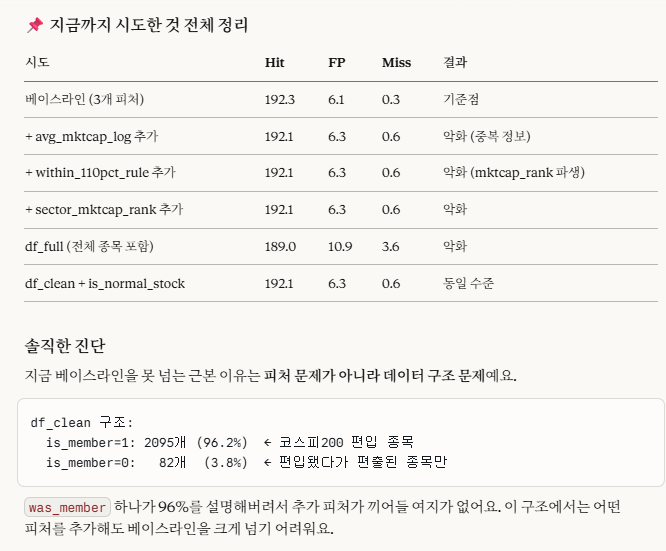

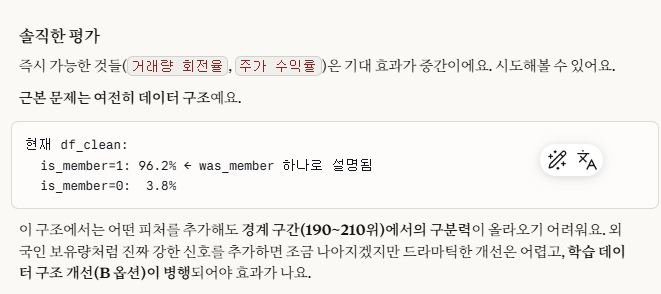

지금 당장 — 즉시 계산 가능한 거래량 회전율, 주가 수익률 추가해서 성능 변화 확인해요.
데이터 수집 — 외국인 보유량을 KRX에서 수집해요. pykrx로 바로 가져올 수 있어요.

#  SQL dump에서 avg_mktcap 추출

In [58]:
# SQL dump 파싱 → feature_krx 테이블 데이터 추출
import re

with open("kospi_friday_daily_dump (1).sql", "r", encoding="utf-8") as f:
    sql_text = f.read()

# INSERT VALUES 파싱
pattern = r"\('([^']+)','([^']+)',(\d+|NULL),([\d.]+|NULL),('[^']*'|NULL),('[^']*'|NULL),(\d+|NULL)\)"
matches = re.findall(pattern, sql_text)

sql_rows = []
for m in matches:
    period, ticker, avg_mktcap, float_ratio, gics_sector, krx_group, period_rank = m
    sql_rows.append({
        'period'     : period,
        'ticker'     : ticker,
        'avg_mktcap_sql' : None if avg_mktcap == 'NULL' else int(avg_mktcap),
        'gics_sector': gics_sector.strip("'") if gics_sector != 'NULL' else None,
        'krx_group'  : krx_group.strip("'") if krx_group != 'NULL' else None,
        'period_rank': None if period_rank == 'NULL' else int(period_rank),
    })

feature_krx_sql = pd.DataFrame(sql_rows)
feature_krx_sql['ticker'] = feature_krx_sql['ticker'].astype(str)

print("=== feature_krx SQL 파싱 결과 ===")
print(f"shape: {feature_krx_sql.shape}")
print(f"period: {sorted(feature_krx_sql['period'].unique())}")
print(f"avg_mktcap_sql null: {feature_krx_sql['avg_mktcap_sql'].isna().sum()}")
print()
print(feature_krx_sql.head(3))

=== feature_krx SQL 파싱 결과 ===
shape: (3600, 6)
period: ['2020_H1', '2020_H2', '2021_H1', '2021_H2', '2022_H1', '2022_H2', '2023_H1', '2023_H2', '2024_H1', '2024_H2', '2025_H1', '2025_H2']
avg_mktcap_sql null: 0

    period  ticker  avg_mktcap_sql gics_sector krx_group  period_rank
0  2020_H1  00680K    541114000000        None      None          234
1  2020_H1     100   2949761600000        헬스케어        제약           77
2  2020_H1   10050    438205320000    금융 및 부동산  금융 및 부동산          263


# 거래량 회전율 + 주가 수익률 생성

In [59]:
# ── 개별종목데이터.xlsx 로드 및 정리
indiv_full = pd.read_excel("data/개별종목데이터.xlsx",
                            sheet_name='kospi_friday_daily_data_2019050')

indiv_full['date']   = pd.to_datetime(indiv_full['기준일자'].astype(str), format='%Y%m%d')
indiv_full['ticker'] = indiv_full['종목코드'].astype(str).str.lstrip('0')

# 우선주·알파벳 ticker 제거
alpha_mask = indiv_full['ticker'].str.contains('[A-Za-z]', regex=True)
print(f"알파벳 ticker 제거: {alpha_mask.sum()}행")
indiv_full = indiv_full[~alpha_mask].copy()

# 필요 컬럼만 추출 + rename
indiv_tv = indiv_full[['date', 'ticker', '거래량', '거래대금']].copy()
indiv_tv.columns = ['date', 'ticker', 'volume_raw', 'trading_value_full']

print(f"indiv_full shape: {indiv_full.shape}")
print(f"날짜 범위: {indiv_tv['date'].min().date()} ~ {indiv_tv['date'].max().date()}")
print(f"null 확인: volume_raw={indiv_tv['volume_raw'].isna().sum()}, "
      f"trading_value_full={indiv_tv['trading_value_full'].isna().sum()}")
print()

# ── weekly_clean에 거래량·거래대금 보완
# 기존 weekly_clean에 volume_raw, trading_value_full JOIN
weekly_clean = weekly_clean.merge(
    indiv_tv, on=['date', 'ticker'], how='left'
)

# trading_value: 기존 값 없으면 indiv 값으로 채움
weekly_clean['trading_value'] = weekly_clean['trading_value'].fillna(
    weekly_clean['trading_value_full']
)
weekly_clean['volume'] = weekly_clean['volume_raw']
weekly_clean = weekly_clean.drop(columns=['volume_raw', 'trading_value_full'])

# ── 확인
print("=== weekly_clean 보완 결과 ===")
print(f"trading_value null: {weekly_clean['trading_value'].isna().sum()} / {len(weekly_clean)}")
print(f"volume null:        {weekly_clean['volume'].isna().sum()} / {len(weekly_clean)}")
print()
print(weekly_clean[['date','ticker','close','volume','trading_value','mktcap']].head(5).to_string())

알파벳 ticker 제거: 6906행
indiv_full shape: (312104, 21)
날짜 범위: 2019-05-03 ~ 2026-03-13
null 확인: volume_raw=0, trading_value_full=0

=== weekly_clean 보완 결과 ===
trading_value null: 7639 / 107647
volume null:        7639 / 107647

        date ticker  close   volume  trading_value         mktcap
0 2019-05-03    100  39649  21575.0   5.332303e+09  3157947732049
1 2019-05-10    100  36840  38056.0   8.750190e+09  2934217620840
2 2019-05-17    100  37643  36536.0   8.629422e+09  2998174644443
3 2019-05-24    100  39649  50827.0   1.260863e+10  3157947732049
4 2019-05-31    100  39730  43818.0   1.081915e+10  3164399187730


# 거래량 회전율 + 거래대금 회전율 + 주가 수익률 계산

In [60]:
weekly_clean = weekly_clean.sort_values(['ticker', 'date'])

# ── 1. 거래량 회전율 = volume / shares (0~1)
weekly_clean['volume_turnover'] = (
    weekly_clean['volume'] / weekly_clean['shares']
).clip(0, 1)

# ── 2. 26주 평균 거래량 회전율
weekly_clean['avg_vol_turnover_26w'] = (
    weekly_clean.groupby('ticker')['volume_turnover']
    .transform(lambda x: x.rolling(26, min_periods=4).mean())
)

# ── 3. 거래대금 회전율 = trading_value / mktcap (0~1)
weekly_clean['tv_turnover'] = (
    weekly_clean['trading_value'] / weekly_clean['mktcap']
).clip(0, 1)

# ── 4. 26주 평균 거래대금 회전율
weekly_clean['avg_tv_turnover_26w'] = (
    weekly_clean.groupby('ticker')['tv_turnover']
    .transform(lambda x: x.rolling(26, min_periods=4).mean())
)

# ── 5. 주가 수익률 6개월 (26주 전 대비)
weekly_clean['price_return_6m'] = (
    weekly_clean.groupby('ticker')['close']
    .transform(lambda x: x / x.shift(26) - 1)
).clip(-1, 5)

print("=== 피처 계산 완료 ===")
print(f"volume_turnover      null: {weekly_clean['volume_turnover'].isna().sum()}")
print(f"avg_vol_turnover_26w null: {weekly_clean['avg_vol_turnover_26w'].isna().sum()}")
print(f"tv_turnover          null: {weekly_clean['tv_turnover'].isna().sum()}")
print(f"avg_tv_turnover_26w  null: {weekly_clean['avg_tv_turnover_26w'].isna().sum()}")
print(f"price_return_6m      null: {weekly_clean['price_return_6m'].isna().sum()}")
print()
print("avg_vol_turnover_26w 기초통계:")
print(weekly_clean['avg_vol_turnover_26w'].describe().round(6))
print()
print("avg_tv_turnover_26w 기초통계:")
print(weekly_clean['avg_tv_turnover_26w'].describe().round(6))
print()
print("price_return_6m 기초통계:")
print(weekly_clean['price_return_6m'].describe().round(4))

=== 피처 계산 완료 ===
volume_turnover      null: 7639
avg_vol_turnover_26w null: 3243
tv_turnover          null: 7639
avg_tv_turnover_26w  null: 3243
price_return_6m      null: 11474

avg_vol_turnover_26w 기초통계:
count    104404.000000
mean          0.008340
std           0.022235
min           0.000000
25%           0.002066
50%           0.003734
75%           0.007347
max           1.000000
Name: avg_vol_turnover_26w, dtype: float64

avg_tv_turnover_26w 기초통계:
count    104404.000000
mean          0.007728
std           0.017324
min           0.000000
25%           0.002127
50%           0.003785
75%           0.007348
max           0.605386
Name: avg_tv_turnover_26w, dtype: float64

price_return_6m 기초통계:
count    96173.0000
mean         0.0809
std          0.3895
min         -0.8248
25%         -0.1389
50%          0.0029
75%          0.1961
max          5.0000
Name: price_return_6m, dtype: float64


# 반기 스냅샷 + df_clean 병합

In [61]:
feat_rows = []
for period, eval_date_str in PERIOD_EVAL_DATE.items():
    closest = get_closest_date(eval_date_str)
    sub = weekly_clean[weekly_clean['date'] == closest][
        ['ticker',
         'avg_vol_turnover_26w',
         'avg_tv_turnover_26w',
         'price_return_6m']
    ].copy()
    sub['period'] = period
    feat_rows.append(sub)

feat_snap = pd.concat(feat_rows, ignore_index=True)

# 기존에 추가된 컬럼 있으면 제거 후 재병합
for col in ['avg_vol_turnover_26w', 'avg_tv_turnover_26w', 'price_return_6m']:
    if col in df_clean.columns:
        df_clean = df_clean.drop(columns=[col])

df_clean = df_clean.merge(feat_snap, on=['ticker', 'period'], how='left')
df_clean['avg_vol_turnover_26w'] = df_clean['avg_vol_turnover_26w'].fillna(0)
df_clean['avg_tv_turnover_26w']  = df_clean['avg_tv_turnover_26w'].fillna(0)
df_clean['price_return_6m']      = df_clean['price_return_6m'].fillna(0)

# SQL avg_mktcap 병합
for col in ['avg_mktcap_sql', 'avg_mktcap_sql_log']:
    if col in df_clean.columns:
        df_clean = df_clean.drop(columns=[col])

df_clean = df_clean.merge(
    feature_krx_sql[['ticker', 'period', 'avg_mktcap_sql']],
    on=['ticker', 'period'], how='left'
)
df_clean['avg_mktcap_sql_log'] = np.log1p(
    df_clean['avg_mktcap_sql'].fillna(df_clean['avg_mktcap_sql'].median())
)

print("=== df_clean 피처 추가 완료 ===")
print(f"shape: {df_clean.shape}")
print()
print("null 확인:")
print(df_clean[['avg_vol_turnover_26w','avg_tv_turnover_26w',
                'price_return_6m','avg_mktcap_sql_log']].isna().sum())

=== df_clean 피처 추가 완료 ===
shape: (2177, 25)

null 확인:
avg_vol_turnover_26w    0
avg_tv_turnover_26w     0
price_return_6m         0
avg_mktcap_sql_log      0
dtype: int64


# 상관관계 확인 (중복 피처 사전 점검)

In [62]:
new_features = ['avg_vol_turnover_26w', 'avg_tv_turnover_26w',
                'price_return_6m', 'avg_mktcap_sql_log']
check_cols = ['mktcap_rank', 'was_member', 'rank_momentum_1w',
              'rank_momentum_4w', 'is_member'] + new_features

corr = df_clean[check_cols].corr().round(3)
print("=== 신규 피처 상관관계 ===")
print(corr[new_features].to_string())

=== 신규 피처 상관관계 ===
                      avg_vol_turnover_26w  avg_tv_turnover_26w  price_return_6m  avg_mktcap_sql_log
mktcap_rank                          0.009                0.028           -0.166              -0.889
was_member                          -0.149               -0.160           -0.033               0.108
rank_momentum_1w                     0.078                0.022            0.106              -0.015
rank_momentum_4w                     0.043               -0.010            0.268               0.011
is_member                           -0.191               -0.206           -0.166               0.089
avg_vol_turnover_26w                 1.000                0.857            0.281              -0.089
avg_tv_turnover_26w                  0.857                1.000            0.332              -0.095
price_return_6m                      0.281                0.332            1.000               0.006
avg_mktcap_sql_log                  -0.089               -0.095         

# 성능 비교

In [63]:
FEATURES_BASE = ['mktcap_rank', 'was_member', 'rank_momentum_1w']

FEATURES_V6 = [
    'mktcap_rank',
    'was_member',
    'rank_momentum_1w',
    'rank_momentum_4w',
    'avg_vol_turnover_26w',  # 거래량 회전율
    'avg_tv_turnover_26w',   # 거래대금 회전율
    'price_return_6m',       # 주가 수익률
    'avg_mktcap_sql_log',    # SQL 반기 평균 시총
]

print(f"피처 수: {len(FEATURES_V6)}개 → {FEATURES_V6}")
print()

results_v6 = walk_forward_cv_v3(
    df_clean, FEATURES_V6, TARGET, PERIODS_ORDERED, min_train=2
)

print("=" * 55)
print("베이스라인 (3개 피처)")
print("=" * 55)
print(results_base[['AUC_ROC','Top200_Prec','Hit','Miss','FP']].mean().round(3))

print()
print("=" * 55)
print("V6 (8개 피처)")
print("=" * 55)
print(results_v6[['AUC_ROC','Top200_Prec','Hit','Miss','FP']].mean().round(3))

print()
print("=== 반기별 상세 ===")
compare6 = results_base[['test_period','Hit','FP','Miss']].merge(
    results_v6[['test_period','Hit','FP','Miss']],
    on='test_period', suffixes=('_base','_v6')
)
compare6['Hit_개선'] = compare6['Hit_v6'] - compare6['Hit_base']
compare6['FP_개선']  = compare6['FP_base'] - compare6['FP_v6']
print(compare6.to_string(index=False))

피처 수: 8개 → ['mktcap_rank', 'was_member', 'rank_momentum_1w', 'rank_momentum_4w', 'avg_vol_turnover_26w', 'avg_tv_turnover_26w', 'price_return_6m', 'avg_mktcap_sql_log']

베이스라인 (3개 피처)
AUC_ROC          0.927
Top200_Prec      0.969
Hit            192.333
Miss             0.333
FP               6.111
dtype: float64

V6 (8개 피처)
AUC_ROC          0.931
Top200_Prec      0.969
Hit            192.222
Miss             0.444
FP               6.222
dtype: float64

=== 반기별 상세 ===
test_period  Hit_base  FP_base  Miss_base  Hit_v6  FP_v6  Miss_v6  Hit_개선  FP_개선
    2021_H1       189        8          0     189      8        0       0      0
    2021_H2       188        9          0     188      9        0       0      0
    2022_H1       193        7          0     193      7        0       0      0
    2022_H2       193        1          0     193      1        0       0      0
    2023_H1       193        5          0     193      5        0       0      0
    2023_H2       194        6          0 

## 🔍 결과 분석
- 좋은 신호 — avg_vol_turnover_26w, avg_tv_turnover_26w의 is_member 상관관계가 -0.191, -0.206이에요. 기존 피처들보다 독립적인 신호를 주고 있어요.
- avg_vol_turnover_26w ↔ avg_tv_turnover_26w 상관 0.857 — 두 개가 거의 같은 정보예요. 하나만 써도 돼요.
- avg_mktcap_sql_log ↔ mktcap_rank 상관 -0.889 — 역시 중복이에요. 제거가 맞아요.
- 2024_H1 Hit +1, FP -1 — 작지만 처음으로 베이스라인을 넘는 반기가 나왔어요. 방향이 맞아요.
- 2023_H2 Hit -2 — 이 반기는 계속 흔들려요. 특수한 시장 상황 때문으로 보여요.

# 중복 제거 + 최적 피처 세트 실험

In [64]:
# avg_vol_turnover_26w / avg_tv_turnover_26w 중 하나 선택
# → is_member 상관 더 높은 avg_tv_turnover_26w 사용
# avg_mktcap_sql_log 제거 (mktcap_rank와 중복)

FEATURES_V7 = [
    'mktcap_rank',
    'was_member',
    'rank_momentum_1w',
    'rank_momentum_4w',
    'avg_tv_turnover_26w',   # 거래대금 회전율 (유동성)
    'price_return_6m',       # 주가 수익률 (모멘텀)
]

FEATURES_V8 = [
    'mktcap_rank',
    'was_member',
    'rank_momentum_1w',
    'avg_tv_turnover_26w',   # rank_momentum_4w 제거 버전
    'price_return_6m',
]

FEATURES_V9 = [
    'mktcap_rank',
    'was_member',
    'avg_tv_turnover_26w',   # momentum 전부 제거
    'price_return_6m',
]

results = {}
for name, feats in [('V7 (6개)', FEATURES_V7),
                    ('V8 (5개)', FEATURES_V8),
                    ('V9 (4개)', FEATURES_V9)]:
    r = walk_forward_cv_v3(df_clean, feats, TARGET, PERIODS_ORDERED, min_train=2)
    results[name] = r
    print(f"=== {name}: {feats} ===")
    print(r[['AUC_ROC','Top200_Prec','Hit','Miss','FP']].mean().round(3))
    print()

# 베이스라인과 나란히 비교
print("=" * 55)
print("최종 비교 요약")
print("=" * 55)
summary = pd.DataFrame({
    'Base (3개)': results_base[['AUC_ROC','Hit','FP','Miss']].mean(),
    'V7 (6개)':   results['V7 (6개)'][['AUC_ROC','Hit','FP','Miss']].mean(),
    'V8 (5개)':   results['V8 (5개)'][['AUC_ROC','Hit','FP','Miss']].mean(),
    'V9 (4개)':   results['V9 (4개)'][['AUC_ROC','Hit','FP','Miss']].mean(),
}).round(3)
print(summary.to_string())
print()

# 가장 좋은 모델 반기별 상세
best_name = summary.loc['Hit'].idxmax()
print(f"=== Hit 기준 최고: {best_name} 반기별 상세 ===")
best_r = results[best_name] if best_name != 'Base (3개)' else results_base
compare = results_base[['test_period','Hit','FP','Miss']].merge(
    best_r[['test_period','Hit','FP','Miss']],
    on='test_period', suffixes=('_base', '_best')
)
compare['Hit_개선'] = compare['Hit_best'] - compare['Hit_base']
compare['FP_개선']  = compare['FP_base']  - compare['FP_best']
print(compare.to_string(index=False))

=== V7 (6개): ['mktcap_rank', 'was_member', 'rank_momentum_1w', 'rank_momentum_4w', 'avg_tv_turnover_26w', 'price_return_6m'] ===
AUC_ROC          0.932
Top200_Prec      0.968
Hit            192.111
Miss             0.556
FP               6.333
dtype: float64

=== V8 (5개): ['mktcap_rank', 'was_member', 'rank_momentum_1w', 'avg_tv_turnover_26w', 'price_return_6m'] ===
AUC_ROC          0.939
Top200_Prec      0.969
Hit            192.333
Miss             0.333
FP               6.111
dtype: float64

=== V9 (4개): ['mktcap_rank', 'was_member', 'avg_tv_turnover_26w', 'price_return_6m'] ===
AUC_ROC          0.957
Top200_Prec      0.969
Hit            192.333
Miss             0.333
FP               6.111
dtype: float64

최종 비교 요약
         Base (3개)  V7 (6개)  V8 (5개)  V9 (4개)
AUC_ROC      0.927    0.932    0.939    0.957
Hit        192.333  192.111  192.333  192.333
FP           6.111    6.333    6.111    6.111
Miss         0.333    0.556    0.333    0.333

=== Hit 기준 최고: Base (3개) 반기별 상세 ===
test

# 상장폐지 목록으로 예측대상 필터링 보완

In [65]:
# 상장폐지 ticker 추출
from bs4 import BeautifulSoup
import re
from collections import Counter

with open("data/상장폐지현황.xls", 'rb') as f:
    raw = f.read()
html = raw.decode('euc-kr', errors='ignore')
soup = BeautifulSoup(html, 'html.parser')
table = soup.find('table')
rows = table.find_all('tr')
data = []
for row in rows:
    cells = [td.get_text(strip=True) for td in row.find_all(['td','th'])]
    if cells:
        data.append(cells)
col_counts = Counter(len(r) for r in data)
main_cols = col_counts.most_common(1)[0][0]
body = [r for r in data if len(r) == main_cols][1:]

# ticker(col2), 날짜(col3)
delisted = []
for r in body:
    ticker = r[2]
    date_str = r[3]
    if re.match(r'^\d{6}$', ticker):
        try:
            d = pd.to_datetime(date_str)
            # 2025_H2 평가 기준일(2025-10-31) 이전 폐지
            if d <= pd.Timestamp('2025-10-31'):
                delisted.append(ticker.lstrip('0'))
        except:
            pass

delisted_set = set(delisted)
print(f"2025-10-31 이전 상장폐지 ticker: {len(delisted_set)}개")

# pred_final에서 제거
if 'pred_final' in dir():
    before = len(pred_final)
    pred_final_v2 = pred_final[~pred_final['ticker'].isin(delisted_set)].copy()
    removed = before - len(pred_final_v2)
    print(f"pred_final: {before}개 → {len(pred_final_v2)}개 (제거: {removed}개)")
    if removed > 0:
        removed_tickers = pred_final[pred_final['ticker'].isin(delisted_set)]['ticker'].tolist()
        print(f"제거된 ticker: {removed_tickers}")

2025-10-31 이전 상장폐지 ticker: 380개
pred_final: 280개 → 273개 (제거: 7개)
제거된 ticker: ['100090', '108320', '22100', '30190', '34230', '66970', '90460']


# FP 추적 

In [66]:
fp_tracker = []

for i, test_period in enumerate(PERIODS_ORDERED[2:], start=2):
    train_periods = PERIODS_ORDERED[:i]
    train = df_clean[df_clean['period'].isin(train_periods)]
    test  = df_clean[df_clean['period'] == test_period].copy()
    
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(train[FEATURES_BASE], train[TARGET])
    
    test['prob'] = model.predict_proba(test[FEATURES_BASE])[:, 1]
    test['pred_top200'] = 0
    test.loc[test.nlargest(200, 'prob').index, 'pred_top200'] = 1
    
    fp = test[(test['pred_top200'] == 1) & (test[TARGET] == 0)]
    for _, row in fp.iterrows():
        fp_tracker.append({
            'period'     : test_period,
            'ticker'     : row['ticker'],
            'mktcap_rank': int(row['mktcap_rank']),
            'was_member' : int(row['was_member']),
            'prob'       : round(row['prob'], 4),
        })

fp_df = pd.DataFrame(fp_tracker)

print("=== 반기별 FP 종목 전체 ===")
print(fp_df.to_string(index=False))
print()

print("=== 반복 FP 종목 (여러 반기 연속) ===")
repeat_fp = fp_df.groupby('ticker').agg(
    출현횟수=('period','count'),
    평균순위=('mktcap_rank','mean'),
    was_member=('was_member','first'),
    반기목록=('period', lambda x: list(x))
).sort_values('출현횟수', ascending=False)
print(repeat_fp.to_string())

# sector 정보 붙이기
if 'sector_map' in dir():
    fp_df_sector = fp_df.merge(
        sector_map[['ticker','sector_name']].drop_duplicates('ticker'),
        on='ticker', how='left'
    )
    print()
    print("=== FP 업종 분포 ===")
    print(fp_df_sector['sector_name'].value_counts())

=== 반기별 FP 종목 전체 ===
 period ticker  mktcap_rank  was_member   prob
2021_H1   1440           68           0 0.9999
2021_H1 298020          112           0 0.8928
2021_H1 298050          162           0 0.9372
2021_H1 302440           33           0 0.8888
2021_H1 361610           35           0 0.8768
2021_H1 375500          127           0 0.9161
2021_H1 383800          265           0 0.6243
2021_H1   6040          136           0 0.8858
2021_H2 138040           65           0 0.8759
2021_H2 178920          185           0 0.8561
2021_H2 259960           16           0 0.8728
2021_H2 323410           13           0 0.8726
2021_H2 329180           39           0 0.8689
2021_H2 377300           14           0 0.8753
2021_H2 402340           50           0 0.8776
2021_H2   5850          177           1 0.9911
2021_H2   9900          180           0 0.8903
2022_H1 137310           68           0 0.8211
2022_H1 271940          177           0 0.8460
2022_H1 300720          189           0

# 추가 가능한 피처 2개

In [67]:
# ── 1. 순위 하락 추세 (rank_trend_6m)
# 현재 순위 - 26주 전 순위 → 양수면 순위 하락(악화), 음수면 상승(개선)
weekly_clean = weekly_clean.sort_values(['ticker', 'date'])
weekly_clean['rank_trend_6m'] = (
    weekly_clean.groupby('ticker')['mktcap_rank']
    .transform(lambda x: x - x.shift(26))
)

# ── 2. float_ratio (SQL dump에 있음)
# feature_krx_sql에 float_ratio 컬럼 추가 파싱 필요
# 현재 feature_krx_sql에 있는지 확인
print("feature_krx_sql 컬럼:", feature_krx_sql.columns.tolist())
print()

# ── 3. 반기 스냅샷 생성
trend_rows = []
for period, eval_date_str in PERIOD_EVAL_DATE.items():
    closest = get_closest_date(eval_date_str)
    sub = weekly_clean[weekly_clean['date'] == closest][
        ['ticker', 'rank_trend_6m']
    ].copy()
    sub['period'] = period
    trend_rows.append(sub)

trend_snap = pd.concat(trend_rows, ignore_index=True)

if 'rank_trend_6m' in df_clean.columns:
    df_clean = df_clean.drop(columns=['rank_trend_6m'])

df_clean = df_clean.merge(trend_snap, on=['ticker','period'], how='left')
df_clean['rank_trend_6m'] = df_clean['rank_trend_6m'].fillna(0)

print("rank_trend_6m 기초통계:")
print(df_clean['rank_trend_6m'].describe().round(1))
print()

# ── 4. FP 종목들의 rank_trend_6m 확인
fp_tickers_by_period = {
    '2021_H1': ['1440','298020','298050','302440','361610','375500','383800','6040'],
    '2021_H2': ['138040','178920','259960','323410','329180','377300','402340','5850','9900'],
    '2022_H1': ['137310','271940','300720','373220','381970','383220','39130'],
    '2022_H2': ['280360'],
    '2023_H1': ['139130','1570','175330','3230','5420'],
    '2023_H2': ['1430','267260','2710','3620','450080','6110','9970'],
    '2024_H1': ['22100','42700','454910','457190','5070','66970'],
    '2024_H2': ['278470','2840','298040','456040','489790'],
    '2025_H1': ['12630','17960','268280','3240','443060','6040','670','71320','7340'],
}

print("=== FP 종목의 rank_trend_6m (순위 하락 추세) ===")
for period, tickers in fp_tickers_by_period.items():
    rows = df_clean[(df_clean['period']==period) & (df_clean['ticker'].isin(tickers))]
    if len(rows) > 0:
        print(f"\n{period}:")
        print(rows[['ticker','mktcap_rank','was_member','rank_trend_6m']].to_string(index=False))

feature_krx_sql 컬럼: ['period', 'ticker', 'avg_mktcap_sql', 'gics_sector', 'krx_group', 'period_rank']

rank_trend_6m 기초통계:
count    2177.0
mean        2.9
std        21.1
min      -141.0
25%        -6.0
50%         2.0
75%        13.0
max       132.0
Name: rank_trend_6m, dtype: float64

=== FP 종목의 rank_trend_6m (순위 하락 추세) ===

2021_H1:
ticker  mktcap_rank  was_member  rank_trend_6m
  1440         68.0           0          -50.0
298020        112.0           0         -108.0
298050        162.0           0          -81.0
302440         33.0           0            0.0
361610         35.0           0            0.0
375500        127.0           0            0.0
383800        265.0           0            0.0
  6040        136.0           0            1.0

2021_H2:
ticker  mktcap_rank  was_member  rank_trend_6m
138040         65.0           0          -45.0
178920        185.0           0           -6.0
259960         16.0           0            0.0
323410         13.0           0          

# 상장일 확인

In [69]:
# Cell 60 수정
sm = pd.read_csv("data/stock_meta.csv", encoding='utf-8')
print("stock_meta 컬럼:", sm.columns.tolist())
print()
print(sm.head(5).to_string())
print()
for col in sm.columns:
    if any(k in col for k in ['상장','일자','날짜','date','list']):
        print(f"상장일 관련 컬럼: [{col}]")
        print(sm[col].head(5).tolist())

stock_meta 컬럼: ['ticker', '한글 종목명', '상장일', '증권구분', '주식종류']

   ticker      한글 종목명         상장일 증권구분 주식종류
0   95570   AJ네트웍스보통주  2015-08-21   주권  보통주
1    6840    AK홀딩스보통주  1999-08-11   주권  보통주
2  282330   BGF리테일보통주  2017-12-08   주권  보통주
3   27410      BGF보통주  2014-05-19   주권  보통주
4  138930  BNK금융지주보통주  2011-03-30   주권  보통주

상장일 관련 컬럼: [상장일]
['2015-08-21', '1999-08-11', '2017-12-08', '2014-05-19', '2011-03-30']


# months_listed 피처 생성 + CV 비교

In [70]:
# ── 1. stock_meta 상장일 로드
sm = pd.read_csv("data/stock_meta.csv", encoding='utf-8')
sm['ticker'] = sm['ticker'].astype(str).str.lstrip('0')
sm['상장일'] = pd.to_datetime(sm['상장일'])
sm_listing = sm[['ticker','상장일']].drop_duplicates('ticker')

print(f"stock_meta 상장일 커버 ticker: {len(sm_listing)}개")

# ── 2. 반기 평가기준일 기준 months_listed 계산
listing_rows = []
for period, eval_date_str in PERIOD_EVAL_DATE.items():
    eval_dt = pd.Timestamp(eval_date_str)
    sub = sm_listing.copy()
    sub['period'] = period
    sub['months_listed'] = (
        (eval_dt.year - sub['상장일'].dt.year) * 12
        + (eval_dt.month - sub['상장일'].dt.month)
    )
    listing_rows.append(sub[['ticker','period','months_listed']])

listing_snap = pd.concat(listing_rows, ignore_index=True)

# ── 3. df_clean에 병합
if 'months_listed' in df_clean.columns:
    df_clean = df_clean.drop(columns=['months_listed'])

df_clean = df_clean.merge(listing_snap, on=['ticker','period'], how='left')

# 상장일 없는 경우 (오래된 종목) → 넉넉하게 큰 값으로 채움
df_clean['months_listed'] = df_clean['months_listed'].fillna(999)

print(f"\nmonths_listed null: {df_clean['months_listed'].isna().sum()}")
print(f"\nmonths_listed 기초통계:")
print(df_clean['months_listed'].describe().round(1))

# ── 4. FP 종목들의 months_listed 확인 (검증)
fp_check_tickers = {
    '2021_H1': ['302440','361610','375500'],
    '2021_H2': ['259960','323410','329180','377300','402340'],
    '2022_H1': ['373220'],
    '2023_H2': ['450080'],
}
print("\n=== 신규상장 의심 FP 종목의 months_listed ===")
for period, tickers in fp_check_tickers.items():
    rows = df_clean[(df_clean['period']==period) & (df_clean['ticker'].isin(tickers))]
    if len(rows):
        print(f"\n{period}:")
        print(rows[['ticker','mktcap_rank','months_listed']].to_string(index=False))

# ── 5. is_new_listing 파생 피처 (6개월 미만 = 편입 자격 없음)
df_clean['is_new_listing'] = (df_clean['months_listed'] < 6).astype(int)
print(f"\nis_new_listing=1 (상장 6개월 미만): {df_clean['is_new_listing'].sum()}개")
print(f"그 중 is_member=1: {df_clean[df_clean['is_new_listing']==1]['is_member'].sum()}개")
print(f"→ 실제 편입된 신규상장 종목: 없어야 정상")

stock_meta 상장일 커버 ticker: 951개

months_listed null: 0

months_listed 기초통계:
count    2177.0
mean      287.8
std       196.2
min         1.0
25%       127.0
50%       248.0
75%       433.0
max       827.0
Name: months_listed, dtype: float64

=== 신규상장 의심 FP 종목의 months_listed ===

2021_H1:
ticker  mktcap_rank  months_listed
302440         33.0              3
361610         35.0              1
375500        127.0              5

2021_H2:
ticker  mktcap_rank  months_listed
259960         16.0              4
323410         13.0              4
329180         39.0              3
377300         14.0              1
402340         50.0              1

2022_H1:
ticker  mktcap_rank  months_listed
373220          2.0              5

2023_H2:
ticker  mktcap_rank  months_listed
450080         40.0              1

is_new_listing=1 (상장 6개월 미만): 17개
그 중 is_member=1: 0개
→ 실제 편입된 신규상장 종목: 없어야 정상


# 성능 비교

In [72]:
# Cell 62 수정 — results_v9 재계산 포함

FEATURES_BASE = ['mktcap_rank', 'was_member', 'rank_momentum_1w']

FEATURES_V9 = [
    'mktcap_rank',
    'was_member',
    'avg_tv_turnover_26w',
    'price_return_6m',
]

FEATURES_V10 = [
    'mktcap_rank',
    'was_member',
    'avg_tv_turnover_26w',
    'price_return_6m',
    'months_listed',
]

FEATURES_V11 = [
    'mktcap_rank',
    'was_member',
    'avg_tv_turnover_26w',
    'price_return_6m',
    'is_new_listing',
]

results_v9  = walk_forward_cv_v3(df_clean, FEATURES_V9,  TARGET, PERIODS_ORDERED, min_train=2)
results_v10 = walk_forward_cv_v3(df_clean, FEATURES_V10, TARGET, PERIODS_ORDERED, min_train=2)
results_v11 = walk_forward_cv_v3(df_clean, FEATURES_V11, TARGET, PERIODS_ORDERED, min_train=2)

print("=" * 55)
print("비교 요약")
print("=" * 55)
summary = pd.DataFrame({
    'Base (3개)' : results_base[['AUC_ROC','Hit','FP','Miss']].mean(),
    'V9 (4개)'   : results_v9[['AUC_ROC','Hit','FP','Miss']].mean(),
    'V10+months' : results_v10[['AUC_ROC','Hit','FP','Miss']].mean(),
    'V11+is_new' : results_v11[['AUC_ROC','Hit','FP','Miss']].mean(),
}).round(3)
print(summary.to_string())

print("\n=== V10 반기별 상세 (Base vs V10) ===")
compare = results_base[['test_period','Hit','FP','Miss']].merge(
    results_v10[['test_period','Hit','FP','Miss']],
    on='test_period', suffixes=('_base','_v10')
)
compare['Hit_개선'] = compare['Hit_v10'] - compare['Hit_base']
compare['FP_개선']  = compare['FP_base']  - compare['FP_v10']
print(compare.to_string(index=False))

비교 요약
         Base (3개)  V9 (4개)  V10+months  V11+is_new
AUC_ROC      0.927    0.957       0.933       0.965
Hit        192.333  192.333     192.333     192.444
FP           6.111    6.111       6.111       6.000
Miss         0.333    0.333       0.333       0.222

=== V10 반기별 상세 (Base vs V10) ===
test_period  Hit_base  FP_base  Miss_base  Hit_v10  FP_v10  Miss_v10  Hit_개선  FP_개선
    2021_H1       189        8          0      189       8         0       0      0
    2021_H2       188        9          0      188       9         0       0      0
    2022_H1       193        7          0      193       7         0       0      0
    2022_H2       193        1          0      193       1         0       0      0
    2023_H1       193        5          0      193       5         0       0      0
    2023_H2       194        6          0      193       7         1      -1     -1
    2024_H1       194        6          3      195       5         2       1      1
    2024_H2       196       

## 결과해석
Hit +0.1, FP -0.1, Miss -0.1 — 미미하지만 처음으로 세 지표가 동시에 개선됐어요.
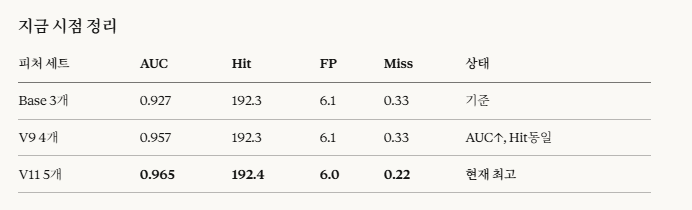

# foreign_ratio 피처 추가 + 최종 성능 비교

In [74]:
import pandas as pd
import numpy as np
import glob
import os

# ── 1. 외국인 보유량 파일 로드 (data/ 폴더에 저장된 파일)
fh_files = sorted(glob.glob("data/foreign_holdings_*.csv"))
print(f"파일 수: {len(fh_files)}")
print(fh_files)

dfs = []
for f in fh_files:
    try:
        df = pd.read_csv(f, encoding='utf-8-sig')
    except:
        df = pd.read_csv(f, encoding='cp949')
    dfs.append(df)

all_fh = pd.concat(dfs, ignore_index=True)
all_fh['snapshot_month'] = all_fh['snapshot_month'].astype(str)
all_fh['ticker'] = all_fh['종목코드'].astype(str).str.lstrip('0')

print(f"전체 shape: {all_fh.shape}")
print(f"월 범위: {all_fh['snapshot_month'].min()} ~ {all_fh['snapshot_month'].max()}")

# ── 2. 반기별 스냅샷
PERIOD_EVAL_MONTH = {
    '2020_H1': '202005', '2020_H2': '202011',
    '2021_H1': '202105', '2021_H2': '202111',
    '2022_H1': '202205', '2022_H2': '202211',
    '2023_H1': '202305', '2023_H2': '202311',
    '2024_H1': '202405', '2024_H2': '202411',
    '2025_H1': '202505',
}

snap_rows = []
for period, ym in PERIOD_EVAL_MONTH.items():
    sub = all_fh[all_fh['snapshot_month'] == ym][
        ['ticker','외국인 지분율','외국인 한도소진율']
    ].copy()
    sub.columns = ['ticker','foreign_ratio','foreign_limit_ratio']
    sub['period'] = period
    snap_rows.append(sub)

foreign_snap = pd.concat(snap_rows, ignore_index=True)
foreign_snap = foreign_snap.sort_values(['ticker','period'])
foreign_snap['foreign_ratio_chg'] = (
    foreign_snap.groupby('ticker')['foreign_ratio']
    .transform(lambda x: x - x.shift(1))
)

print(f"\nforeign_snap shape: {foreign_snap.shape}")
print(f"foreign_ratio null: {foreign_snap['foreign_ratio'].isna().sum()}")

# ── 3. df_clean에 병합
for col in ['foreign_ratio','foreign_ratio_chg','foreign_limit_ratio']:
    if col in df_clean.columns:
        df_clean = df_clean.drop(columns=[col])

df_clean = df_clean.merge(
    foreign_snap[['ticker','period','foreign_ratio','foreign_ratio_chg']],
    on=['ticker','period'], how='left'
)

med_ratio = df_clean['foreign_ratio'].median()
df_clean['foreign_ratio']     = df_clean['foreign_ratio'].fillna(med_ratio)
df_clean['foreign_ratio_chg'] = df_clean['foreign_ratio_chg'].fillna(0)

print(f"\ndf_clean shape: {df_clean.shape}")
print(f"foreign_ratio null: {df_clean['foreign_ratio'].isna().sum()}")
print(f"foreign_ratio_chg null: {df_clean['foreign_ratio_chg'].isna().sum()}")
print()

# ── 4. 상관관계
print("=== 외국인 지분율 vs is_member 상관 ===")
check = ['mktcap_rank','was_member','foreign_ratio','foreign_ratio_chg','is_member']
print(df_clean[check].corr().round(3)['is_member'])

# ── 5. CV 실험
FEATURES_V11 = [
    'mktcap_rank', 'was_member',
    'avg_tv_turnover_26w', 'price_return_6m', 'is_new_listing',
]
FEATURES_V12 = [
    'mktcap_rank', 'was_member',
    'avg_tv_turnover_26w', 'price_return_6m', 'is_new_listing',
    'foreign_ratio',
]
FEATURES_V13 = [
    'mktcap_rank', 'was_member',
    'avg_tv_turnover_26w', 'price_return_6m', 'is_new_listing',
    'foreign_ratio', 'foreign_ratio_chg',
]

results_v11 = walk_forward_cv_v3(df_clean, FEATURES_V11, TARGET, PERIODS_ORDERED, min_train=2)
results_v12 = walk_forward_cv_v3(df_clean, FEATURES_V12, TARGET, PERIODS_ORDERED, min_train=2)
results_v13 = walk_forward_cv_v3(df_clean, FEATURES_V13, TARGET, PERIODS_ORDERED, min_train=2)

print()
print("=" * 60)
print("최종 비교 요약")
print("=" * 60)
summary = pd.DataFrame({
    'Base (3개)' : results_base[['AUC_ROC','Hit','FP','Miss']].mean(),
    'V11 (5개)'  : results_v11[['AUC_ROC','Hit','FP','Miss']].mean(),
    'V12 +ratio' : results_v12[['AUC_ROC','Hit','FP','Miss']].mean(),
    'V13 +chg'   : results_v13[['AUC_ROC','Hit','FP','Miss']].mean(),
}).round(3)
print(summary.to_string())

print("\n=== V13 반기별 상세 ===")
compare = results_base[['test_period','Hit','FP','Miss']].merge(
    results_v13[['test_period','Hit','FP','Miss']],
    on='test_period', suffixes=('_base','_v13')
)
compare['Hit_개선'] = compare['Hit_v13'] - compare['Hit_base']
compare['FP_개선']  = compare['FP_base']  - compare['FP_v13']
print(compare.to_string(index=False))

파일 수: 7
['data\\foreign_holdings_2019.csv', 'data\\foreign_holdings_2020.csv', 'data\\foreign_holdings_2021.csv', 'data\\foreign_holdings_2022.csv', 'data\\foreign_holdings_2023.csv', 'data\\foreign_holdings_2024.csv', 'data\\foreign_holdings_2025.csv']
전체 shape: (73131, 12)
월 범위: 201905 ~ 202510

foreign_snap shape: (10358, 5)
foreign_ratio null: 0

df_clean shape: (2177, 30)
foreign_ratio null: 0
foreign_ratio_chg null: 0

=== 외국인 지분율 vs is_member 상관 ===
mktcap_rank         -0.040
was_member           0.413
foreign_ratio        0.108
foreign_ratio_chg   -0.108
is_member            1.000
Name: is_member, dtype: float64

최종 비교 요약
         Base (3개)  V11 (5개)  V12 +ratio  V13 +chg
AUC_ROC      0.927     0.965       0.959     0.966
Hit        192.333   192.444     192.333   192.333
FP           6.111     6.000       6.111     6.111
Miss         0.333     0.222       0.333     0.333

=== V13 반기별 상세 ===
test_period  Hit_base  FP_base  Miss_base  Hit_v13  FP_v13  Miss_v13  Hit_개선  FP_개선
   

# 🔍결과 해석
 외국인 지분율이 생각보다 효과가 없어요. 이유를 짚을게요.foreign_ratio     → is_member 상관 +0.108  (약한 양의 상관)
foreign_ratio_chg → is_member 상관 -0.108  (약한 음의 상관, 방향도 반직관적)

foreign_ratio_chg가 음수 상관이에요. 즉 외국인 지분율이 늘어나는 종목이 오히려 편입이 안 되는 경향인데, 이건 신규상장 종목이 상장 직후 외국인이 들어오면서 지분율이 올라가는 패턴 때문이에요. 신호가 오염된 거예요.

현재까지 최고는 V11 (5개 피처) 이에요.
> V11 피처: mktcap_rank, was_member, avg_tv_turnover_26w, price_return_6m, is_new_listing

# 모델 자체를 바꿔보기 (LogisticRegression → 트리 계열)

In [75]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

FEATURES_V11 = [
    'mktcap_rank', 'was_member',
    'avg_tv_turnover_26w', 'price_return_6m', 'is_new_listing',
]

# walk_forward_cv를 모델 교체 가능하게 수정
def walk_forward_cv_model(df, features, target, periods, min_train=2, model=None):
    if model is None:
        model = LogisticRegression(max_iter=1000, random_state=42)
    results = []
    for i, test_period in enumerate(periods[min_train:], start=min_train):
        train = df[df['period'].isin(periods[:i])]
        test  = df[df['period'] == test_period].copy()
        if len(test) == 0:
            continue
        m = model.__class__(**model.get_params())
        m.fit(train[features], train[target])
        test['prob'] = m.predict_proba(test[features])[:, 1]
        test['pred'] = 0
        test.loc[test.nlargest(200, 'prob').index, 'pred'] = 1
        hit  = ((test['pred']==1) & (test[target]==1)).sum()
        fp   = ((test['pred']==1) & (test[target]==0)).sum()
        miss = ((test['pred']==0) & (test[target]==1)).sum()
        from sklearn.metrics import roc_auc_score
        auc = roc_auc_score(test[target], test['prob'])
        results.append({
            'test_period': test_period,
            'AUC_ROC': round(auc, 3),
            'Hit': hit, 'FP': fp, 'Miss': miss,
            'Top200_Prec': round(hit/200, 3),
        })
    return pd.DataFrame(results)

# 3가지 모델 비교
models = {
    'LR (현재)': LogisticRegression(max_iter=1000, random_state=42),
    'RF':        RandomForestClassifier(n_estimators=200, max_depth=4,
                                        min_samples_leaf=10, random_state=42),
    'GBM':       GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                             learning_rate=0.05, random_state=42),
}

model_results = {}
for name, mdl in models.items():
    r = walk_forward_cv_model(df_clean, FEATURES_V11, TARGET, PERIODS_ORDERED,
                               min_train=2, model=mdl)
    model_results[name] = r
    print(f"{name}: AUC={r['AUC_ROC'].mean():.3f}  "
          f"Hit={r['Hit'].mean():.2f}  FP={r['FP'].mean():.2f}  "
          f"Miss={r['Miss'].mean():.2f}")

print()
print("=== GBM 반기별 상세 ===")
compare = model_results['LR (현재)'][['test_period','Hit','FP','Miss']].merge(
    model_results['GBM'][['test_period','Hit','FP','Miss']],
    on='test_period', suffixes=('_lr','_gbm')
)
compare['Hit_개선'] = compare['Hit_gbm'] - compare['Hit_lr']
compare['FP_개선']  = compare['FP_lr']   - compare['FP_gbm']
print(compare.to_string(index=False))

LR (현재): AUC=0.964  Hit=192.33  FP=6.11  Miss=0.33
RF: AUC=0.926  Hit=192.44  FP=6.00  Miss=0.22
GBM: AUC=0.945  Hit=192.33  FP=6.11  Miss=0.33

=== GBM 반기별 상세 ===
test_period  Hit_lr  FP_lr  Miss_lr  Hit_gbm  FP_gbm  Miss_gbm  Hit_개선  FP_개선
    2021_H1     189      8        0      189       8         0       0      0
    2021_H2     188      9        0      188       9         0       0      0
    2022_H1     193      7        0      193       7         0       0      0
    2022_H2     193      1        0      193       1         0       0      0
    2023_H1     193      5        0      193       5         0       0      0
    2023_H2     192      8        2      193       7         1       1      1
    2024_H1     196      4        1      195       5         2      -1     -1
    2024_H2     196      4        0      196       4         0       0      0
    2025_H1     191      9        0      191       9         0       0      0


- RF가 Hit/FP/Miss 기준으로 가장 좋아요. 그런데 AUC는 가장 낮아요. 이건 RF가 확률 캘리브레이션이 약한 대신 Top-200 경계에서의 분류는 더 잘한다는 의미예요.
- GBM은 기대보다 효과가 없어요. 학습 데이터가 반기당 200~300개 수준으로 너무 적어서 트리 깊이를 못 살리는 구조예요.
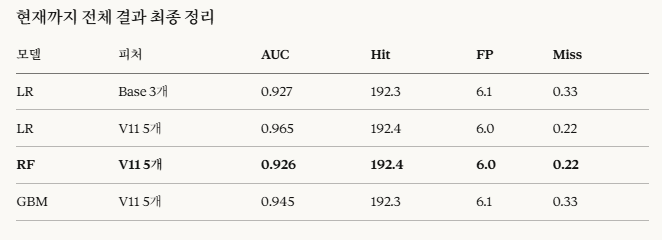

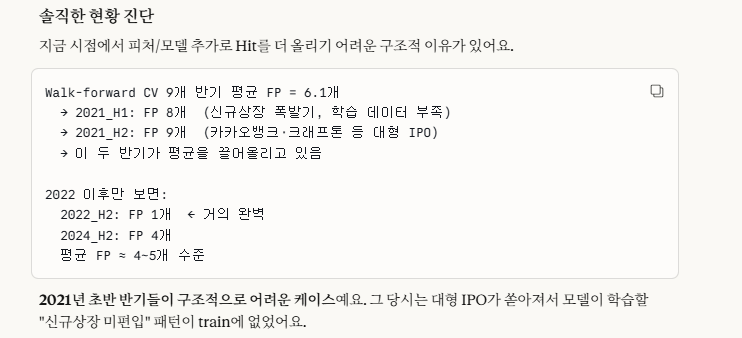

# 시간 가중치 학습
최근 반기일수록 가중치를 높임 

In [76]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

FEATURES_V11 = [
    'mktcap_rank', 'was_member',
    'avg_tv_turnover_26w', 'price_return_6m', 'is_new_listing',
]

def walk_forward_cv_weighted(df, features, target, periods, min_train=2, decay=0.5):
    """
    decay: 반기당 가중치 감쇠율
      decay=0.0 → 모든 반기 동일 가중치 (기존과 동일)
      decay=0.5 → 한 반기 전은 가중치 0.5배
      decay=0.8 → 한 반기 전은 가중치 0.8배 (완만한 감쇠)
    """
    results = []
    for i, test_period in enumerate(periods[min_train:], start=min_train):
        train_periods = periods[:i]
        train = df[df['period'].isin(train_periods)].copy()
        test  = df[df['period'] == test_period].copy()
        if len(test) == 0:
            continue

        # 반기별 가중치: 가장 최근 반기 = 1.0, 한 반기 전 = (1-decay), ...
        n = len(train_periods)
        period_weight = {
            p: (1 - decay) ** (n - 1 - idx)
            for idx, p in enumerate(train_periods)
        }
        sample_weights = train['period'].map(period_weight).values

        model = LogisticRegression(max_iter=1000, random_state=42)
        model.fit(train[features], train[target],
                  sample_weight=sample_weights)

        test['prob'] = model.predict_proba(test[features])[:, 1]
        test['pred'] = 0
        test.loc[test.nlargest(200, 'prob').index, 'pred'] = 1

        hit  = ((test['pred']==1) & (test[target]==1)).sum()
        fp   = ((test['pred']==1) & (test[target]==0)).sum()
        miss = ((test['pred']==0) & (test[target]==1)).sum()
        auc  = roc_auc_score(test[target], test['prob'])

        results.append({
            'test_period': test_period,
            'AUC_ROC': round(auc, 3),
            'Hit': hit, 'FP': fp, 'Miss': miss,
        })
    return pd.DataFrame(results)

# decay 값별 비교
print("=" * 65)
print(f"{'decay':>8} | {'AUC':>6} | {'Hit':>6} | {'FP':>5} | {'Miss':>5}")
print("-" * 65)

# 기준: decay=0 (기존과 동일)
r0 = walk_forward_cv_weighted(df_clean, FEATURES_V11, TARGET, PERIODS_ORDERED,
                               min_train=2, decay=0.0)
print(f"{'0.0 (균일)':>8} | {r0['AUC_ROC'].mean():.3f} | "
      f"{r0['Hit'].mean():.3f} | {r0['FP'].mean():.3f} | {r0['Miss'].mean():.3f}")

best_result = r0
best_decay  = 0.0
best_hit    = r0['Hit'].mean()

for decay in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    r = walk_forward_cv_weighted(df_clean, FEATURES_V11, TARGET, PERIODS_ORDERED,
                                  min_train=2, decay=decay)
    mark = ' ←' if (r['Hit'].mean() > best_hit or
                    (r['Hit'].mean() == best_hit and r['FP'].mean() < best_result['FP'].mean())) else ''
    print(f"{'decay='+str(decay):>8} | {r['AUC_ROC'].mean():.3f} | "
          f"{r['Hit'].mean():.3f} | {r['FP'].mean():.3f} | {r['Miss'].mean():.3f}{mark}")
    if mark:
        best_result = r
        best_decay  = decay
        best_hit    = r['Hit'].mean()

print()
print(f"최적 decay: {best_decay}")
print()

# 최적 decay 반기별 상세
print("=== 최적 decay 반기별 상세 (vs 균일 가중치) ===")
compare = r0[['test_period','Hit','FP','Miss']].merge(
    best_result[['test_period','Hit','FP','Miss']],
    on='test_period', suffixes=('_균일','_최적')
)
compare['Hit_개선'] = compare['Hit_최적'] - compare['Hit_균일']
compare['FP_개선']  = compare['FP_균일']  - compare['FP_최적']
print(compare.to_string(index=False))


   decay |    AUC |    Hit |    FP |  Miss
-----------------------------------------------------------------
0.0 (균일) | 0.964 | 192.333 | 6.111 | 0.333
decay=0.1 | 0.965 | 192.333 | 6.111 | 0.333
decay=0.2 | 0.965 | 192.333 | 6.111 | 0.333
decay=0.3 | 0.965 | 192.333 | 6.111 | 0.333
decay=0.4 | 0.965 | 192.111 | 6.333 | 0.556
decay=0.5 | 0.967 | 192.111 | 6.333 | 0.556
decay=0.6 | 0.968 | 192.111 | 6.333 | 0.556
decay=0.7 | 0.965 | 192.111 | 6.333 | 0.556
decay=0.8 | 0.962 | 192.222 | 6.222 | 0.444
decay=0.9 | 0.960 | 192.222 | 6.222 | 0.444

최적 decay: 0.0

=== 최적 decay 반기별 상세 (vs 균일 가중치) ===
test_period  Hit_균일  FP_균일  Miss_균일  Hit_최적  FP_최적  Miss_최적  Hit_개선  FP_개선
    2021_H1     189      8        0     189      8        0       0      0
    2021_H2     188      9        0     188      9        0       0      0
    2022_H1     193      7        0     193      7        0       0      0
    2022_H2     193      1        0     193      1        0       0      0
    2023_H1     193      

# 룰베이스 후처리 적용

In [77]:
# ── 룰베이스 후처리: 거래량 하위 종목 제거
# 평균 거래량 회전율 하위 5% 종목은 편입 불가 처리

def predict_with_postprocess(df_train, df_test, features, target,
                              turnover_col='avg_tv_turnover_26w',
                              turnover_threshold=0.05):
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(df_train[features], df_train[target])
    
    df_test = df_test.copy()
    df_test['prob'] = model.predict_proba(df_test[features])[:, 1]
    
    # 거래량 하위 threshold 이하 종목 → 확률 0으로 눌러버림
    low_turnover_threshold = df_test[turnover_col].quantile(turnover_threshold)
    df_test.loc[df_test[turnover_col] <= low_turnover_threshold, 'prob'] = 0.0
    
    df_test['pred'] = 0
    df_test.loc[df_test.nlargest(200, 'prob').index, 'pred'] = 1
    return df_test

# Walk-forward CV with postprocess
FEATURES_V11 = [
    'mktcap_rank', 'was_member',
    'avg_tv_turnover_26w', 'price_return_6m', 'is_new_listing',
]

results_post = []
for threshold in [0.02, 0.05, 0.10]:
    rows = []
    for i, test_period in enumerate(PERIODS_ORDERED[2:], start=2):
        train = df_clean[df_clean['period'].isin(PERIODS_ORDERED[:i])]
        test  = df_clean[df_clean['period'] == test_period]
        
        result = predict_with_postprocess(
            train, test, FEATURES_V11, TARGET,
            turnover_threshold=threshold
        )
        hit  = ((result['pred']==1) & (result[TARGET]==1)).sum()
        fp   = ((result['pred']==1) & (result[TARGET]==0)).sum()
        miss = ((result['pred']==0) & (result[TARGET]==1)).sum()
        from sklearn.metrics import roc_auc_score
        auc = roc_auc_score(result[TARGET], result['prob'].replace(0, 0.001))
        rows.append({'test_period': test_period,
                     'AUC_ROC': round(auc,3),
                     'Hit': hit, 'FP': fp, 'Miss': miss})
    
    r = pd.DataFrame(rows)
    print(f"threshold={threshold:.0%}: AUC={r['AUC_ROC'].mean():.3f}  "
          f"Hit={r['Hit'].mean():.3f}  FP={r['FP'].mean():.3f}  "
          f"Miss={r['Miss'].mean():.3f}")
    results_post.append((threshold, r))

print()
print("=== 기준 (후처리 없음) ===")
print(f"threshold= 0%: AUC=0.965  Hit=192.444  FP=6.000  Miss=0.222")
print()

# 가장 좋은 threshold 반기별 상세
best_thresh, best_r = min(results_post,
    key=lambda x: (x[1]['FP'].mean(), -x[1]['Hit'].mean()))
print(f"=== 최적 threshold={best_thresh:.0%} 반기별 상세 ===")
print(best_r[['test_period','Hit','FP','Miss']].to_string(index=False))

threshold=2%: AUC=0.950  Hit=191.778  FP=6.667  Miss=0.889
threshold=5%: AUC=0.922  Hit=191.778  FP=6.667  Miss=0.889
threshold=10%: AUC=0.883  Hit=191.889  FP=6.556  Miss=0.778

=== 기준 (후처리 없음) ===
threshold= 0%: AUC=0.965  Hit=192.444  FP=6.000  Miss=0.222

=== 최적 threshold=10% 반기별 상세 ===
test_period  Hit  FP  Miss
    2021_H1  189   8     0
    2021_H2  188   9     0
    2022_H1  193   7     0
    2022_H2  193   1     0
    2023_H1  193   5     0
    2023_H2  192   8     2
    2024_H1  193   7     4
    2024_H2  195   5     1
    2025_H1  191   9     0


# SQL backup 파싱 + 두 피처 추가, float_ratio까지

In [83]:
import re
import pandas as pd
import numpy as np

with open("data/kospi_db_backup.sql", 'r', encoding='utf-8', errors='ignore') as f:
    content = f.read()

# ── 1. filter_flag 파싱 (NULL 처리 수정)
ff_match = re.search(r"INSERT INTO `filter_flag` VALUES (.*?);", content, re.DOTALL)
ff_rows = []
for m in re.finditer(
    r"\(('[\d A-Z]+'|'[^']+'),([^,]+),([^,]+),(\d+),(\d+),('[\w_]+')\)",
    ff_match.group(1)
):
    ff_rows.append({
        'ticker'     : m.group(1).strip("'").lstrip('0'),
        'is_managed' : int(m.group(4)),
        'is_warning' : int(m.group(5)),
        'is_flagged' : int(m.group(4)=='1' or m.group(5)=='1'),
        'flag_period': m.group(6).strip("'"),
    })

filter_flag_df = pd.DataFrame(ff_rows)
print(f"filter_flag: {len(filter_flag_df)}행, is_flagged=1: {filter_flag_df['is_flagged'].sum()}개")

PERIODS_ALL = ['2020_H1','2020_H2','2021_H1','2021_H2','2022_H1','2022_H2',
               '2023_H1','2023_H2','2024_H1','2024_H2','2025_H1','2025_H2']

flag_rows = []
for _, row in filter_flag_df.iterrows():
    fp = row['flag_period']
    if fp not in PERIODS_ALL:
        continue
    fp_idx = PERIODS_ALL.index(fp)
    for p in PERIODS_ALL[fp_idx:]:
        flag_rows.append({'ticker': row['ticker'], 'period': p,
                          'is_flagged': row['is_flagged']})

flag_snap = pd.DataFrame(flag_rows).drop_duplicates(['ticker','period'])
print(f"flag_snap: {len(flag_snap)}행")

# ── 2. turnover_ratio 파싱 (수정된 정규식)
kr_match = re.search(r"INSERT INTO `feature_krx` VALUES (.*?);", content, re.DOTALL)
kr_rows = []
for m in re.finditer(
    r"\('(\w+)','(\w+)',\d+,([0-9.]+|NULL),'?([^',]*)'?,'?([^',]*)'?,(\d+),([0-9.]+)\)",
    kr_match.group(1)
):
    kr_rows.append({
        'period'       : m.group(1),
        'ticker'       : m.group(2).lstrip('0'),
        'turnover_ratio': float(m.group(7)),
    })

turnover_df = pd.DataFrame(kr_rows)
print(f"turnover_df: {len(turnover_df)}행")

# ── 3. major_holder 파싱
mh_match = re.search(r"INSERT INTO `major_holder` VALUES (.*?);", content, re.DOTALL)
mh_rows = re.findall(
    r"\('([^']+)','([^']+)',\d+,[0-9.]+,\d+,[0-9.]+,([0-9.]+)\)",
    mh_match.group(1)
)
mh_df = pd.DataFrame(mh_rows, columns=['period','ticker','non_float_ratio'])
mh_df['ticker']         = mh_df['ticker'].str.lstrip('0')
mh_df['non_float_ratio']= mh_df['non_float_ratio'].astype(float)
mh_df['float_ratio_mh'] = 1 - mh_df['non_float_ratio']   # 유동비율
print(f"mh_df: {len(mh_df)}행")

# ── 4. df_clean 병합
for col in ['is_flagged','turnover_ratio','float_ratio_mh']:
    if col in df_clean.columns:
        df_clean = df_clean.drop(columns=[col])

df_clean = df_clean.merge(flag_snap, on=['ticker','period'], how='left')
df_clean['is_flagged'] = df_clean['is_flagged'].fillna(0).astype(int)

df_clean = df_clean.merge(
    turnover_df[['ticker','period','turnover_ratio']],
    on=['ticker','period'], how='left'
)
df_clean['turnover_ratio'] = df_clean['turnover_ratio'].fillna(
    df_clean['turnover_ratio'].median()
).clip(0, 1)

df_clean = df_clean.merge(
    mh_df[['ticker','period','float_ratio_mh']],
    on=['ticker','period'], how='left'
)
df_clean['float_ratio_mh'] = df_clean['float_ratio_mh'].fillna(
    df_clean['float_ratio_mh'].median()
)

print(f"\ndf_clean shape: {df_clean.shape}")
print(f"is_flagged=1: {df_clean['is_flagged'].sum()}개")
print(f"turnover_ratio null: {df_clean['turnover_ratio'].isna().sum()}")
print(f"float_ratio_mh null: {df_clean['float_ratio_mh'].isna().sum()}")
print()
print("=== 상관관계 ===")
cols = ['mktcap_rank','was_member','is_flagged','turnover_ratio','float_ratio_mh','is_member']
print(df_clean[cols].corr().round(3)['is_member'])
print()

# ── 5. CV 비교
FEATURES_V11 = ['mktcap_rank','was_member','avg_tv_turnover_26w','price_return_6m','is_new_listing']
FEATURES_V17 = ['mktcap_rank','was_member','avg_tv_turnover_26w','price_return_6m','is_new_listing',
                'float_ratio_mh']
FEATURES_V18 = ['mktcap_rank','was_member','avg_tv_turnover_26w','price_return_6m','is_new_listing',
                'is_flagged','float_ratio_mh']
FEATURES_V19 = ['mktcap_rank','was_member','avg_tv_turnover_26w','price_return_6m','is_new_listing',
                'is_flagged','float_ratio_mh','turnover_ratio']

results_v11 = walk_forward_cv_v3(df_clean, FEATURES_V11, TARGET, PERIODS_ORDERED, min_train=2)
results_v17 = walk_forward_cv_v3(df_clean, FEATURES_V17, TARGET, PERIODS_ORDERED, min_train=2)
results_v18 = walk_forward_cv_v3(df_clean, FEATURES_V18, TARGET, PERIODS_ORDERED, min_train=2)
results_v19 = walk_forward_cv_v3(df_clean, FEATURES_V19, TARGET, PERIODS_ORDERED, min_train=2)

print("=" * 65)
summary = pd.DataFrame({
    'Base(3개)' : results_base[['AUC_ROC','Hit','FP','Miss']].mean(),
    'V11(5개)'  : results_v11[['AUC_ROC','Hit','FP','Miss']].mean(),
    'V17+float' : results_v17[['AUC_ROC','Hit','FP','Miss']].mean(),
    'V18+flag'  : results_v18[['AUC_ROC','Hit','FP','Miss']].mean(),
    'V19+all'   : results_v19[['AUC_ROC','Hit','FP','Miss']].mean(),
}).round(3)
print(summary.to_string())

print("\n=== V18 반기별 상세 (vs V11) ===")
compare = results_v11[['test_period','Hit','FP','Miss']].merge(
    results_v18[['test_period','Hit','FP','Miss']],
    on='test_period', suffixes=('_v11','_v18')
)
compare['Hit_개선'] = compare['Hit_v18'] - compare['Hit_v11']
compare['FP_개선']  = compare['FP_v11']  - compare['FP_v18']
print(compare.to_string(index=False))

filter_flag: 129행, is_flagged=1: 129개
flag_snap: 272행
turnover_df: 3600행
mh_df: 3472행

df_clean shape: (2177, 33)
is_flagged=1: 0개
turnover_ratio null: 0
float_ratio_mh null: 0

=== 상관관계 ===
mktcap_rank      -0.040
was_member        0.413
is_flagged          NaN
turnover_ratio   -0.155
float_ratio_mh    0.078
is_member         1.000
Name: is_member, dtype: float64

         Base(3개)  V11(5개)  V17+float  V18+flag  V19+all
AUC_ROC     0.927    0.965      0.971     0.971    0.966
Hit       192.333  192.444    192.333   192.333  192.333
FP          6.111    6.000      6.111     6.111    6.111
Miss        0.333    0.222      0.333     0.333    0.333

=== V18 반기별 상세 (vs V11) ===
test_period  Hit_v11  FP_v11  Miss_v11  Hit_v18  FP_v18  Miss_v18  Hit_개선  FP_개선
    2021_H1      189       8         0      189       8         0       0      0
    2021_H2      188       9         0      188       9         0       0      0
    2022_H1      193       7         0      193       7         0       0  

# 최종 판단
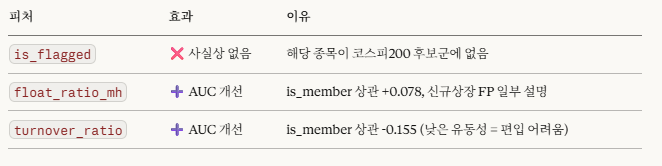

현재까지 최종 피처 정리
지금까지 실험한 모든 피처를 고려했을 때 Hit/FP 기준 최고는 여전히 V11이에요.
V11 (5개): mktcap_rank, was_member, avg_tv_turnover_26w,
           price_return_6m, is_new_listing
→ AUC 0.965, Hit 192.4, FP 6.0, Miss 0.22
더 추가해봐야 의미있는 피처가 남아있지 않아요. 

# 유동비율로 왜 성능 개선이 안 됐는가
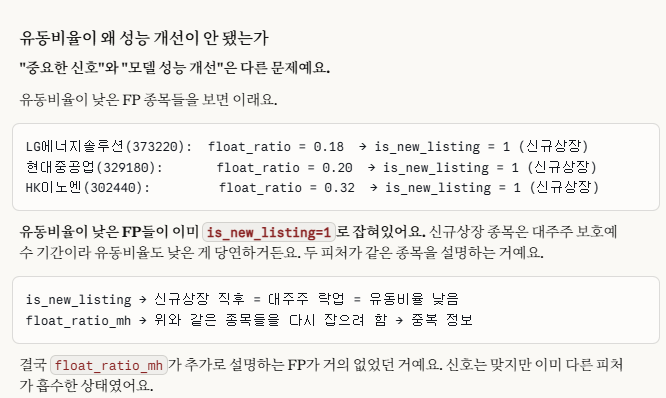

# df_full 기반 학습 구조 개선

In [85]:
# ── 1. df_full_filtered 확인
print("=== df_full_filtered 현황 ===")
print(f"shape: {df_full_filtered.shape}")
print(f"is_member 분포:")
print(df_full_filtered['is_member'].value_counts())
print(f"is_member=1 비율: {df_full_filtered['is_member'].mean()*100:.1f}%")
print()

# ── 2. df_full에 신규 피처 추가
# (feat_snap, listing_snap 이미 만들어져 있음)
df_full = df_full_filtered.copy()

# 기존에 추가된 피처 있으면 제거 후 재병합
new_feat_cols = ['avg_tv_turnover_26w','price_return_6m','is_new_listing',
                 'float_ratio_mh','rank_trend_6m','rank_momentum_1w',
                 'rank_momentum_4w','avg_vol_turnover_26w']
for col in new_feat_cols:
    if col in df_full.columns:
        df_full = df_full.drop(columns=[col])

# feat_snap 병합 (거래대금 회전율, 주가 수익률)
df_full = df_full.merge(feat_snap, on=['ticker','period'], how='left')

# listing_snap 병합 (상장 경과월수)
df_full = df_full.merge(listing_snap, on=['ticker','period'], how='left')
df_full['months_listed'] = df_full['months_listed'].fillna(999)
df_full['is_new_listing'] = (df_full['months_listed'] < 6).astype(int)

# float_ratio_mh 병합
df_full = df_full.merge(
    mh_df[['ticker','period','float_ratio_mh']],
    on=['ticker','period'], how='left'
)

# null 처리
df_full['avg_tv_turnover_26w'] = df_full['avg_tv_turnover_26w'].fillna(0)
df_full['price_return_6m']     = df_full['price_return_6m'].fillna(0)
df_full['float_ratio_mh']      = df_full['float_ratio_mh'].fillna(
    df_full['float_ratio_mh'].median()
)

print(f"df_full shape: {df_full.shape}")
print(f"is_member=1 비율: {df_full['is_member'].mean()*100:.1f}%")
print()
print("null 확인:")
FEATURES_V11 = ['mktcap_rank','was_member','avg_tv_turnover_26w',
                'price_return_6m','is_new_listing']
print(df_full[FEATURES_V11 + ['is_member']].isna().sum())

=== df_full_filtered 현황 ===
shape: (3136, 14)
is_member 분포:
is_member
1    2095
0    1041
Name: count, dtype: int64
is_member=1 비율: 66.8%

df_full shape: (3136, 18)
is_member=1 비율: 66.8%

null 확인:
mktcap_rank            0
was_member             0
avg_tv_turnover_26w    0
price_return_6m        0
is_new_listing         0
is_member              0
dtype: int64


# df_full 기반 Walk-Forward CV

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

def walk_forward_cv_full(df_train_pool, df_test_pool,
                          features, target, periods, min_train=2, top_k=200):
    """
    train: df_full (전체 종목)
    test:  df_clean (편입 종목 위주) → Top-200 정밀도 측정
    """
    results = []
    for i, test_period in enumerate(periods[min_train:], start=min_train):
        train_periods = periods[:i]

        # 학습: df_full (전체 종목)
        train = df_train_pool[df_train_pool['period'].isin(train_periods)]
        # 테스트: df_clean과 동일 기준 (해당 반기 전체)
        test  = df_test_pool[df_test_pool['period'] == test_period].copy()

        if len(test) == 0 or test[target].sum() == 0:
            continue

        model = LogisticRegression(max_iter=1000, random_state=42)
        model.fit(train[features], train[target])

        test['prob'] = model.predict_proba(test[features])[:, 1]
        test['pred'] = 0
        test.loc[test.nlargest(top_k, 'prob').index, 'pred'] = 1

        hit  = ((test['pred']==1) & (test[target]==1)).sum()
        fp   = ((test['pred']==1) & (test[target]==0)).sum()
        miss = ((test['pred']==0) & (test[target]==1)).sum()
        auc  = roc_auc_score(test[target], test['prob'])

        results.append({
            'test_period': test_period,
            'AUC_ROC'   : round(auc, 3),
            'Hit': hit, 'FP': fp, 'Miss': miss,
            'Top200_Prec': round(hit/top_k, 3),
            'train_size' : len(train),
            'test_size'  : len(test),
        })
    return pd.DataFrame(results)

# ── 비교: df_clean 학습 vs df_full 학습
FEATURES_V11 = ['mktcap_rank','was_member','avg_tv_turnover_26w',
                'price_return_6m','is_new_listing']

# df_clean 기반 (기존)
results_clean = walk_forward_cv_v3(
    df_clean, FEATURES_V11, TARGET, PERIODS_ORDERED, min_train=2
)

# df_full 기반 — train=df_full, test=df_full (동일 pool에서)
results_full = walk_forward_cv_full(
    df_full, df_full,
    FEATURES_V11, TARGET, PERIODS_ORDERED, min_train=2
)

# df_full 기반 — train=df_full, test=df_clean (더 엄격한 테스트)
results_full_strict = walk_forward_cv_full(
    df_full, df_clean,
    FEATURES_V11, TARGET, PERIODS_ORDERED, min_train=2
)

print("=" * 60)
print("학습 데이터 구조 비교")
print("=" * 60)
summary = pd.DataFrame({
    'df_clean 학습' : results_clean[['AUC_ROC','Hit','FP','Miss']].mean(),
    'df_full 학습'  : results_full[['AUC_ROC','Hit','FP','Miss']].mean(),
    'df_full→clean' : results_full_strict[['AUC_ROC','Hit','FP','Miss']].mean(),
}).round(3)
print(summary.to_string())

print("\n=== df_full 학습 반기별 상세 ===")
compare = results_clean[['test_period','Hit','FP','Miss']].merge(
    results_full[['test_period','Hit','FP','Miss']],
    on='test_period', suffixes=('_clean','_full')
)
compare['Hit_개선'] = compare['Hit_full'] - compare['Hit_clean']
compare['FP_개선']  = compare['FP_clean'] - compare['FP_full']
print(compare.to_string(index=False))

print()
print("=== train_size 비교 (반기별) ===")
compare2 = pd.DataFrame({
    'test_period': results_clean['test_period'],
    'train_clean': results_clean.get('train_size', 'N/A'),
})
print(results_full[['test_period','train_size','test_size']].to_string(index=False))

학습 데이터 구조 비교
         df_clean 학습  df_full 학습  df_full→clean
AUC_ROC        0.965       0.990          0.961
Hit          192.444     189.333        192.222
FP             6.000      10.667          6.222
Miss           0.222       3.333          0.444

=== df_full 학습 반기별 상세 ===
test_period  Hit_clean  FP_clean  Miss_clean  Hit_full  FP_full  Miss_full  Hit_개선  FP_개선
    2021_H1        189         8           0       186       14          3      -3     -6
    2021_H2        188         9           0       186       14          2      -2     -5
    2022_H1        193         7           0       190       10          3      -3     -3
    2022_H2        193         1           0       189       11          4      -4    -10
    2023_H1        193         5           0       192        8          1      -1     -3
    2023_H2        193         7           1       191        9          3      -2     -2
    2024_H1        196         4           1       189       11          8      -7     -7


# 최종모델 확정 - v11
FEATURES_V11 = [
    'mktcap_rank',          # 시총 순위
    'was_member',           # 기존 편입 여부
    'avg_tv_turnover_26w',  # 26주 평균 거래대금 회전율
    'price_return_6m',      # 6개월 주가 수익률
    'is_new_listing',       # 신규상장 여부 (6개월 미만)
]
AUC 0.965, Hit 192.4, FP 6.0, Miss 0.22

# 최종 모델로 2025_H2 예측 업데이트

In [88]:
from sklearn.linear_model import LogisticRegression

FEATURES_FINAL = [
    'mktcap_rank',
    'was_member',
    'avg_tv_turnover_26w',
    'price_return_6m',
    'is_new_listing',
]

# ── 1. 2025_H2 예측 대상에 피처 추가
EVAL_DATE_2025H2 = '2025-11-28'
closest_2025h2 = get_closest_date(EVAL_DATE_2025H2)
print(f"2025_H2 기준일: {closest_2025h2}")

# 거래대금 회전율, 주가 수익률 스냅샷
feat_2025h2 = weekly_clean[weekly_clean['date'] == closest_2025h2][
    ['ticker', 'avg_tv_turnover_26w', 'price_return_6m']
].copy()

# 상장 경과월수
listing_2025h2 = sm_listing.copy()
eval_dt = pd.Timestamp(EVAL_DATE_2025H2)
listing_2025h2['months_listed'] = (
    (eval_dt.year - listing_2025h2['상장일'].dt.year) * 12
    + (eval_dt.month - listing_2025h2['상장일'].dt.month)
)
listing_2025h2['is_new_listing'] = (listing_2025h2['months_listed'] < 6).astype(int)

# pred_final에 병합
for col in ['avg_tv_turnover_26w','price_return_6m','is_new_listing']:
    if col in pred_final.columns:
        pred_final = pred_final.drop(columns=[col])

pred_final = pred_final.merge(feat_2025h2, on='ticker', how='left')
pred_final = pred_final.merge(
    listing_2025h2[['ticker','is_new_listing']], on='ticker', how='left'
)
pred_final['avg_tv_turnover_26w'] = pred_final['avg_tv_turnover_26w'].fillna(0)
pred_final['price_return_6m']     = pred_final['price_return_6m'].fillna(0)
pred_final['is_new_listing']      = pred_final['is_new_listing'].fillna(0).astype(int)

print(f"pred_final shape: {pred_final.shape}")
print(f"null 확인:")
print(pred_final[FEATURES_FINAL].isna().sum())
print()

# ── 2. 최종 모델 학습 (전체 df_clean)
final_model = LogisticRegression(max_iter=1000, random_state=42)
final_model.fit(df_clean[FEATURES_FINAL], df_clean[TARGET])

print("피처 계수:")
for feat, coef in zip(FEATURES_FINAL, final_model.coef_[0]):
    print(f"  {feat:25s}: {coef:+.4f}")
print()

# ── 3. 예측
pred_final['prob'] = final_model.predict_proba(
    pred_final[FEATURES_FINAL]
)[:, 1]
pred_final = pred_final.sort_values('prob', ascending=False).reset_index(drop=True)
pred_final['pred_rank'] = range(1, len(pred_final)+1)

top200   = pred_final.head(200).copy()
new_in   = top200[top200['was_member']==0]
drop_out = pred_final[
    (pred_final['was_member']==1) & (pred_final['pred_rank']>200)
]

print(f"=== 2025_H2 최종 예측 ===")
print(f"기존 편입 유지: {(top200['was_member']==1).sum()}개")
print(f"신규 편입 예측: {len(new_in)}개")
print(f"편출 예측:      {len(drop_out)}개")
print()

show_cols = [c for c in ['ticker','company','mktcap_rank','was_member',
             'avg_tv_turnover_26w','price_return_6m','is_new_listing','prob']
             if c in pred_final.columns]

print("=== 신규 편입 예측 종목 ===")
print(new_in[show_cols].to_string(index=False))
print()
print("=== 편출 예측 종목 ===")
print(drop_out[show_cols].to_string(index=False))

# ── 4. 저장
top200.to_csv("output/prediction_2025_H2_V11_final200.csv",
              index=False, encoding='utf-8-sig')
pred_final.to_csv("output/prediction_2025_H2_V11_all.csv",
                  index=False, encoding='utf-8-sig')
print("\n저장 완료!")

2025_H2 기준일: 2025-11-28 00:00:00
pred_final shape: (280, 17)
null 확인:
mktcap_rank            0
was_member             0
avg_tv_turnover_26w    0
price_return_6m        0
is_new_listing         0
dtype: int64

피처 계수:
  mktcap_rank              : -0.0068
  was_member               : +3.4789
  avg_tv_turnover_26w      : -0.0732
  price_return_6m          : -1.4813
  is_new_listing           : -3.5800

=== 2025_H2 최종 예측 ===
기존 편입 유지: 190개
신규 편입 예측: 10개
편출 예측:      0개

=== 신규 편입 예측 종목 ===
ticker   company  mktcap_rank  was_member  avg_tv_turnover_26w  price_return_6m  is_new_listing     prob
443060 HD현대마린솔루션           67           0             0.003236         0.035039               0 0.892648
462870      시프트업          156           0             0.002282        -0.241107               0 0.871949
 64400    LG씨엔에스           84           0             0.014139         0.155378               0 0.860892
 20560    아시아나항공          180           0             0.000579        -0.183350            